In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks
import os
from datetime import timedelta


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving natationdonnes.csv to natationdonnes (1).csv


In [ ]:
df = pd.read_csv("natationdonnes.csv")

In [ ]:
df.columns = ["time", "ax(g)", "ay(g)", "az(g)"]
print(df)
print(df.columns.tolist())

                           time     ax(g)     ay(g)     az(g)
0       2025-11-09 17:20:00.000  0.000000  0.000000  0.000000
1       2025-11-09 17:20:00.009  0.000000  0.000000  0.000000
2       2025-11-09 17:20:00.019  0.000000  0.000000  0.000000
3       2025-11-09 17:20:00.029  0.000000  0.000000  0.000000
4       2025-11-09 17:20:00.039  0.000000  0.000000  0.000000
...                         ...       ...       ...       ...
179995  2025-11-09 17:49:59.950 -1.335449  0.052002 -0.312500
179996  2025-11-09 17:49:59.960 -1.429932  0.042969 -0.381592
179997  2025-11-09 17:49:59.970 -1.473389  0.055176 -0.401611
179998  2025-11-09 17:49:59.980 -1.456543  0.057373 -0.413574
179999  2025-11-09 17:49:59.990 -1.395020  0.044678 -0.391113

[180000 rows x 4 columns]
['time', 'ax(g)', 'ay(g)', 'az(g)']


In [ ]:
df_filtered = df[~((df["ax(g)"] == 0) & (df["ay(g)"] == 0) & (df["az(g)"] == 0))]
print(df_filtered)

                           time     ax(g)     ay(g)     az(g)
419     2025-11-09 17:20:04.190 -0.041992 -0.248779 -0.525879
420     2025-11-09 17:20:04.200 -0.616699 -0.232178  0.601807
421     2025-11-09 17:20:04.210 -0.609131 -0.216553  0.510254
422     2025-11-09 17:20:04.220 -0.572754 -0.200928  0.444580
423     2025-11-09 17:20:04.230 -0.527100 -0.185303  0.384277
...                         ...       ...       ...       ...
179995  2025-11-09 17:49:59.950 -1.335449  0.052002 -0.312500
179996  2025-11-09 17:49:59.960 -1.429932  0.042969 -0.381592
179997  2025-11-09 17:49:59.970 -1.473389  0.055176 -0.401611
179998  2025-11-09 17:49:59.980 -1.456543  0.057373 -0.413574
179999  2025-11-09 17:49:59.990 -1.395020  0.044678 -0.391113

[179581 rows x 4 columns]


Maximum time in seconds: 1799.99


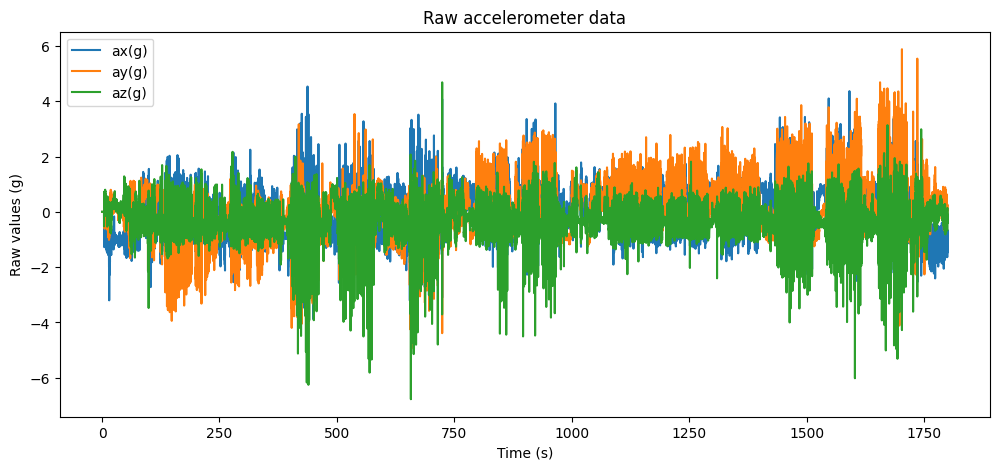

In [ ]:
## Convert the "time" column to datetime format
df["time"] = pd.to_datetime(df["time"])

# Create a new column representing elapsed time in seconds since the start
df["time_sec"] = (df["time"] - df["time"].iloc[0]).dt.total_seconds()

# Check the maximum recorded time
print("Maximum time in seconds:", df["time_sec"].max())  # should be ~1800 seconds (≈30 minutes)

# Plot the raw accelerometer data using time in seconds
df.plot(
    x="time_sec",
    y=["ax(g)", "ay(g)", "az(g)"],
    figsize=(12, 5)
)

plt.xlabel("Time (s)")
plt.ylabel("Raw values (g)")
plt.title("Raw accelerometer data")
plt.legend()
plt.show()



Maximum time in seconds: 1795.8


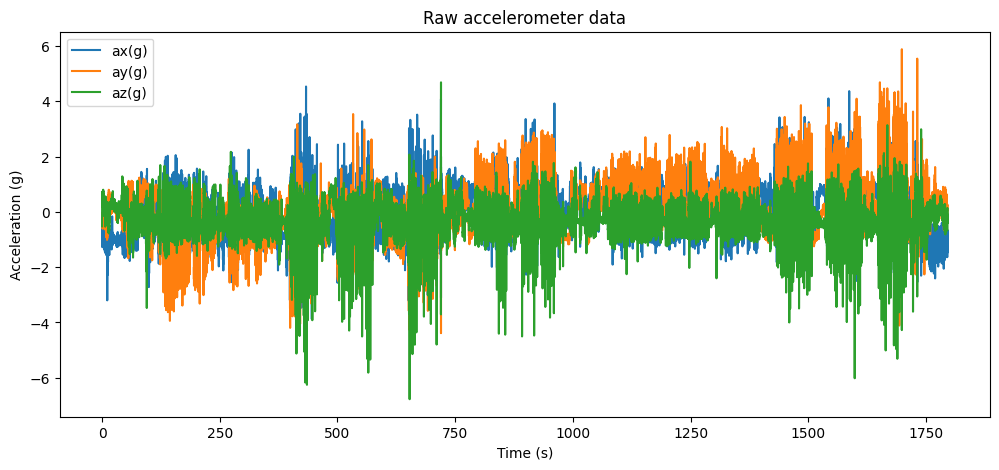

In [ ]:
# 1. Convert the "time" column to datetime format
df_filtered["time"] = pd.to_datetime(df_filtered["time"], errors="coerce")

# 2. Remove rows where the conversion failed (if any)
df_filtered = df_filtered.dropna(subset=["time"])

# 3. Create a new column: elapsed time in seconds since the beginning
df_filtered["time_sec"] = (
    df_filtered["time"] - df_filtered["time"].iloc[0]
).dt.total_seconds()

# Display the maximum time in seconds
print("Maximum time in seconds:", df_filtered["time_sec"].max())  # should be ~1800 sec (≈ 30 minutes)

# 4. Plot the raw accelerometer data using the time axis in seconds
df_filtered.plot(
    x="time_sec",
    y=["ax(g)", "ay(g)", "az(g)"],
    figsize=(12, 5)
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Raw accelerometer data")
plt.show()


Explanations:
A time axis in seconds going from 0 up to approximately 30 minutes, since the data covers the interval from 17:20:00 to 17:50:00.
30 minutes = 1800 seconds, so the axis will range from 0 to ~1800 s.
The sensor was turned off or not initialized at the moment of recording.
Acquisition or reading issue (the software recorded 0 by default).

In [ ]:
# ------------------------------
# Remove the last minute of signal
# ------------------------------

# Extract the time in seconds
t = df_filtered["time_sec"].values

# Compute the total duration
total_duration = t[-1]

# Compute cutoff time
cutoff_time = total_duration - 60

# Mask to keep everything before the last minute
mask = t < cutoff_time

# Apply mask
t_clean = t[mask]
df_clean = df_filtered[mask].copy()

print("Original duration (s):", total_duration)
print("New duration after removing last minute (s):", t_clean[-1])


Original duration (s): 1795.8
New duration after removing last minute (s): 1735.79


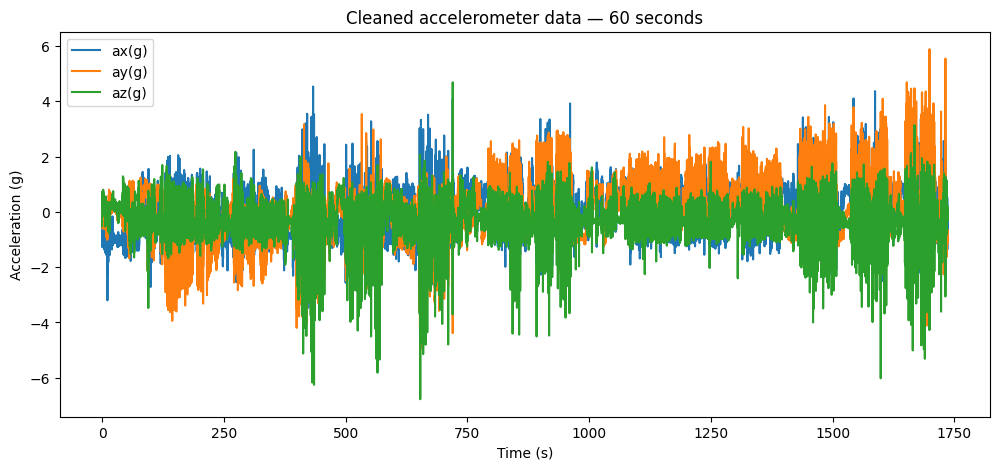

Maximum time after cleaning (s): 1735.79


In [ ]:
# 4. Plot the cleaned accelerometer data
df_clean.plot(
    x="time_sec",
    y=["ax(g)", "ay(g)", "az(g)"],
    figsize=(12, 5)
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.title("Cleaned accelerometer data — 60 seconds")
plt.show()

# Display the maximum time after cleaning
print("Maximum time after cleaning (s):", df_clean["time_sec"].max())



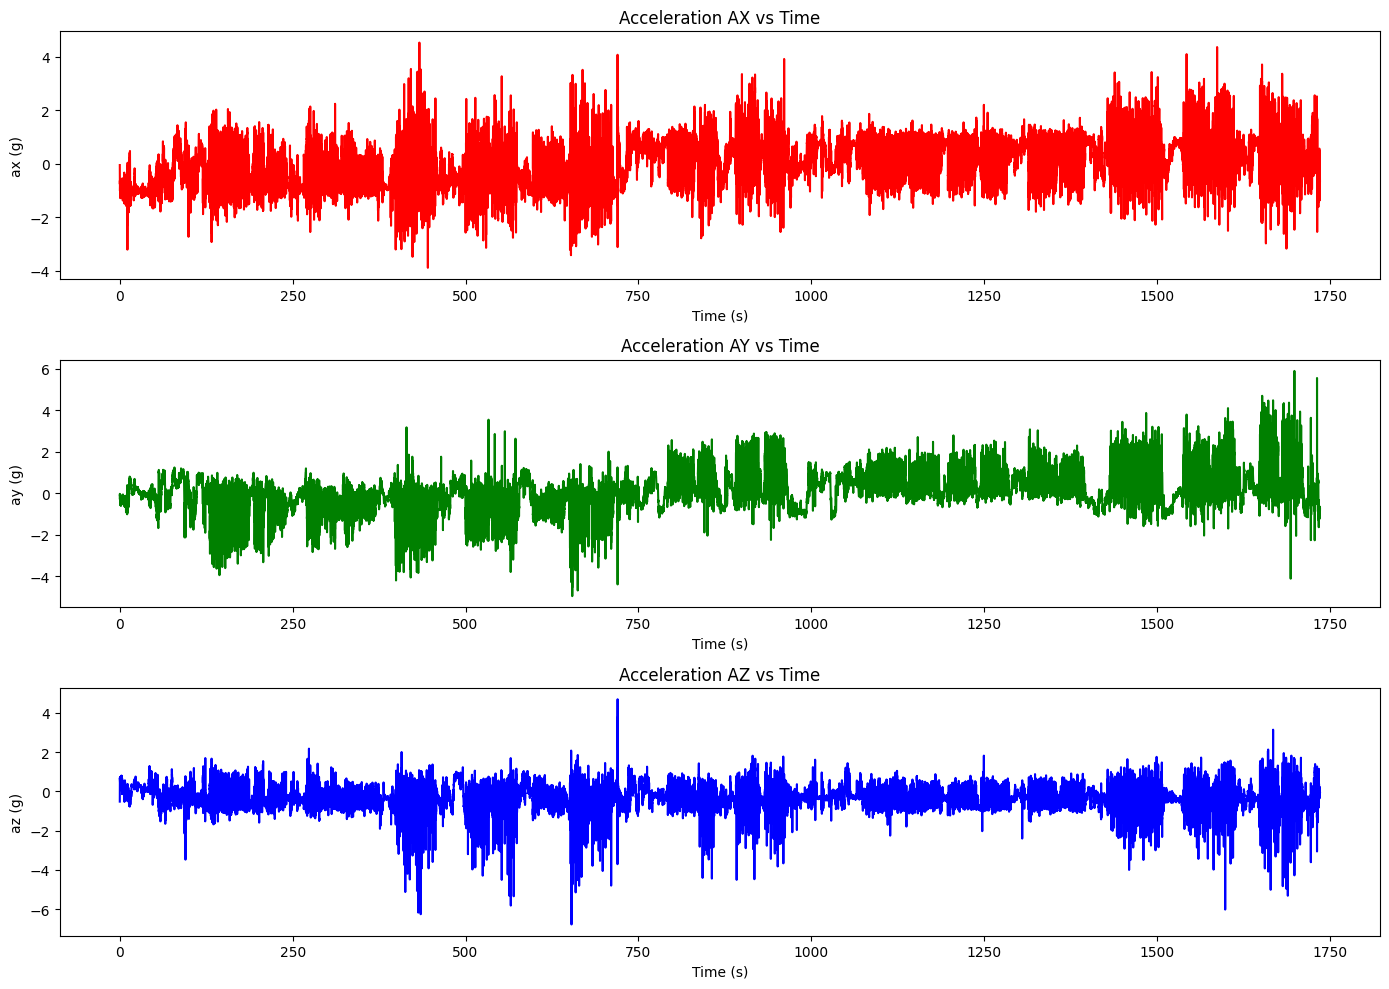

In [ ]:
# ----------------------------------------------------------
# Create a figure with 3 stacked subplots (one per axis)
# ----------------------------------------------------------
plt.figure(figsize=(14, 10))

# ----------------------------------------------------------
# Subplot 1 : AX vs time
# ----------------------------------------------------------
plt.subplot(3, 1, 1)        # 3 rows, 1 column, subplot index 1
plt.plot(df_clean["time_sec"], df_clean["ax(g)"], color="red")
plt.title("Acceleration AX vs Time")
plt.xlabel("Time (s)")
plt.ylabel("ax (g)")

# ----------------------------------------------------------
# Subplot 2 : AY vs time
# ----------------------------------------------------------
plt.subplot(3, 1, 2)        # subplot index 2
plt.plot(df_clean["time_sec"], df_clean["ay(g)"], color="green")
plt.title("Acceleration AY vs Time")
plt.xlabel("Time (s)")
plt.ylabel("ay (g)")

# ----------------------------------------------------------
# Subplot 3 : AZ vs time
# ----------------------------------------------------------
plt.subplot(3, 1, 3)        # subplot index 3
plt.plot(df_clean["time_sec"], df_clean["az(g)"], color="blue")
plt.title("Acceleration AZ vs Time")
plt.xlabel("Time (s)")
plt.ylabel("az (g)")

# ----------------------------------------------------------
# Adjust spacing between subplots to avoid overlap
# ----------------------------------------------------------
plt.tight_layout()

# ----------------------------------------------------------
# Display the figure
# ----------------------------------------------------------
plt.show()


In [ ]:
segments_labeled = pd.DataFrame({
    'i0': [0, 500, 1000],  # indices de début
    'i1': [499, 999, 1499],  # indices de fin
    'condition': ['crawl', 'brasse', 'crawl']
})

**The autocorrelation analysis** is used to detect the periodicity of the swimmer’s strokes within each segment. By computing the normalized autocorrelation of the filtered acceleration norm, the script identifies repeating patterns over time, where peaks in the autocorrelation indicate consistent stroke intervals. This method provides a time-domain measure of stroke regularity and helps estimate the stroke frequency without relying on peak detection. The resulting plots show how well the swimmer maintains a consistent rhythm during each segment, with the lag axis representing time offsets in seconds.

Defined segments:
       i0      i1 condition
0       0   53999     crawl
1   54000  107999    brasse
2  108000  179999     crawl


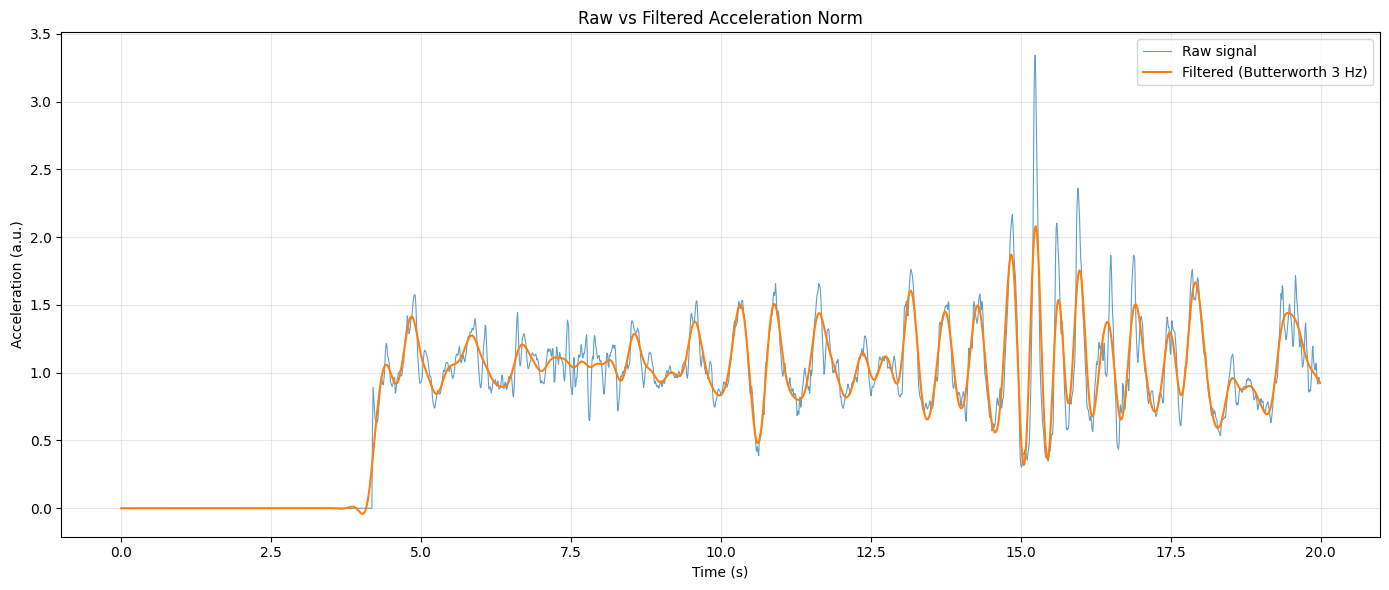


Segment 1 : CRAWL   (samples 0–53999)


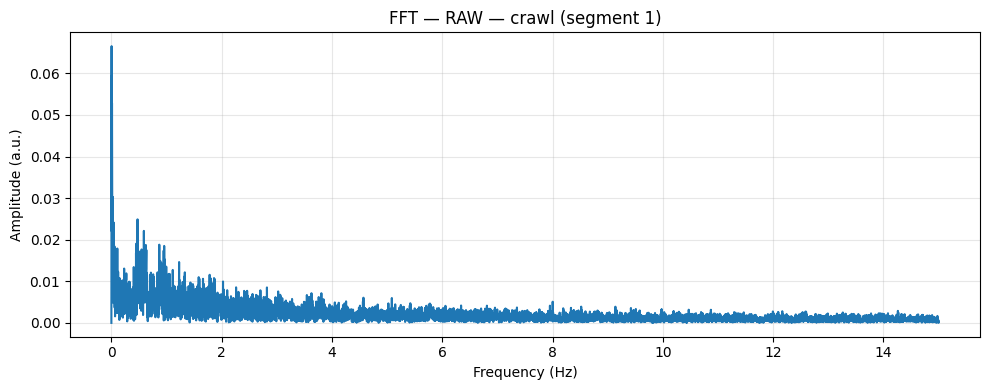

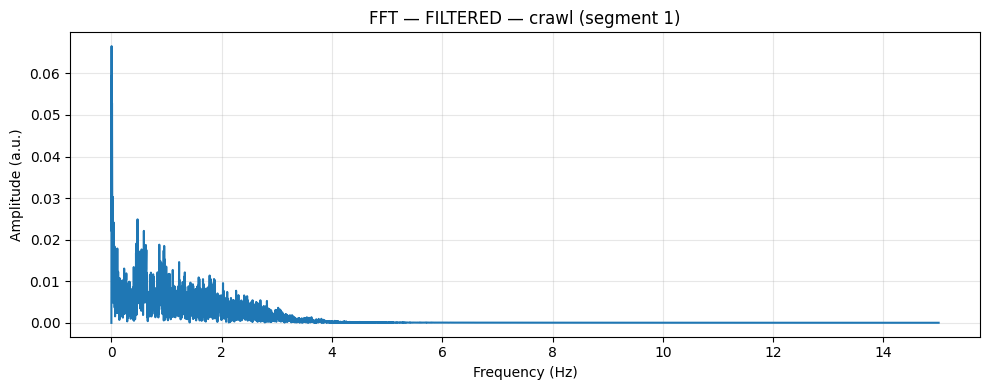


Segment 2 : BRASSE   (samples 54000–107999)


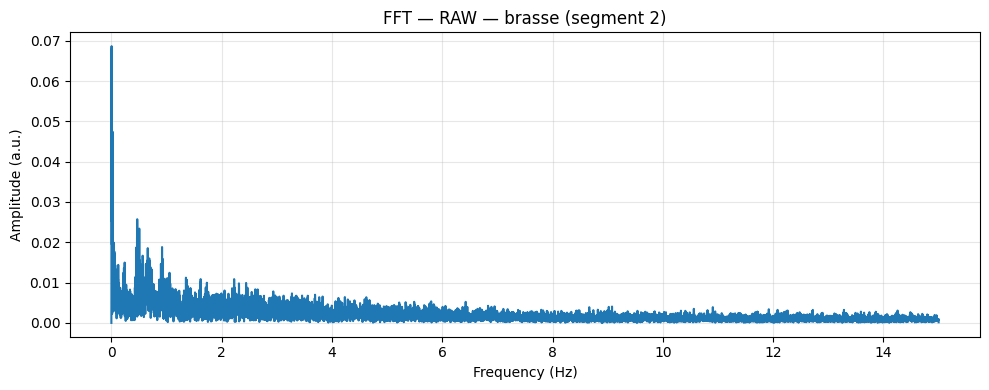

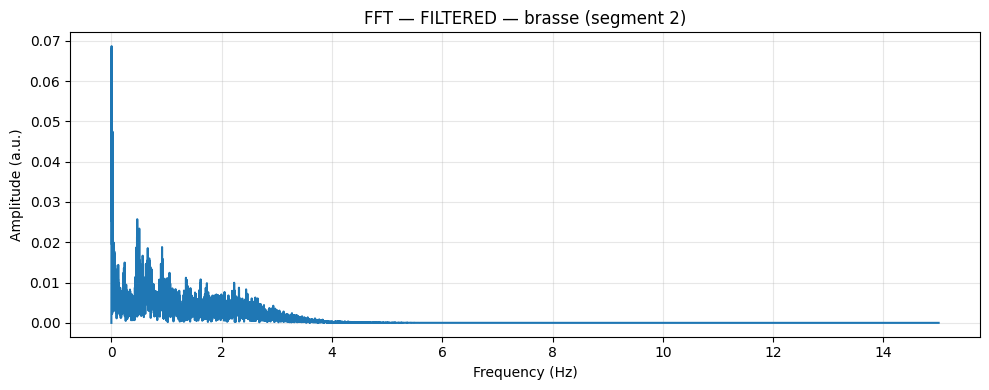


Segment 3 : CRAWL   (samples 108000–179999)


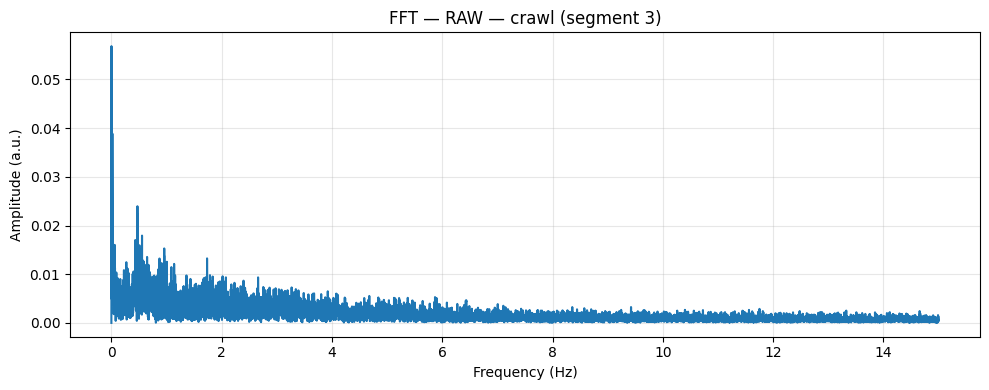

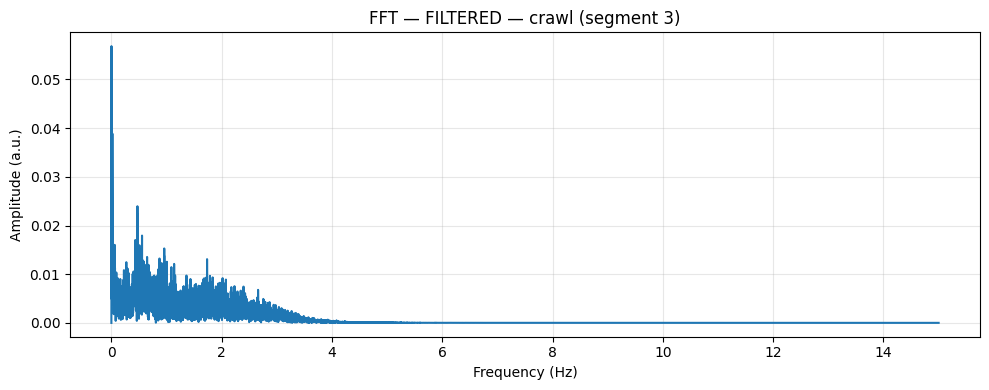


AUTOCORRELATION — Detecting stroke periodicity


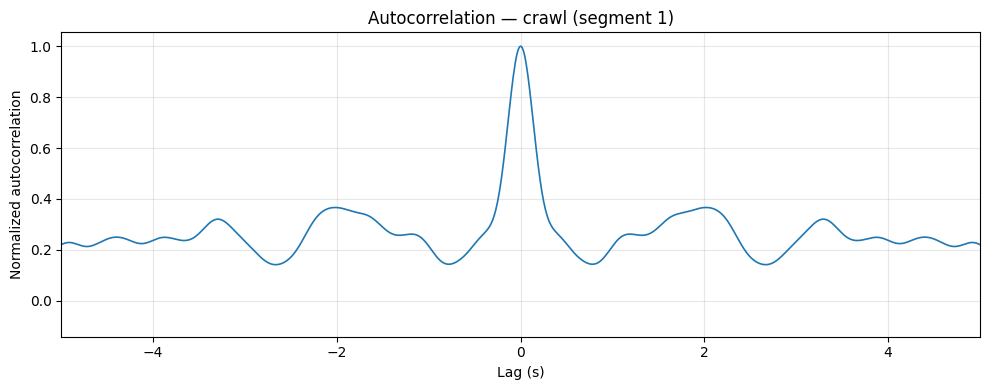

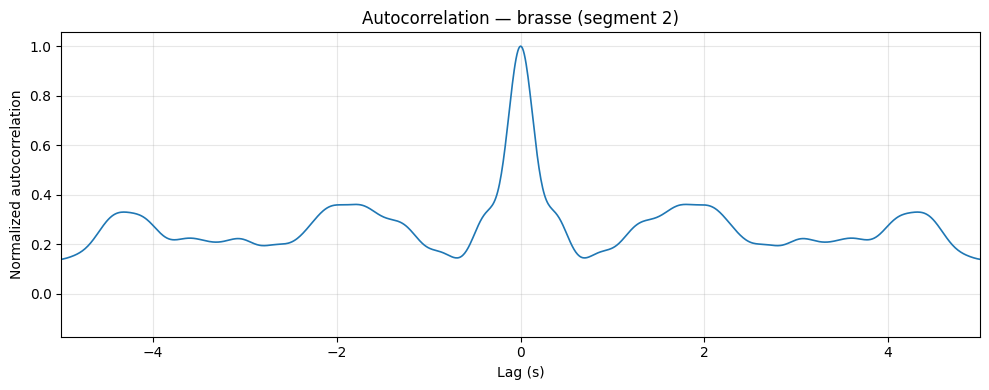

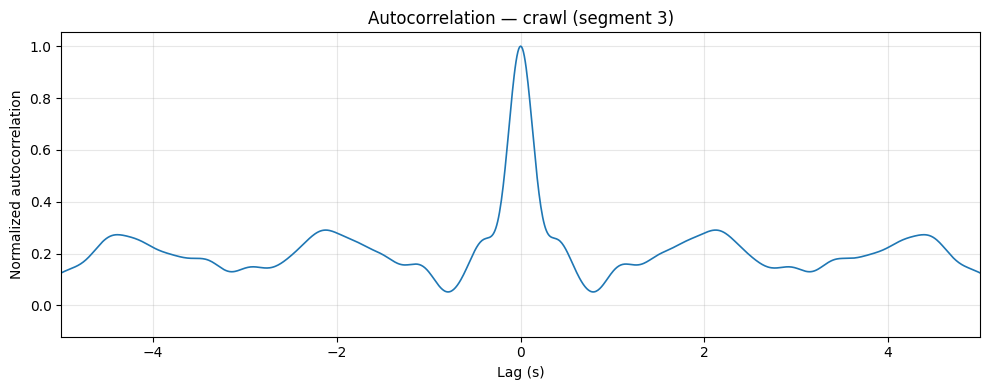

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

# ============================================================================
# 1. LOAD AND PREPARE THE DATA
# ============================================================================
df = pd.read_csv("natationdonnes.csv")

# Standardize column names
df.columns = df.columns.str.strip()  # Remove extra spaces
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax(g)',
    'Accel-Y (g)': 'ay(g)',
    'Accel-Z (g)': 'az(g)'
}, inplace=True)

# Extract time and acceleration components
t_raw = df["time"].values

# Compute raw acceleration norm
a_norm_raw = np.sqrt(
    df["ax(g)"]**2 +
    df["ay(g)"]**2 +
    df["az(g)"]**2
).values

# ============================================================================
# 2. SAMPLING PARAMETERS
# ============================================================================
fs = 100        # Sampling frequency (Hz) — adjust if needed
duration = 60   # Duration of the session (seconds) — adjust
n_samples = fs * duration

# Time vector rebuilt from the sampling frequency
t = np.arange(len(a_norm_raw)) / fs

# ============================================================================
# 3. APPLY A 4th ORDER BUTTERWORTH LOW-PASS FILTER
# ============================================================================
fc = 3      # Cutoff frequency (Hz)
order = 4   # Filter order

# Create Butterworth filter
sos = butter(order, fc, btype='low', fs=fs, output='sos')

# Apply zero-phase filtering
a_norm_filt = sosfiltfilt(sos, a_norm_raw)

# ============================================================================
# 4. DEFINE SEGMENTS (crawl / breaststroke)
# ============================================================================
segments_labeled = pd.DataFrame({
    'i0': [0, int(0.3*len(a_norm_raw)), int(0.6*len(a_norm_raw))],
    'i1': [int(0.3*len(a_norm_raw))-1, int(0.6*len(a_norm_raw))-1, len(a_norm_raw)-1],
    'condition': ['crawl', 'brasse', 'crawl']
})

print("Defined segments:")
print(segments_labeled)

# ============================================================================
# 5. FFT FUNCTION
# ============================================================================
def plot_fft_segment(t, x, fs, i0, i1, fmax=10.0, title="FFT (segment)"):
    """Plot FFT of a segment of the signal."""
    seg = x[i0:i1+1]
    seg -= np.mean(seg)
    n = len(seg)

    freqs = np.fft.rfftfreq(n, d=1/fs)
    X = np.abs(np.fft.rfft(seg)) / n

    mask = freqs <= fmax

    plt.figure(figsize=(10, 4))
    plt.plot(freqs[mask], X[mask], linewidth=1.5)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude (a.u.)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. PLOT RAW vs FILTERED SIGNAL (first 2000 samples)
# ============================================================================
plt.figure(figsize=(14, 6))
plt.plot(t[:2000], a_norm_raw[:2000], label='Raw signal', alpha=0.7, linewidth=0.8)
plt.plot(t[:2000], a_norm_filt[:2000], label='Filtered (Butterworth 3 Hz)', linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (a.u.)")
plt.title("Raw vs Filtered Acceleration Norm")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. FFT ANALYSIS (before/after filtering)
# ============================================================================
for idx, row in segments_labeled.iterrows():
    i0, i1 = int(row['i0']), int(row['i1'])
    condition = row['condition']

    print(f"\n{'='*60}")
    print(f"Segment {idx+1} : {condition.upper()}   (samples {i0}–{i1})")
    print(f"{'='*60}")

    # FFT before filtering
    plot_fft_segment(t, a_norm_raw, fs, i0, i1, fmax=15,
                     title=f"FFT — RAW — {condition} (segment {idx+1})")

    # FFT after filtering
    plot_fft_segment(t, a_norm_filt, fs, i0, i1, fmax=15,
                     title=f"FFT — FILTERED — {condition} (segment {idx+1})")

# ============================================================================
# 8. AUTOCORRELATION (detects periodicity of the swimming stroke)
# ============================================================================
def plot_autocorr_segment(x, fs, i0, i1, title="Autocorrelation"):
    """Plot normalized autocorrelation of a signal segment."""
    seg = x[i0:i1+1]
    seg -= np.mean(seg)

    autocorr = np.correlate(seg, seg, mode='full')
    autocorr /= autocorr.max()

    # Convert lag index to time in seconds
    lags = np.arange(len(autocorr)) - len(autocorr)//2
    lags_sec = lags / fs

    plt.figure(figsize=(10, 4))
    plt.plot(lags_sec, autocorr, linewidth=1.2)
    plt.xlim([-5, 5])  # zoom on ±5 seconds
    plt.xlabel("Lag (s)")
    plt.ylabel("Normalized autocorrelation")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("AUTOCORRELATION — Detecting stroke periodicity")
print("="*60)

for idx, row in segments_labeled.iterrows():
    i0, i1 = int(row['i0']), int(row['i1'])
    condition = row['condition']

    plot_autocorr_segment(a_norm_filt, fs, i0, i1,
                          title=f"Autocorrelation — {condition} (segment {idx+1})")


In [ ]:
df_local = pd.read_csv('natationdonnes.csv')
print("Columns in locally uploaded 'natationdonnes.csv':", df_local.columns.tolist())

# Also check the columns of the main df DataFrame
print("Columns in current 'df' DataFrame:", df.columns.tolist())


Columns in locally uploaded 'natationdonnes.csv': ['Time', 'Accel-X (g)', ' Accel-Y (g)', ' Accel-Z (g)']
Columns in current 'df' DataFrame: ['time', 'ax(g)', 'ay(g)', 'az(g)']


Data loaded: 180000 samples (1800.0 seconds)
Filter applied: Butterworth order 4, fc = 5 Hz

FFT OF THE FIRST 10 SECONDS

1️⃣  FFT of RAW signal (BEFORE filtering)


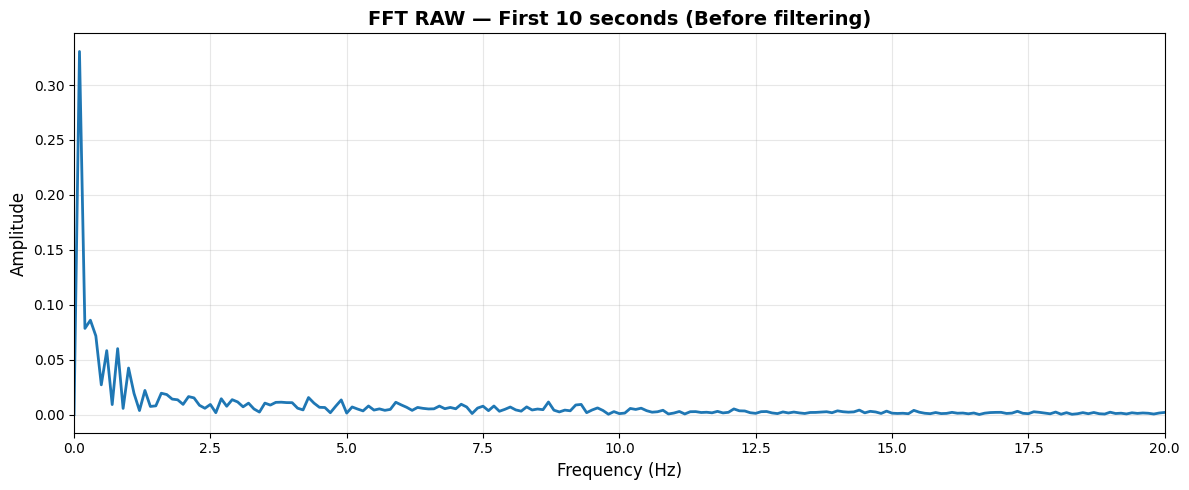


2️⃣  FFT of FILTERED signal (AFTER Butterworth filtering)


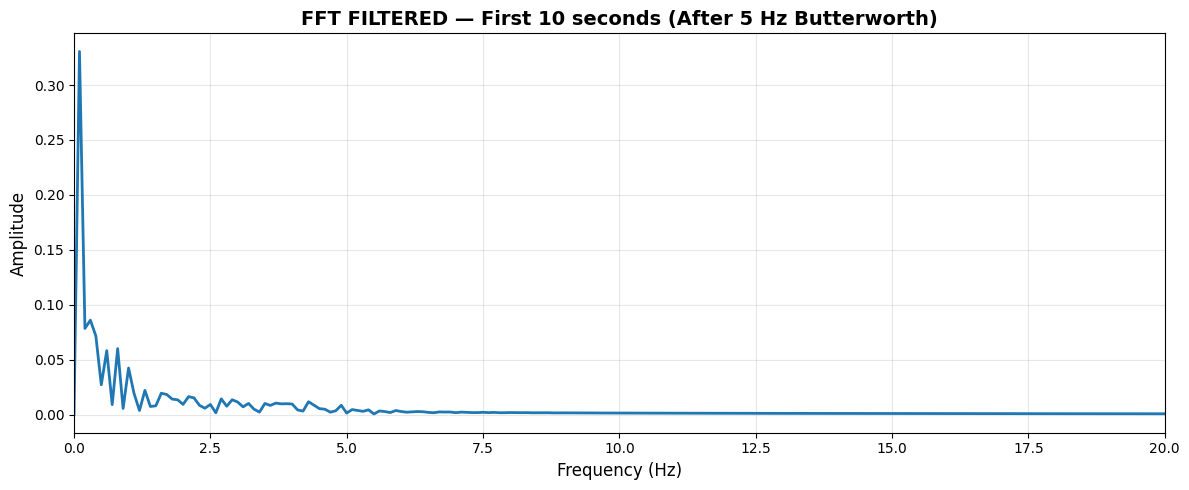


✅ Done! You should now see two frequency-domain plots:
   - The first shows the noise BEFORE filtering
   - The second shows the remaining useful signal AFTER filtering


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

# ============================================================================
# 1. LOAD YOUR DATA
# ============================================================================
df = pd.read_csv("natationdonnes.csv")
df.columns = df.columns.str.strip()

# Standardize column names
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax(g)',
    'Accel-Y (g)': 'ay(g)',
    'Accel-Z (g)': 'az(g)'
}, inplace=True)

t = df["time"].values

# Compute the magnitude of acceleration
a_norm_raw = np.sqrt(
    df["ax(g)"]**2 +
    df["ay(g)"]**2 +
    df["az(g)"]**2
).values

fs = 100  # Sampling frequency (Hz)
n_samples = len(a_norm_raw)
t = np.arange(n_samples) / fs

print(f"Data loaded: {n_samples} samples ({n_samples/fs:.1f} seconds)")

# ============================================================================
# 2. APPLY BUTTERWORTH LOW-PASS FILTER (5 Hz)
# ============================================================================
fc = 5      # Cutoff frequency (Hz)
order = 4   # Filter order

sos = butter(order, fc, btype='low', fs=fs, output='sos')
a_norm_filt = sosfiltfilt(sos, a_norm_raw)

print(f"Filter applied: Butterworth order {order}, fc = {fc} Hz")

# ============================================================================
# 3. SIMPLE FFT FUNCTION
# ============================================================================
def plot_fft_simple(signal, fs, title, fmax=20):
    """Compute and display the FFT of a signal."""
    sig = signal - np.mean(signal)  # Remove DC offset

    n = len(sig)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    fft_vals = np.abs(np.fft.rfft(sig)) / n

    mask = freqs <= fmax

    plt.figure(figsize=(12, 5))
    plt.plot(freqs[mask], fft_vals[mask], linewidth=2)
    plt.xlabel("Frequency (Hz)", fontsize=12)
    plt.ylabel("Amplitude", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, fmax])
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. TAKE THE FIRST 10 SECONDS AND PLOT THE FFT
# ============================================================================
idx_end = min(1000, n_samples)  # 1000 samples = 10 seconds at 100 Hz

print("\n" + "="*60)
print("FFT OF THE FIRST 10 SECONDS")
print("="*60)

# FFT BEFORE filtering
print("\n1️⃣  FFT of RAW signal (BEFORE filtering)")
plot_fft_simple(a_norm_raw[:idx_end], fs,
                title="FFT RAW — First 10 seconds (Before filtering)",
                fmax=20)

# FFT AFTER filtering
print("\n2️⃣  FFT of FILTERED signal (AFTER Butterworth filtering)")
plot_fft_simple(a_norm_filt[:idx_end], fs,
                title="FFT FILTERED — First 10 seconds (After 5 Hz Butterworth)",
                fmax=20)

print("\n✅ Done! You should now see two frequency-domain plots:")
print("   - The first shows the noise BEFORE filtering")
print("   - The second shows the remaining useful signal AFTER filtering")


**FFT Analysis with Tukey Window**

A Fast Fourier Transform (FFT) is applied to each axis within each segment.
A Tukey window reduces spectral leakage and improves frequency resolution.
The resulting spectra reveal dominant frequencies in the swimming motion, corresponding to stroke rate or periodic movements.

Data loaded: 180000 samples
Butterworth filter applied: cutoff = 3 Hz

Applying Tukey window to the full signal...
Tukey window applied (alpha = 0.1)


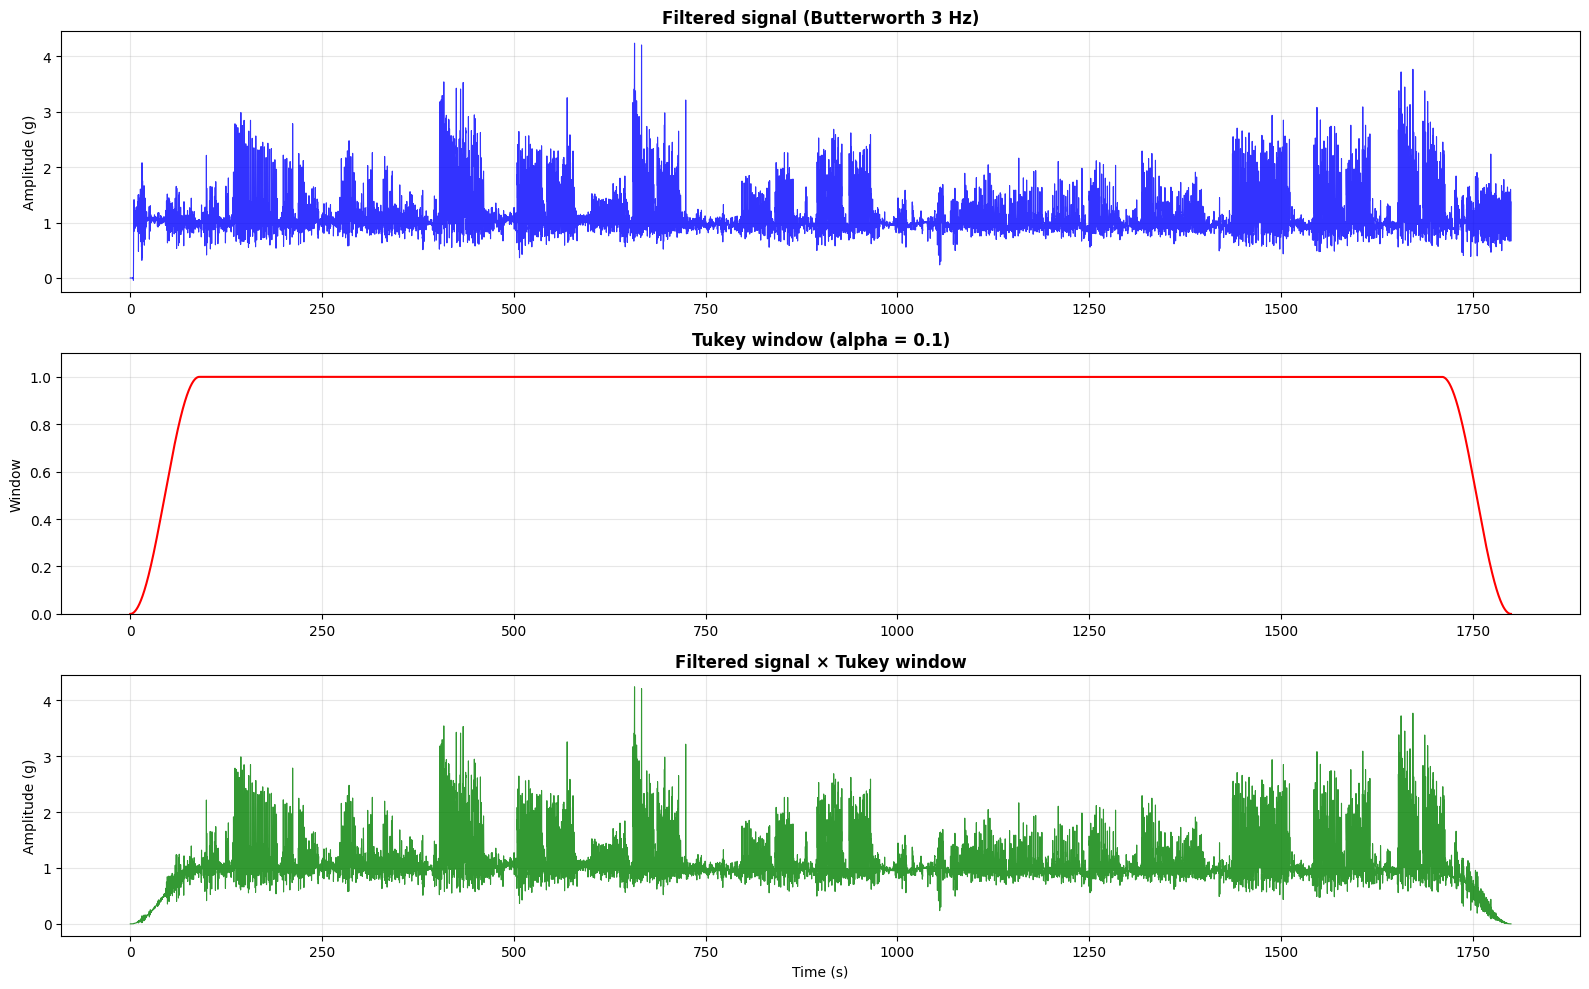

Windowing comparison plot displayed.

Computing FFT of the full signal...
FFT computed: 90001 frequency points


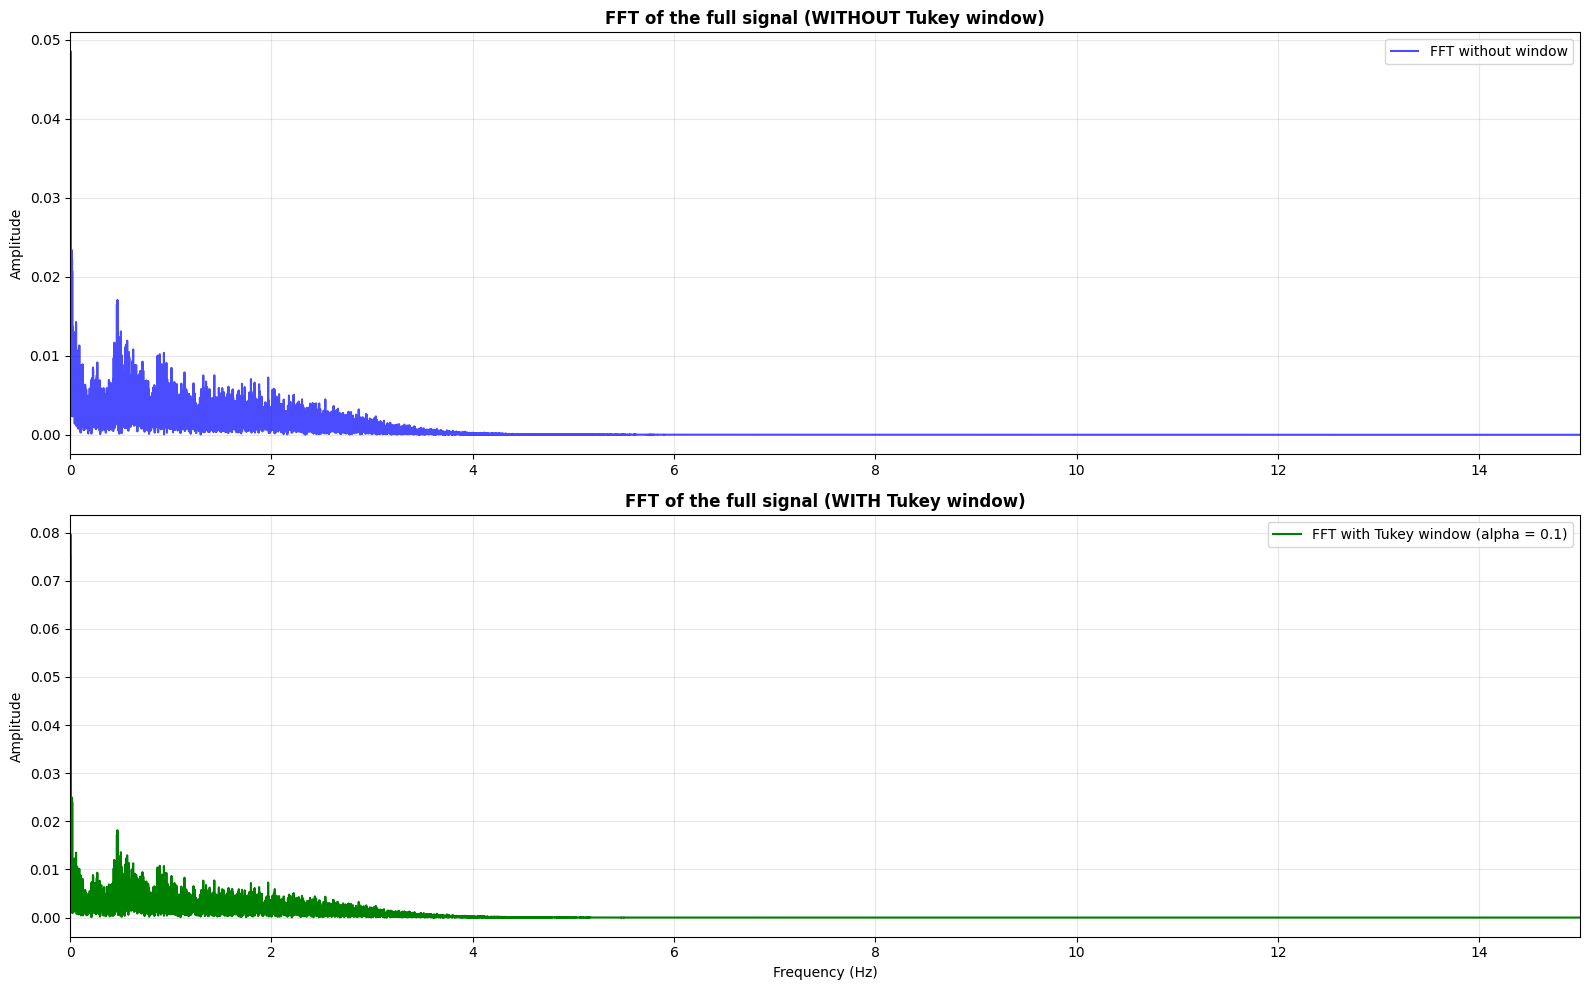

FFT plots displayed.

Computing Power Spectral Density...


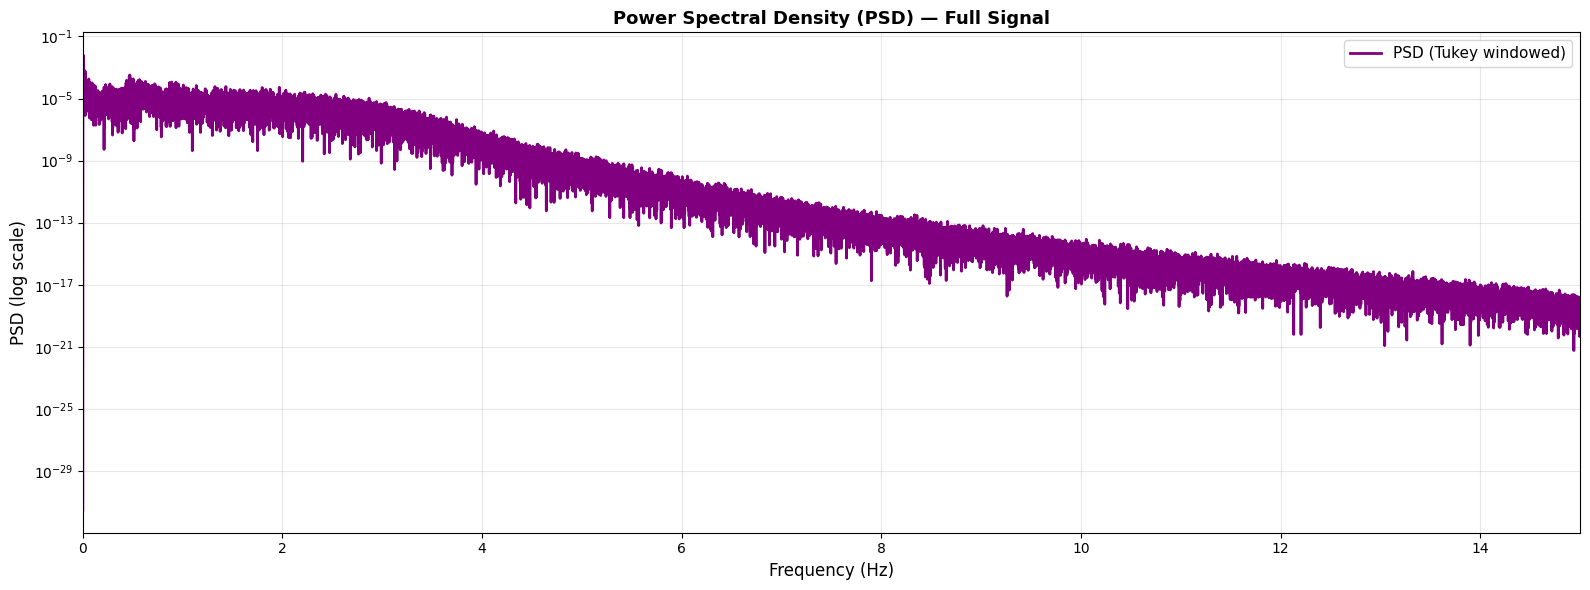


FREQUENCY STATISTICS

Top 5 frequency peaks:

Rank | Frequency (Hz) | Amplitude
-----|----------------|-----------
  1  |       0.00      |  0.079654
  2  |       0.00      |  0.075252
  3  |       0.00      |  0.065853
  4  |       0.00      |  0.064370
  5  |       0.00      |  0.056660

Full-signal analysis with Tukey window (alpha = 0.1) complete!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt
from scipy.signal.windows import tukey

# ==============================================================
# 1. LOAD THE DATA
# ==============================================================
df = pd.read_csv("natationdonnes.csv")

df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax(g)',
    'Accel-Y (g)': 'ay(g)',
    'Accel-Z (g)': 'az(g)'
}, inplace=True)

fs = 100  # sampling frequency in Hz
t = np.arange(len(df)) / fs

# Compute the magnitude of acceleration
a_norm_raw = np.sqrt(
    df["ax(g)"]**2 +
    df["ay(g)"]**2 +
    df["az(g)"]**2
).values

print("Data loaded:", len(a_norm_raw), "samples")

# ==============================================================
# 2. APPLY BUTTERWORTH FILTER
# ==============================================================
fc = 3  # low-pass cutoff frequency
sos = butter(4, fc, btype='low', fs=fs, output='sos')
a_norm_filt = sosfiltfilt(sos, a_norm_raw)

print("Butterworth filter applied: cutoff =", fc, "Hz")

# ==============================================================
# 3. APPLY TUKEY WINDOW TO THE FULL SIGNAL
# ==============================================================
print("\nApplying Tukey window to the full signal...")

alpha = 0.1  # Tukey taper ratio
window_tukey = tukey(len(a_norm_filt), alpha=alpha)
a_norm_windowed = a_norm_filt * window_tukey

print(f"Tukey window applied (alpha = {alpha})")

# ==============================================================
# 4. PLOT SIGNAL BEFORE / AFTER WINDOWING
# ==============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(t, a_norm_filt, linewidth=0.8, color='blue', alpha=0.8)
axes[0].set_title('Filtered signal (Butterworth 3 Hz)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (g)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, window_tukey, linewidth=1.5, color='red')
axes[1].set_title('Tukey window (alpha = 0.1)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Window')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.1])

axes[2].plot(t, a_norm_windowed, linewidth=0.8, color='green', alpha=0.8)
axes[2].set_title('Filtered signal × Tukey window', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Amplitude (g)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Windowing comparison plot displayed.")

# ==============================================================
# 5. COMPUTE FFT OF THE FULL SIGNAL
# ==============================================================
print("\nComputing FFT of the full signal...")

signal_windowed_centered = a_norm_windowed - np.mean(a_norm_windowed)

n = len(signal_windowed_centered)
freqs = np.fft.rfftfreq(n, d=1/fs)

# Tukey window coherent gain
coherent_gain = np.sum(window_tukey) / len(window_tukey)

fft_vals = np.abs(np.fft.rfft(signal_windowed_centered)) / (n * coherent_gain)

print("FFT computed:", len(fft_vals), "frequency points")

# ==============================================================
# 6. PLOT FULL FFT (WITH AND WITHOUT WINDOW)
# ==============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

signal_raw_centered = a_norm_filt - np.mean(a_norm_filt)
fft_vals_no_window = np.abs(np.fft.rfft(signal_raw_centered)) / n

axes[0].plot(freqs, fft_vals_no_window, linewidth=1.5, color='blue',
             label='FFT without window', alpha=0.7)
axes[0].set_xlim([0, 15])
axes[0].set_title('FFT of the full signal (WITHOUT Tukey window)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs, fft_vals, linewidth=1.5, color='green',
             label='FFT with Tukey window (alpha = 0.1)')
axes[1].set_xlim([0, 15])
axes[1].set_title('FFT of the full signal (WITH Tukey window)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("FFT plots displayed.")

# ==============================================================
# 7. POWER SPECTRAL DENSITY (PSD)
# ==============================================================
print("\nComputing Power Spectral Density...")

psd = fft_vals ** 2

fig, ax = plt.subplots(figsize=(16, 6))

ax.semilogy(freqs, psd, linewidth=2, color='purple',
            label='PSD (Tukey windowed)')
ax.set_xlim([0, 15])
ax.set_title('Power Spectral Density (PSD) — Full Signal', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('PSD (log scale)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# ==============================================================
# 8. STATISTICS ON THE FREQUENCIES
# ==============================================================
print("\n" + "="*60)
print("FREQUENCY STATISTICS")
print("="*60)

top_indices = np.argsort(fft_vals)[-5:][::-1]

print("\nTop 5 frequency peaks:\n")
print("Rank | Frequency (Hz) | Amplitude")
print("-----|----------------|-----------")

for i, idx in enumerate(top_indices):
    print(f"  {i+1}  |     {freqs[idx]:>6.2f}      | {fft_vals[idx]:>9.6f}")

print("\n" + "="*60)
print("Full-signal analysis with Tukey window (alpha = 0.1) complete!")
print("="*60)


# Butterworth filter

All signal components below 3 Hz are preserved (they pass through).
All components above 3 Hz are progressively attenuated (reduction of high-frequency noise).
Swimming movements are generally between 0.5 and 2 Hz → therefore well preserved.
Sensor noise is often above 3 Hz → attenuated by the filter.
A 4th-order Butterworth filter is applied to each axis to remove high-frequency noise.
The filtered acceleration data is used to compute the norm (||a||) for smoother signal representation.
This step highlights the swimming motion while suppressing small vibrations or sensor noise.

Donnees chargees : 180000 echantillons
Colonnes disponibles : ['time', 'ax', 'ay', 'az']

Frequence d'echantillonnage : fs = 100 Hz
Filtre Butterworth defini : cutoff = 3 Hz, ordre = 4
Filtre applique sur les 3 axes
Fenetre Tukey (alpha=0.1) appliquee sur les 3 axes


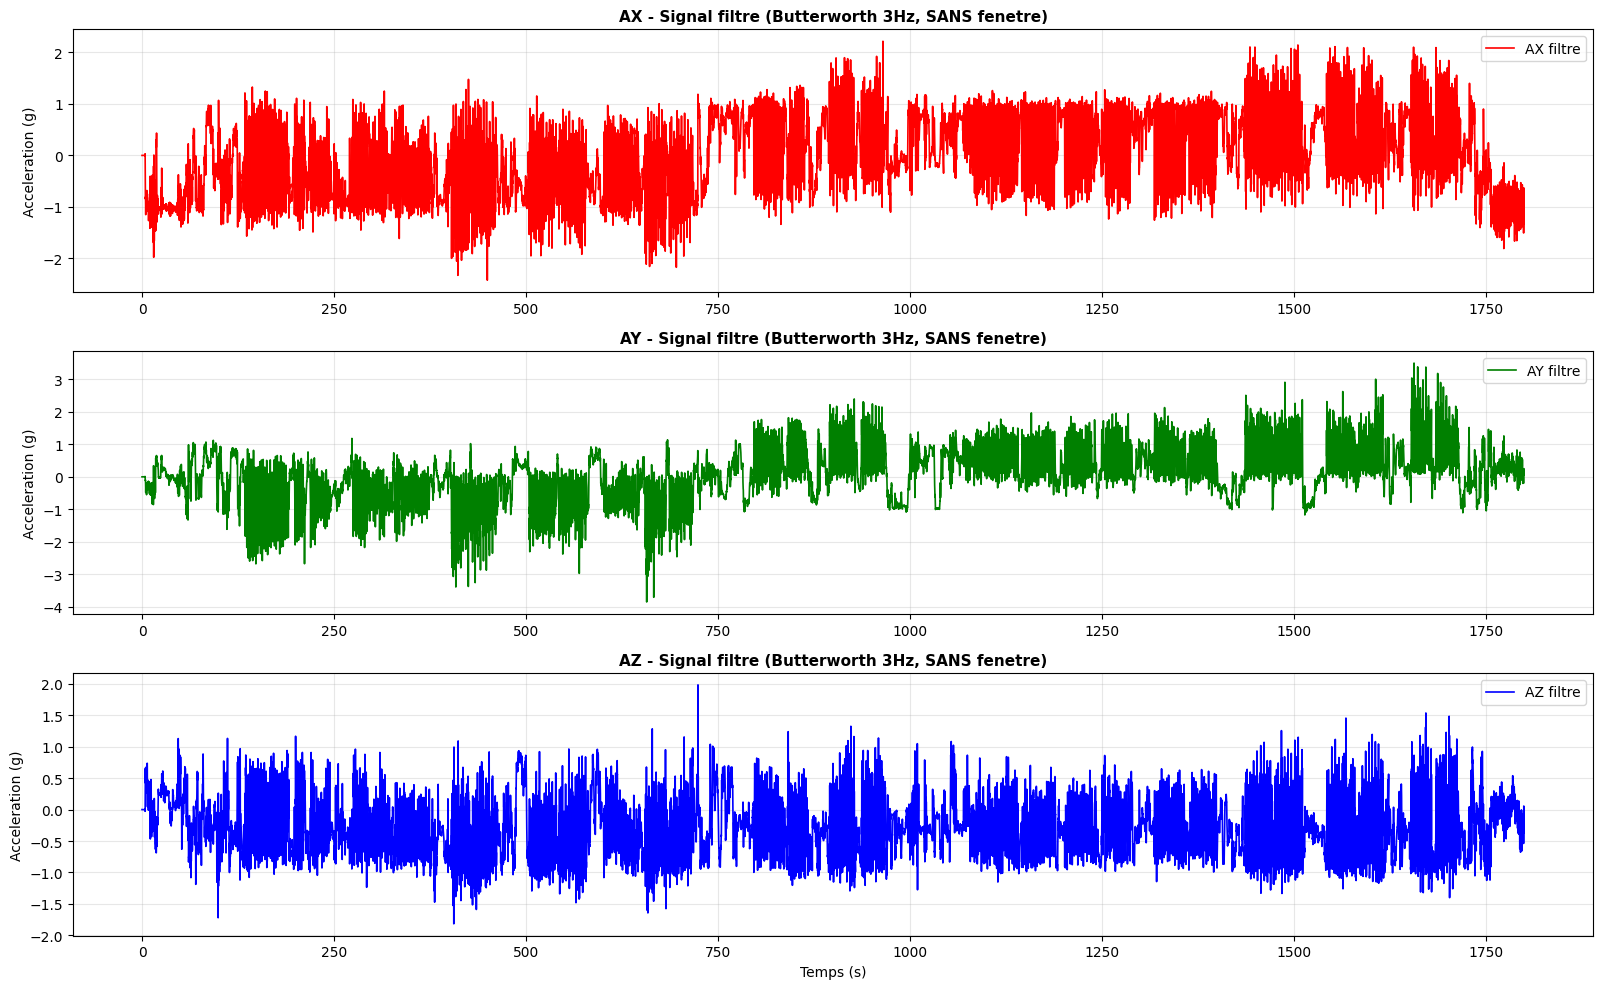


Axes filtres (SANS fenetre) affiches


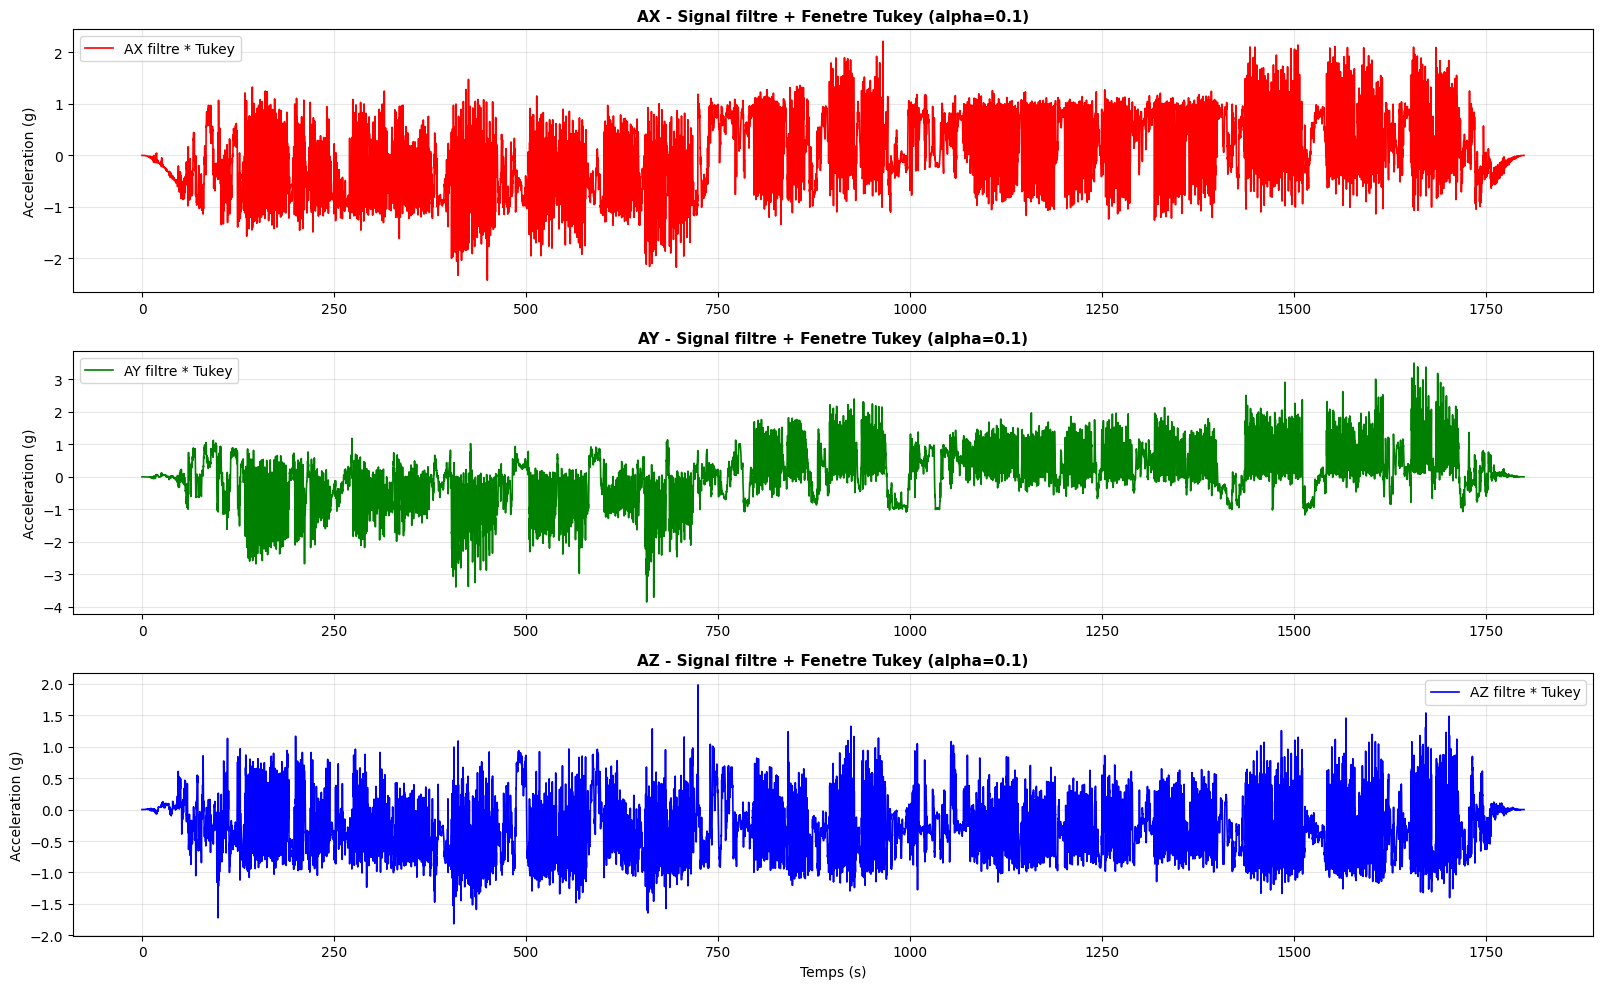

Axes filtres + fenetre Tukey affiches


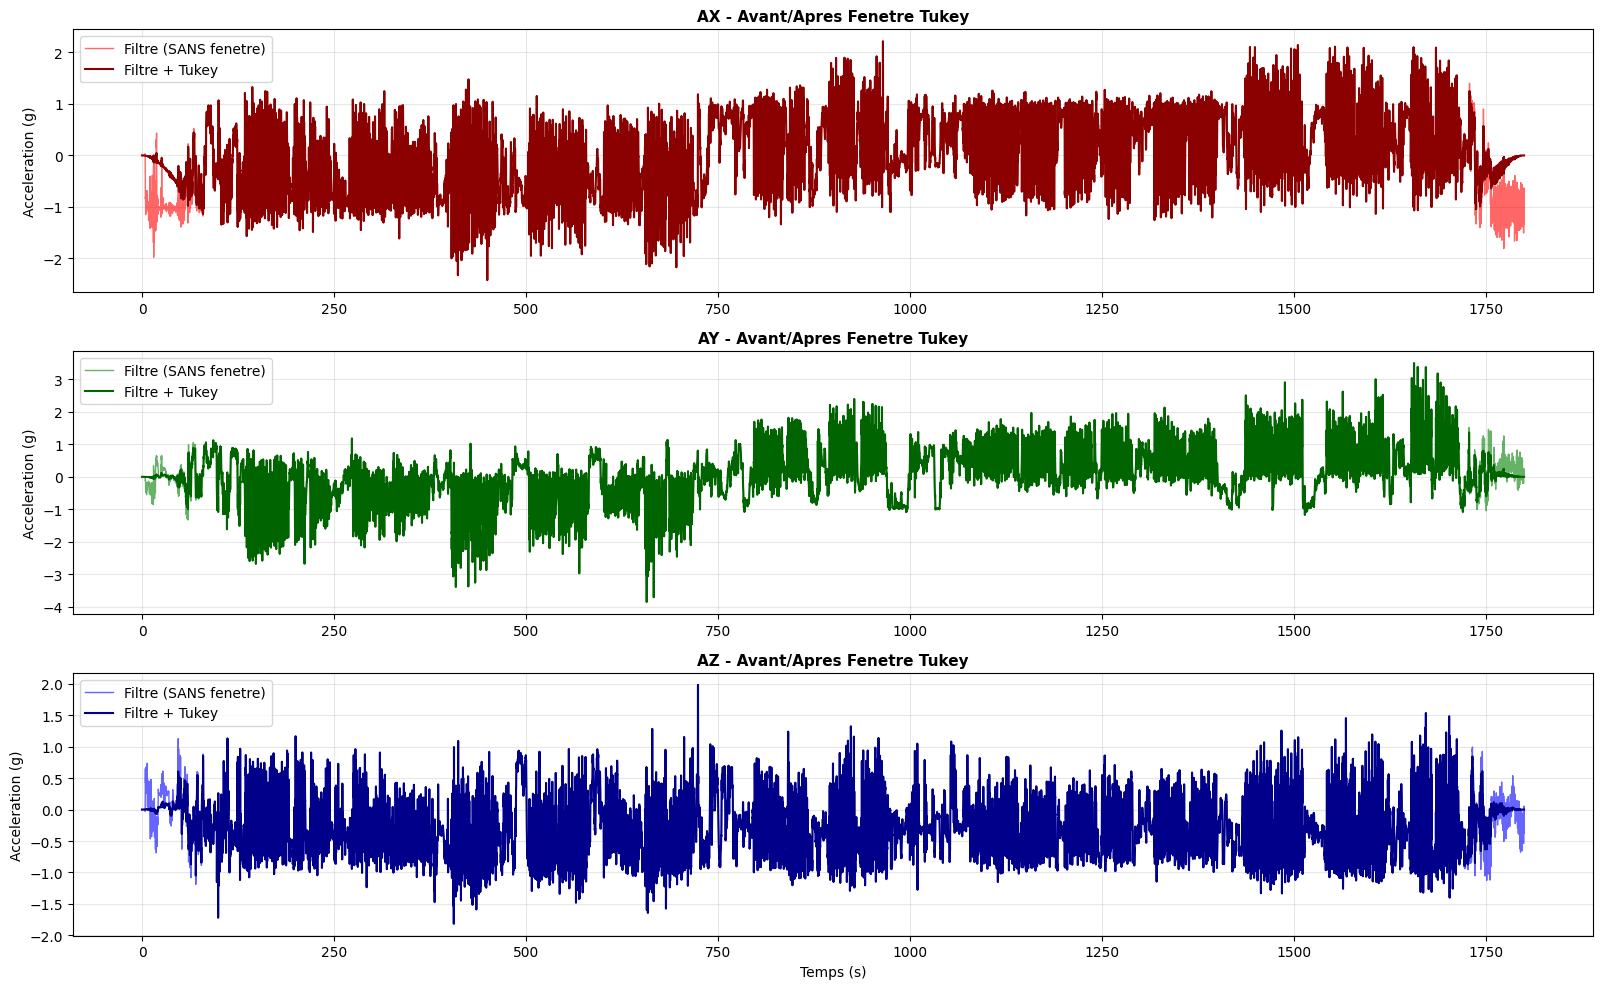

Comparison avant/apres fenetre affichee


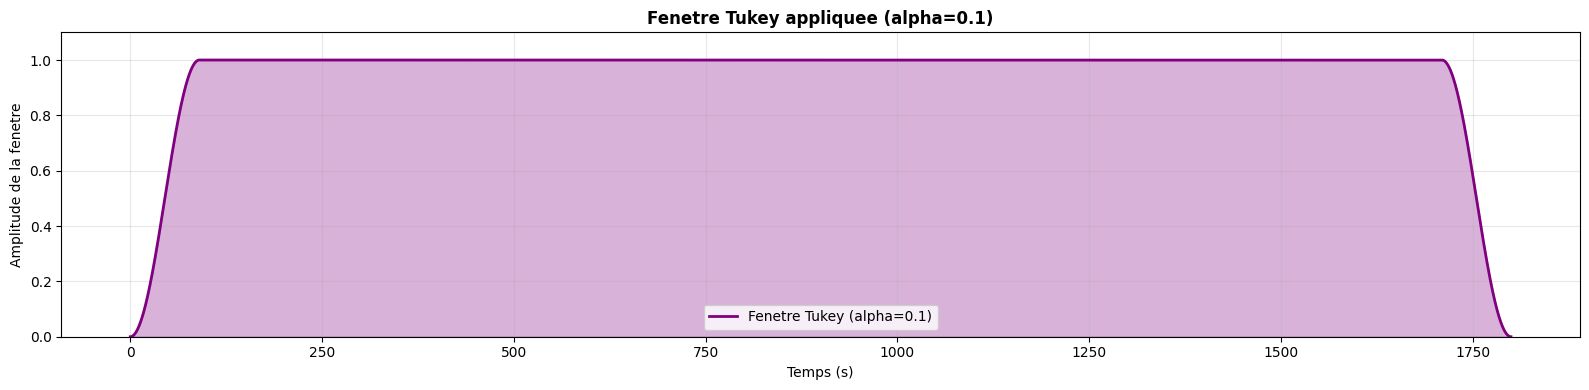

Fenetre Tukey visualisee

RESUME
Axes filtres avec Butterworth 3Hz
Fenetre Tukey (alpha=0.1) appliquee
Donnees pretes pour FFT ou analyse


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt
from scipy.signal.windows import tukey
import matplotlib.pyplot as plt

# ==============================================================
# 0. CHARGER LES DONNEES
# ==============================================================
df = pd.read_csv("natationdonnes.csv")

df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax',
    'Accel-Y (g)': 'ay',
    'Accel-Z (g)': 'az'
}, inplace=True)

print("Donnees chargees :", len(df), "echantillons")
print("Colonnes disponibles :", df.columns.tolist())

# ==============================================================
# 1. ESTIMATION DE LA FREQUENCE D'ECHANTILLONNAGE fs
# ==============================================================
fs = 100  # On sait que c'est 100 Hz pour ta natation
print("\nFrequence d'echantillonnage : fs = 100 Hz")

# Creer colonne time_sec
df["time_sec"] = np.arange(len(df)) / fs

# ==============================================================
# 2. DEFINITION DU FILTRE PASSE-BAS BUTTERWORTH
# ==============================================================
def lowpass_filter(data, fs, cutoff=3, order=4):
    """
    Applique un filtre passe-bas Butterworth

    Args:
        data : signal a filtrer (axe)
        fs : frequence d'echantillonnage (Hz)
        cutoff : frequence de coupure (Hz)
        order : ordre du filtre
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

print("Filtre Butterworth defini : cutoff = 3 Hz, ordre = 4")

# ==============================================================
# 3. APPLICATION DU FILTRE SUR LES AXES
# ==============================================================
df["ax_filt"] = lowpass_filter(df["ax"].values, fs)
df["ay_filt"] = lowpass_filter(df["ay"].values, fs)
df["az_filt"] = lowpass_filter(df["az"].values, fs)

print("Filtre applique sur les 3 axes")

# ==============================================================
# 4. APPLIQUER FENETRE TUKEY SUR LES AXES FILTRES
# ==============================================================
alpha = 0.1
window_tukey = tukey(len(df), alpha=alpha)

df["ax_windowed"] = df["ax_filt"] * window_tukey
df["ay_windowed"] = df["ay_filt"] * window_tukey
df["az_windowed"] = df["az_filt"] * window_tukey

print("Fenetre Tukey (alpha=" + str(alpha) + ") appliquee sur les 3 axes")

# ==============================================================
# 5. VISUALISATION : AXES FILTRES (AVANT FENETRE)
# ==============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(df["time_sec"], df["ax_filt"], color="red", linewidth=1.2, label="AX filtre")
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_title("AX - Signal filtre (Butterworth 3Hz, SANS fenetre)", fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1.2, label="AY filtre")
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_title("AY - Signal filtre (Butterworth 3Hz, SANS fenetre)", fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["time_sec"], df["az_filt"], color="blue", linewidth=1.2, label="AZ filtre")
axes[2].set_ylabel("Acceleration (g)")
axes[2].set_xlabel("Temps (s)")
axes[2].set_title("AZ - Signal filtre (Butterworth 3Hz, SANS fenetre)", fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAxes filtres (SANS fenetre) affiches")

# ==============================================================
# 6. VISUALISATION : AXES AVEC FENETRE TUKEY
# ==============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(df["time_sec"], df["ax_windowed"], color="red", linewidth=1.2, label="AX filtre * Tukey")
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_title("AX - Signal filtre + Fenetre Tukey (alpha=0.1)", fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["time_sec"], df["ay_windowed"], color="green", linewidth=1.2, label="AY filtre * Tukey")
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_title("AY - Signal filtre + Fenetre Tukey (alpha=0.1)", fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["time_sec"], df["az_windowed"], color="blue", linewidth=1.2, label="AZ filtre * Tukey")
axes[2].set_ylabel("Acceleration (g)")
axes[2].set_xlabel("Temps (s)")
axes[2].set_title("AZ - Signal filtre + Fenetre Tukey (alpha=0.1)", fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Axes filtres + fenetre Tukey affiches")

# ==============================================================
# 7. COMPARISON AVANT/APRES FENETRE
# ==============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 10))

# AX
axes[0].plot(df["time_sec"], df["ax_filt"], color="red", linewidth=1, alpha=0.6, label="Filtre (SANS fenetre)")
axes[0].plot(df["time_sec"], df["ax_windowed"], color="darkred", linewidth=1.5, label="Filtre + Tukey")
axes[0].set_ylabel("Acceleration (g)")
axes[0].set_title("AX - Avant/Apres Fenetre Tukey", fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AY
axes[1].plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1, alpha=0.6, label="Filtre (SANS fenetre)")
axes[1].plot(df["time_sec"], df["ay_windowed"], color="darkgreen", linewidth=1.5, label="Filtre + Tukey")
axes[1].set_ylabel("Acceleration (g)")
axes[1].set_title("AY - Avant/Apres Fenetre Tukey", fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AZ
axes[2].plot(df["time_sec"], df["az_filt"], color="blue", linewidth=1, alpha=0.6, label="Filtre (SANS fenetre)")
axes[2].plot(df["time_sec"], df["az_windowed"], color="darkblue", linewidth=1.5, label="Filtre + Tukey")
axes[2].set_ylabel("Acceleration (g)")
axes[2].set_xlabel("Temps (s)")
axes[2].set_title("AZ - Avant/Apres Fenetre Tukey", fontsize=11, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Comparison avant/apres fenetre affichee")

# ==============================================================
# 8. VISUALISER LA FENETRE TUKEY
# ==============================================================
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(df["time_sec"], window_tukey, color="purple", linewidth=2, label="Fenetre Tukey (alpha=0.1)")
ax.fill_between(df["time_sec"], 0, window_tukey, alpha=0.3, color="purple")
ax.set_ylabel("Amplitude de la fenetre")
ax.set_xlabel("Temps (s)")
ax.set_title("Fenetre Tukey appliquee (alpha=0.1)", fontsize=12, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Fenetre Tukey visualisee")

# ==============================================================
# 9. RESUME
# ==============================================================
print("\n" + "="*60)
print("RESUME")
print("="*60)
print("Axes filtres avec Butterworth 3Hz")
print("Fenetre Tukey (alpha=0.1) appliquee")
print("Donnees pretes pour FFT ou analyse")
print("="*60)

Data loaded: 180000 samples
Sampling frequency: fs = 100 Hz
Butterworth filter defined: cutoff = 3 Hz, order = 4
Filter applied to all 3 axes
Tukey window (alpha=0.1) applied for FFT


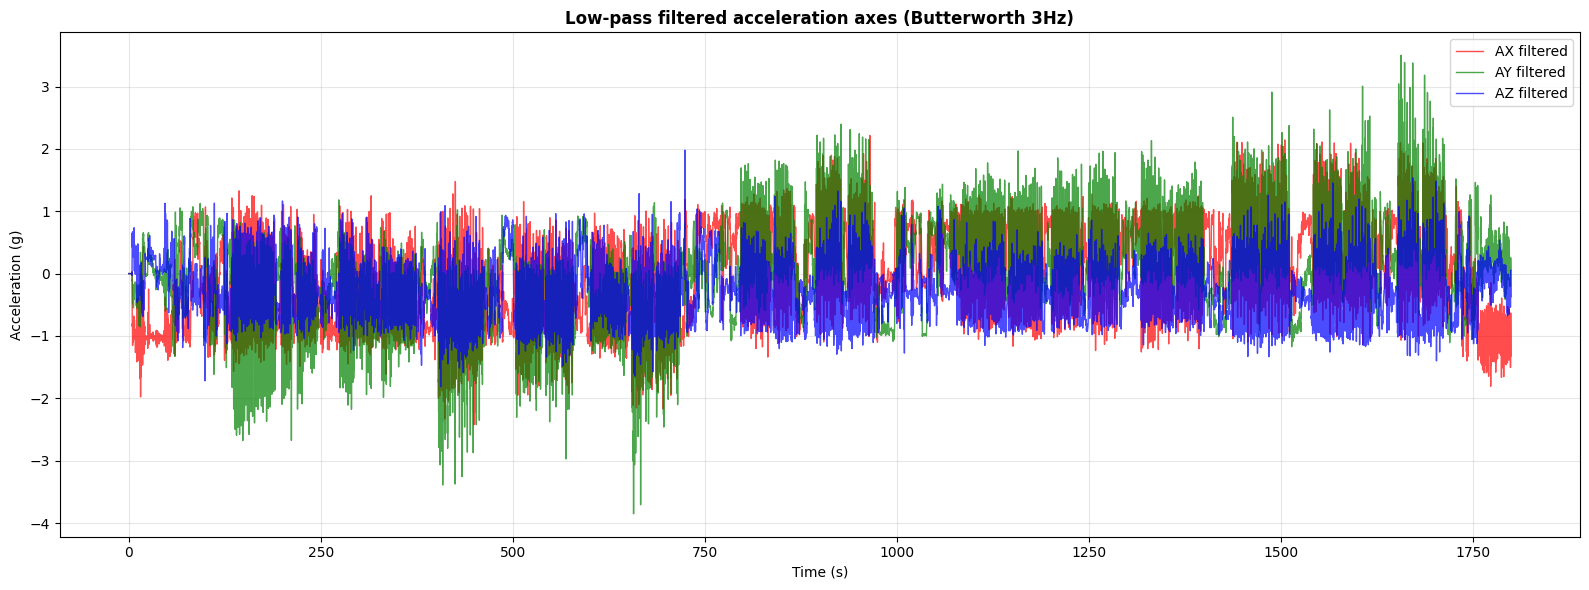

Filtered axes displayed

Computing FFT with Tukey window...
FFT computed with Tukey window


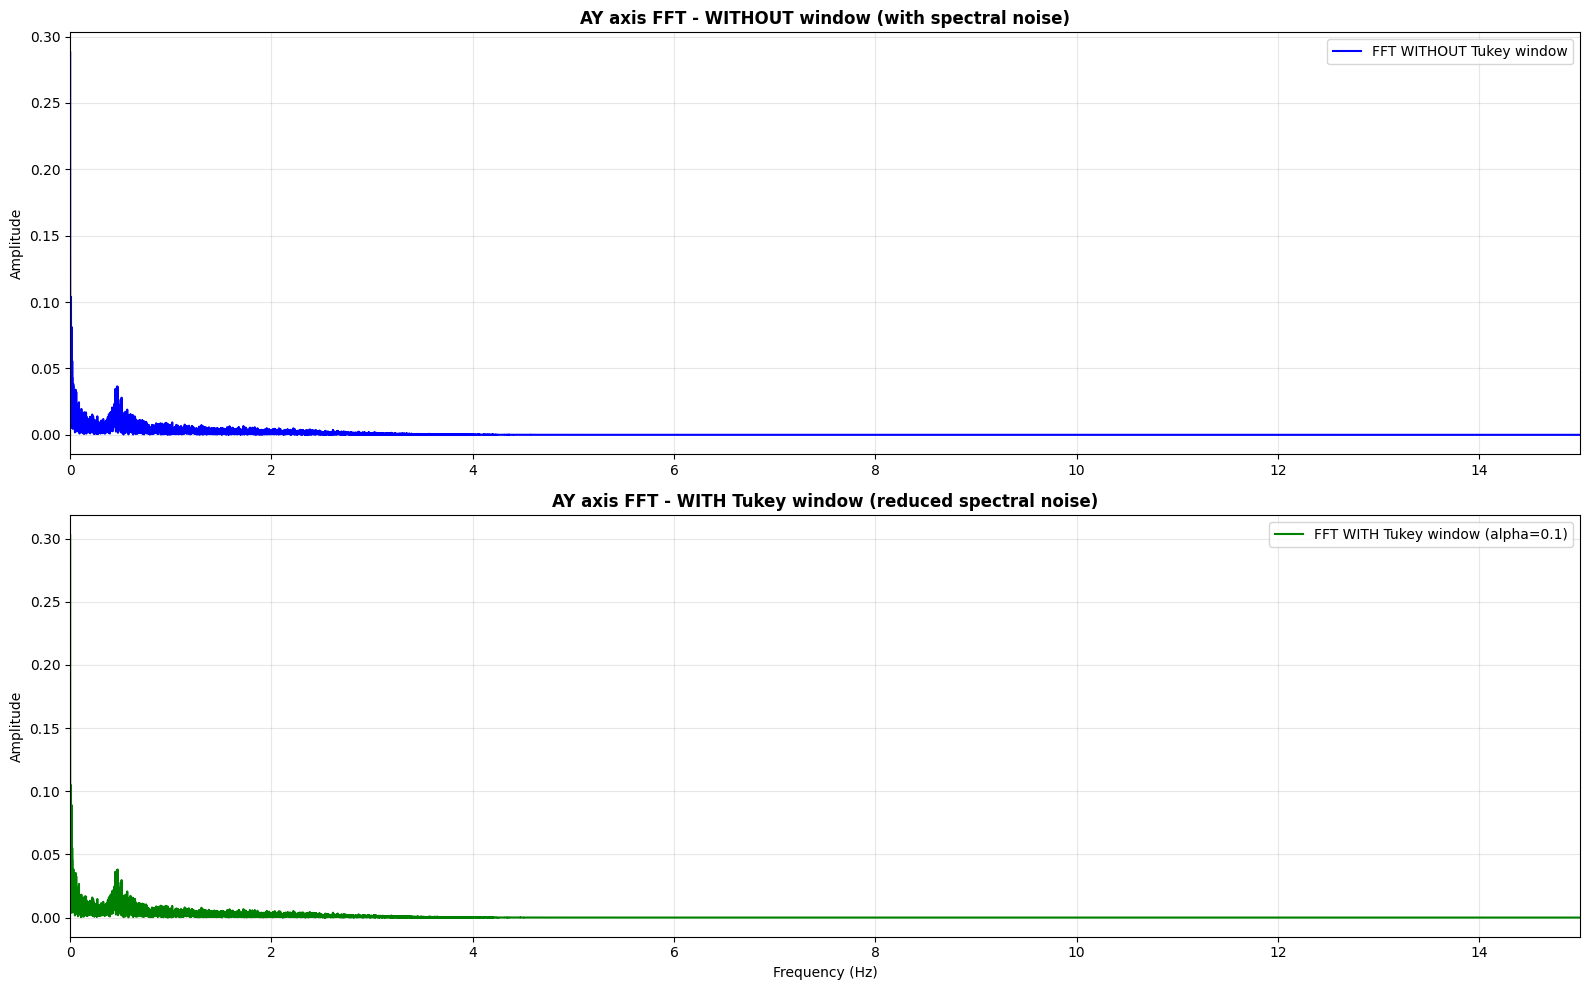

FFT compared (with/without window)


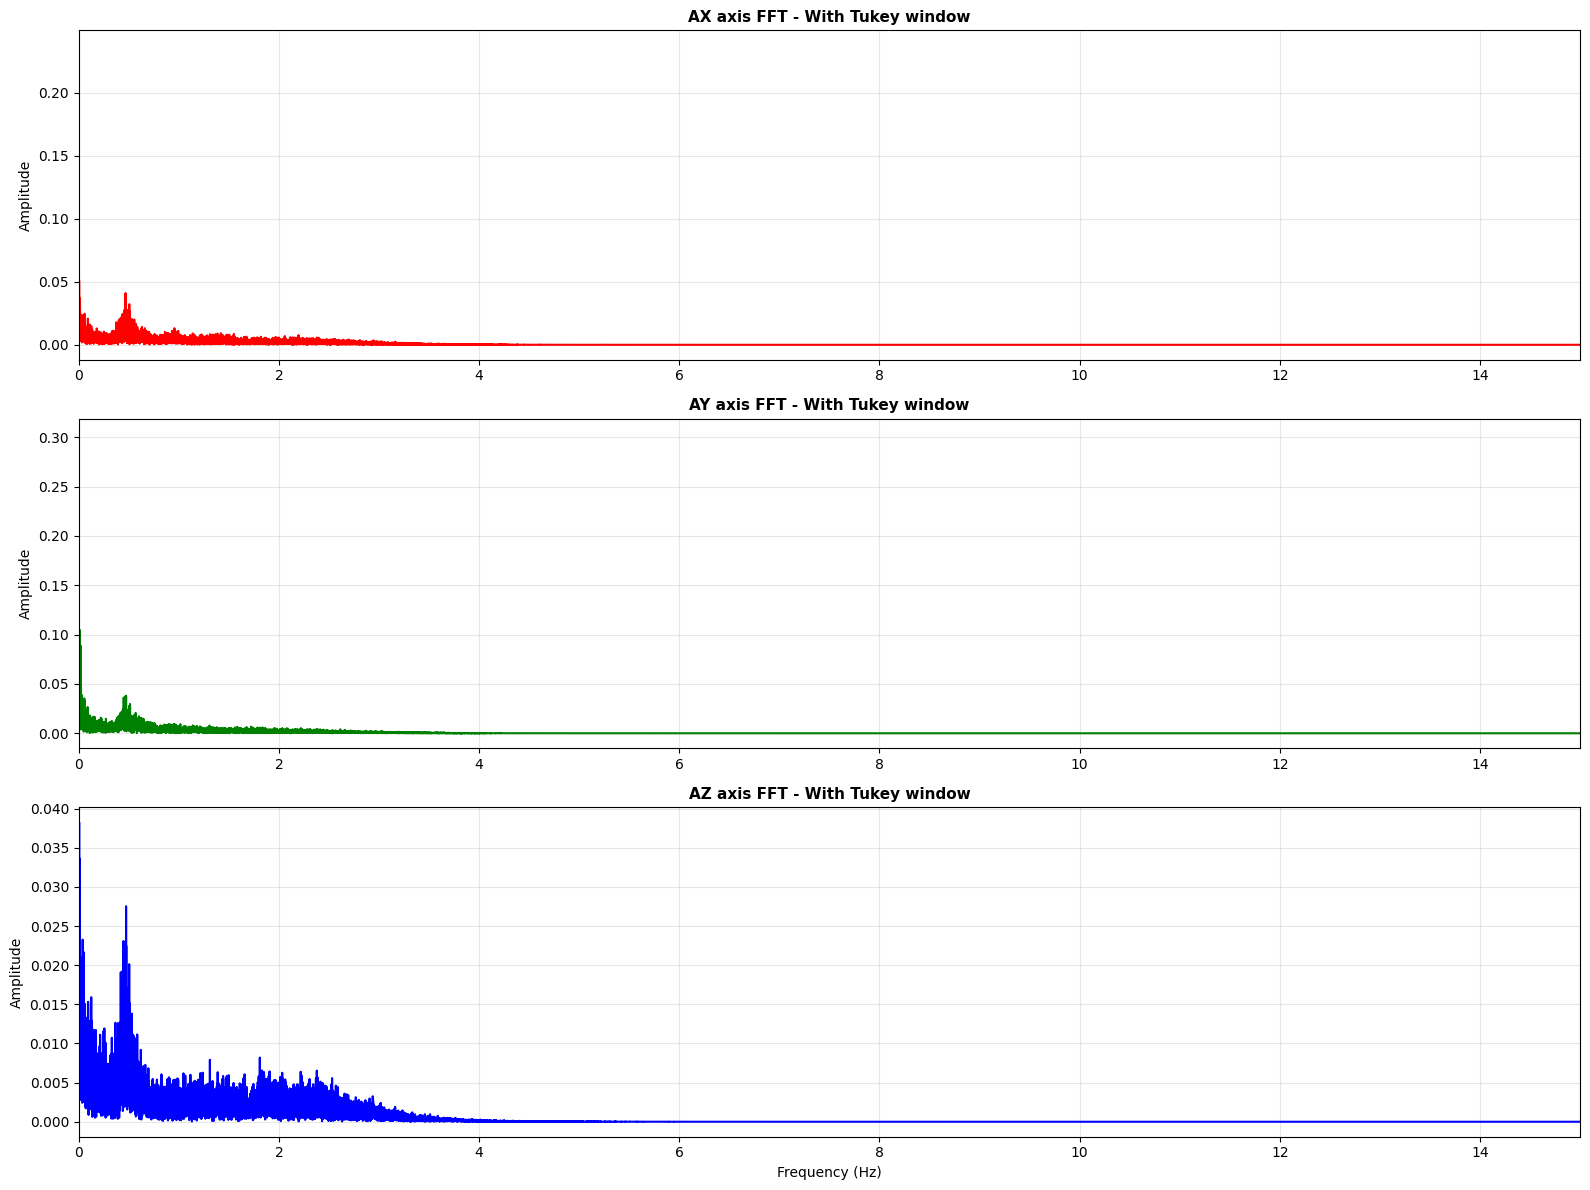

FFT of all 3 axes displayed


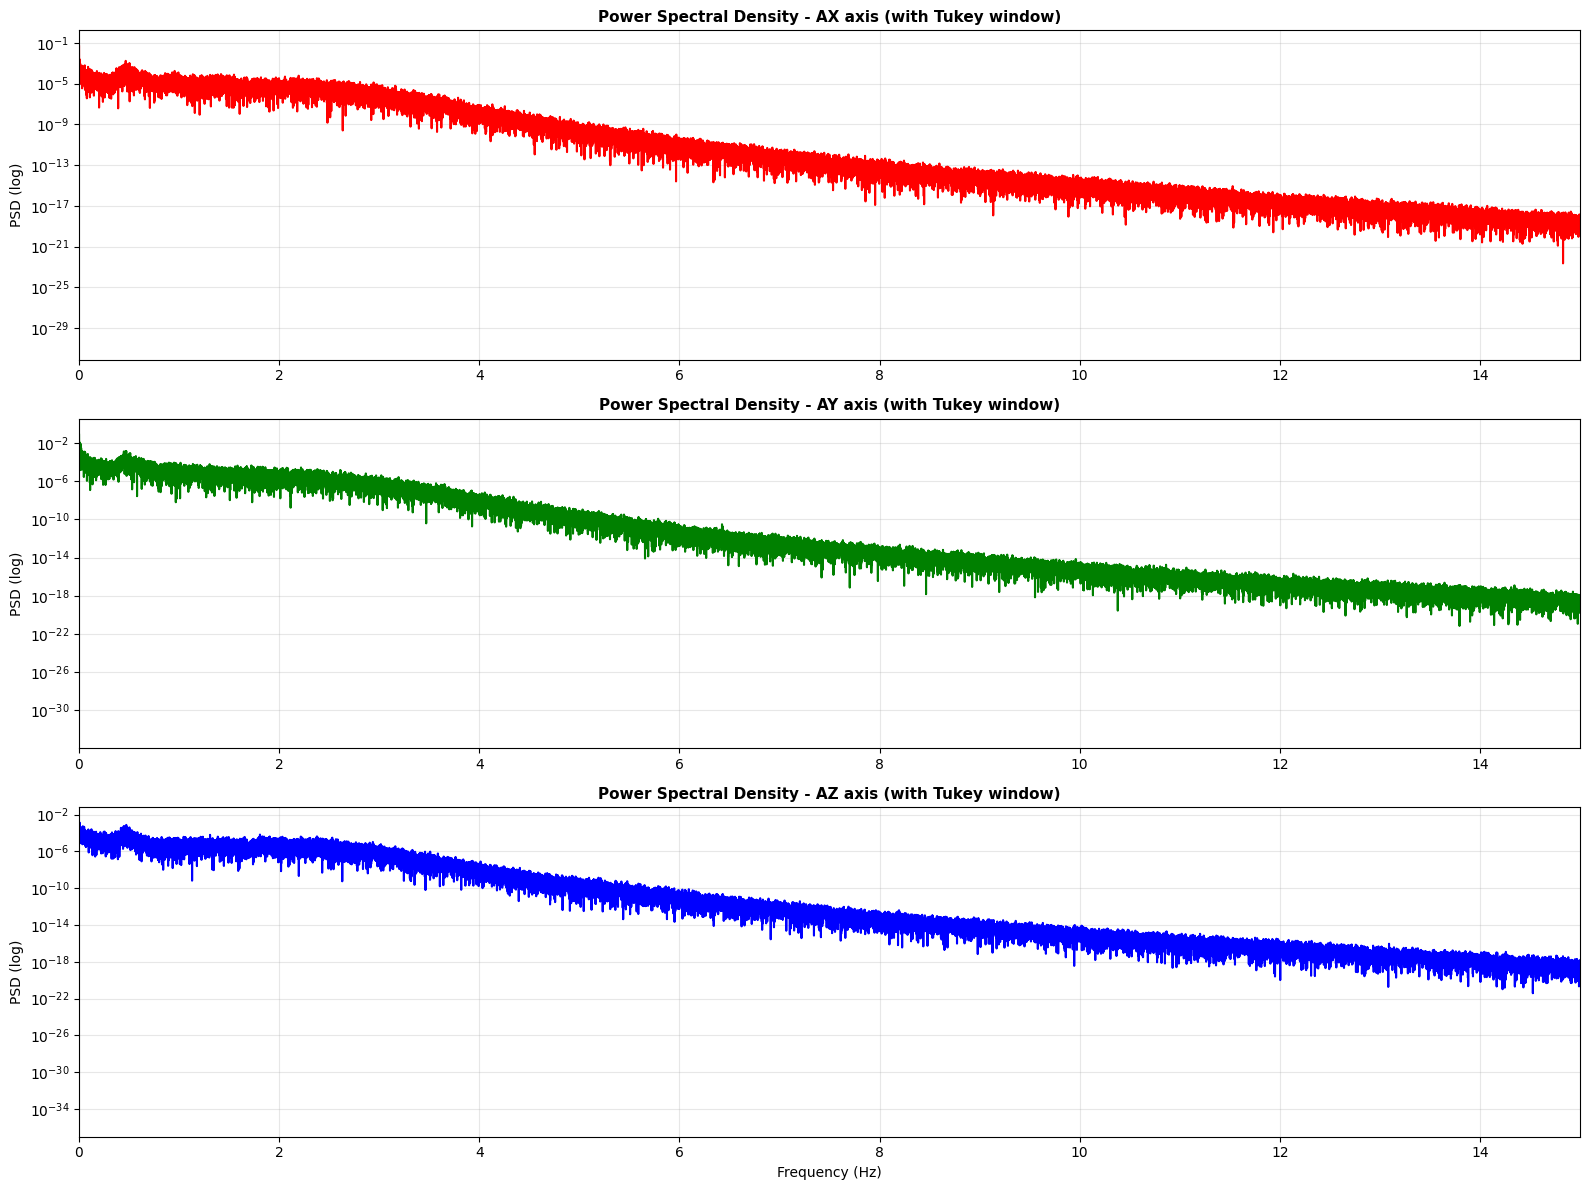

PSD displayed

CYCLE DETECTION
Number of detected peaks: 557
Minimum cycle duration: 0.8 s
Minimum prominence: 1.0


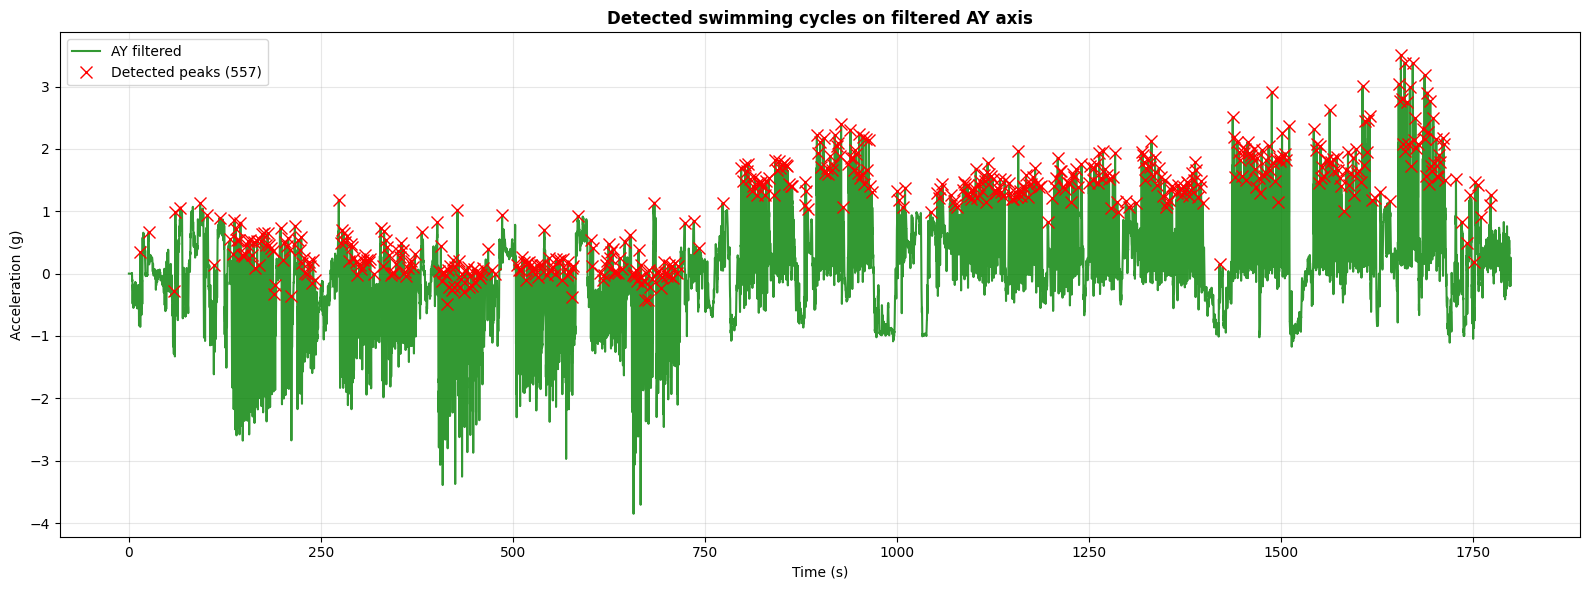

Detected cycles displayed

CYCLE STATISTICS
Number of cycles: 557
Average period between cycles: 3.16 s
Period standard deviation: 4.16 s
Average frequency: 0.32 Hz
Average cadence: 19.0 cycles/min

Peak amplitudes:
Min: -0.483 g
Max: 3.502 g
Mean: 1.065 g
Std dev: 0.812 g


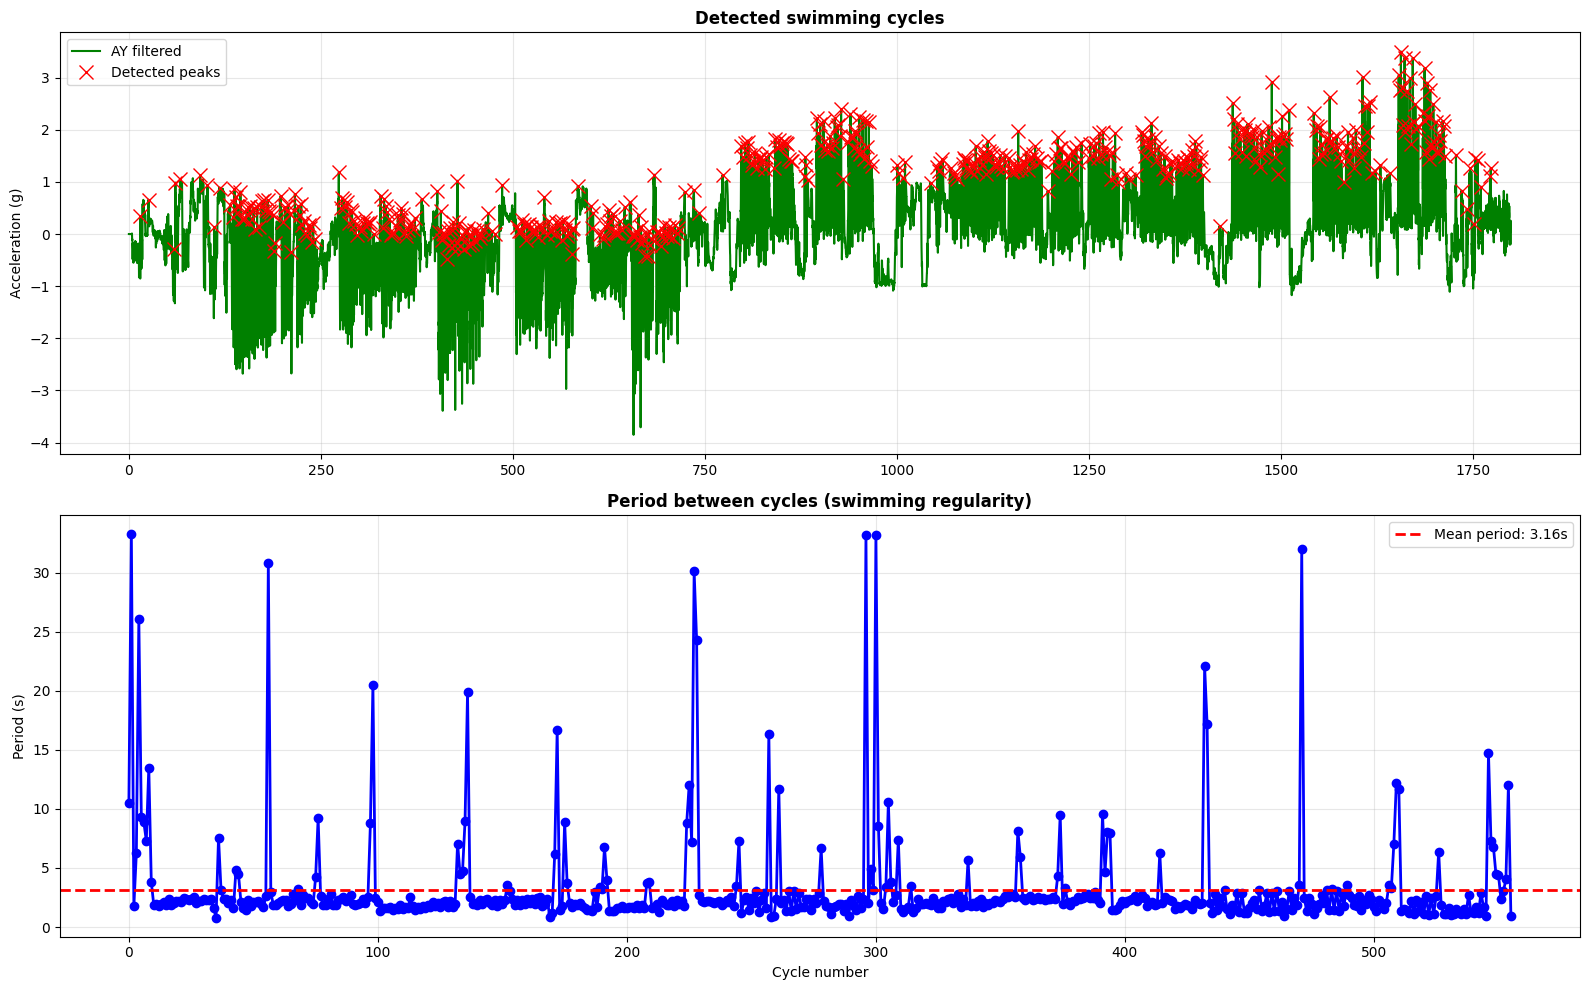

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.signal.windows import tukey

# ==============================================================
# 0. LOAD DATA
# ==============================================================
df = pd.read_csv("natationdonnes.csv")

df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax',
    'Accel-Y (g)': 'ay',
    'Accel-Z (g)': 'az'
}, inplace=True)

print("Data loaded:", len(df), "samples")

# ==============================================================
# 1. ESTIMATE SAMPLING FREQUENCY fs
# ==============================================================
fs = 100  # Known sampling frequency
df["time_sec"] = np.arange(len(df)) / fs

print("Sampling frequency: fs = 100 Hz")

# ==============================================================
# 2. DEFINE BUTTERWORTH LOW-PASS FILTER
# ==============================================================
def lowpass_filter(data, fs, cutoff=3, order=4):
    """
    Apply a Butterworth low-pass filter
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

print("Butterworth filter defined: cutoff = 3 Hz, order = 4")

# ==============================================================
# 3. APPLY FILTER TO EACH AXIS
# ==============================================================
df["ax_filt"] = lowpass_filter(df["ax"].values, fs)
df["ay_filt"] = lowpass_filter(df["ay"].values, fs)
df["az_filt"] = lowpass_filter(df["az"].values, fs)

print("Filter applied to all 3 axes")

# ==============================================================
# 4. APPLY TUKEY WINDOW FOR FFT
# ==============================================================
alpha = 0.1
window_tukey = tukey(len(df), alpha=alpha)

df["ax_windowed"] = df["ax_filt"] * window_tukey
df["ay_windowed"] = df["ay_filt"] * window_tukey
df["az_windowed"] = df["az_filt"] * window_tukey

print(f"Tukey window (alpha={alpha}) applied for FFT")

# ==============================================================
# 5. VISUALIZE FILTERED AXES
# ==============================================================
plt.figure(figsize=(16, 6))
plt.plot(df["time_sec"], df["ax_filt"], color="red", linewidth=1, label="AX filtered", alpha=0.7)
plt.plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1, label="AY filtered", alpha=0.7)
plt.plot(df["time_sec"], df["az_filt"], color="blue", linewidth=1, label="AZ filtered", alpha=0.7)
plt.title("Low-pass filtered acceleration axes (Butterworth 3Hz)", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Filtered axes displayed")

# ==============================================================
# 6. COMPUTE FFT WITH TUKEY WINDOW
# ==============================================================
print("\nComputing FFT with Tukey window...")

def compute_fft_with_window(signal, fs, window):
    """Compute FFT with window"""
    signal_windowed = signal - np.mean(signal)
    signal_windowed = signal_windowed * window

    n = len(signal_windowed)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    # Normalization with Tukey coherence coefficient
    coherence_tukey = np.sum(window) / len(window)
    fft_vals = np.abs(np.fft.rfft(signal_windowed)) / (n * coherence_tukey)

    return freqs, fft_vals

freqs_ax, fft_ax = compute_fft_with_window(df["ax_filt"].values, fs, window_tukey)
freqs_ay, fft_ay = compute_fft_with_window(df["ay_filt"].values, fs, window_tukey)
freqs_az, fft_az = compute_fft_with_window(df["az_filt"].values, fs, window_tukey)

print("FFT computed with Tukey window")

# ==============================================================
# 7. DISPLAY FFT (WITHOUT vs WITH WINDOW)
# ==============================================================
# FFT without window (for comparison)
freqs_ay_no_window, fft_ay_no_window = compute_fft_with_window(df["ay_filt"].values, fs, np.ones(len(df)))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# FFT without window
axes[0].plot(freqs_ay_no_window, fft_ay_no_window, linewidth=1.5, color="blue", label="FFT WITHOUT Tukey window")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("Amplitude")
axes[0].set_title("AY axis FFT - WITHOUT window (with spectral noise)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# FFT with window
axes[1].plot(freqs_ay, fft_ay, linewidth=1.5, color="green", label="FFT WITH Tukey window (alpha=0.1)")
axes[1].set_xlim([0, 15])
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("AY axis FFT - WITH Tukey window (reduced spectral noise)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("FFT compared (with/without window)")

# ==============================================================
# 8. FFT OF ALL 3 AXES WITH TUKEY WINDOW
# ==============================================================
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(freqs_ax, fft_ax, linewidth=1.5, color="red")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("Amplitude")
axes[0].set_title("AX axis FFT - With Tukey window", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ay, fft_ay, linewidth=1.5, color="green")
axes[1].set_xlim([0, 15])
axes[1].set_ylabel("Amplitude")
axes[1].set_title("AY axis FFT - With Tukey window", fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(freqs_az, fft_az, linewidth=1.5, color="blue")
axes[2].set_xlim([0, 15])
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("Amplitude")
axes[2].set_title("AZ axis FFT - With Tukey window", fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("FFT of all 3 axes displayed")

# ==============================================================
# 9. POWER SPECTRAL DENSITY (PSD)
# ==============================================================
psd_ax = fft_ax ** 2
psd_ay = fft_ay ** 2
psd_az = fft_az ** 2

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].semilogy(freqs_ax, psd_ax, linewidth=1.5, color="red")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("PSD (log)")
axes[0].set_title("Power Spectral Density - AX axis (with Tukey window)", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].semilogy(freqs_ay, psd_ay, linewidth=1.5, color="green")
axes[1].set_xlim([0, 15])
axes[1].set_ylabel("PSD (log)")
axes[1].set_title("Power Spectral Density - AY axis (with Tukey window)", fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].semilogy(freqs_az, psd_az, linewidth=1.5, color="blue")
axes[2].set_xlim([0, 15])
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("PSD (log)")
axes[2].set_title("Power Spectral Density - AZ axis (with Tukey window)", fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("PSD displayed")

# ==============================================================
# 10. CYCLE DETECTION ON DOMINANT AXIS (AY)
# ==============================================================
print("\n" + "="*60)
print("CYCLE DETECTION")
print("="*60)

# Detection parameters
min_cycle_duration_s = 0.8
min_prominence = 1.0

# Detect peaks on dominant axis (AY filtered - WITHOUT window for detection)
peaks, properties = find_peaks(df["ay_filt"],
                               distance=int(fs * min_cycle_duration_s),
                               prominence=min_prominence)

print("Number of detected peaks:", len(peaks))
print("Minimum cycle duration:", min_cycle_duration_s, "s")
print("Minimum prominence:", min_prominence)

# ==============================================================
# 11. VISUALIZE DETECTED CYCLES
# ==============================================================
plt.figure(figsize=(16, 6))
plt.plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1.5, label="AY filtered", alpha=0.8)
plt.plot(df["time_sec"].iloc[peaks], df["ay_filt"].iloc[peaks], "rx", markersize=8,
         label=f"Detected peaks ({len(peaks)})", linewidth=2)
plt.title("Detected swimming cycles on filtered AY axis", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Detected cycles displayed")

# ==============================================================
# 12. CYCLE STATISTICS
# ==============================================================
if len(peaks) > 1:
    time_between_peaks = np.diff(df["time_sec"].iloc[peaks].values)

    freq_cycles_per_sec = 1.0 / np.mean(time_between_peaks)
    freq_cycles_per_min = freq_cycles_per_sec * 60

    print("\n" + "="*60)
    print("CYCLE STATISTICS")
    print("="*60)
    print("Number of cycles:", len(peaks))
    print("Average period between cycles:", round(np.mean(time_between_peaks), 2), "s")
    print("Period standard deviation:", round(np.std(time_between_peaks), 2), "s")
    print("Average frequency:", round(freq_cycles_per_sec, 2), "Hz")
    print("Average cadence:", round(freq_cycles_per_min, 1), "cycles/min")
    print("="*60)

    amplitudes = df["ay_filt"].iloc[peaks].values
    print("\nPeak amplitudes:")
    print("Min:", round(np.min(amplitudes), 3), "g")
    print("Max:", round(np.max(amplitudes), 3), "g")
    print("Mean:", round(np.mean(amplitudes), 3), "g")
    print("Std dev:", round(np.std(amplitudes), 3), "g")

    # Plot with statistics
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1.5, label="AY filtered")
    ax1.plot(df["time_sec"].iloc[peaks], df["ay_filt"].iloc[peaks], "rx", markersize=10, label="Detected peaks")
    ax1.set_ylabel("Acceleration (g)")
    ax1.set_title("Detected swimming cycles", fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(range(len(time_between_peaks)), time_between_peaks, "bo-", linewidth=2, markersize=6)
    ax2.axhline(np.mean(time_between_peaks), color="red", linestyle="--", linewidth=2,
                label=f"Mean period: {round(np.mean(time_between_peaks), 2)}s")
    ax2.set_xlabel("Cycle number")
    ax2.set_ylabel("Period (s)")
    ax2.set_title("Period between cycles (swimming regularity)", fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("Not enough cycles detected")


In [ ]:
total_duration_s = len(df) / fs
cycle_cadence_per_min = (len(peaks) / total_duration_s) * 60

print("Total duration:", total_duration_s, "seconds")
print("Number of cycles:", len(peaks))
print("Cadence:", cycle_cadence_per_min, "cycles/min")


Total duration: 1800.0 seconds
Number of cycles: 557
Cadence: 18.566666666666666 cycles/min


In [ ]:
print(df_filtered.columns)


Index(['time', 'ax(g)', 'ay(g)', 'az(g)', 'time_sec'], dtype='object')


In [ ]:
print(df_filtered.columns)



Index(['time', 'ax(g)', 'ay(g)', 'az(g)', 'time_sec'], dtype='object')


In [ ]:
df_filtered["ax_filt"] = lowpass_filter(df_filtered["ax(g)"].values, fs)
df_filtered["ay_filt"] = lowpass_filter(df_filtered["ay(g)"].values, fs)
df_filtered["az_filt"] = lowpass_filter(df_filtered["az(g)"].values, fs)


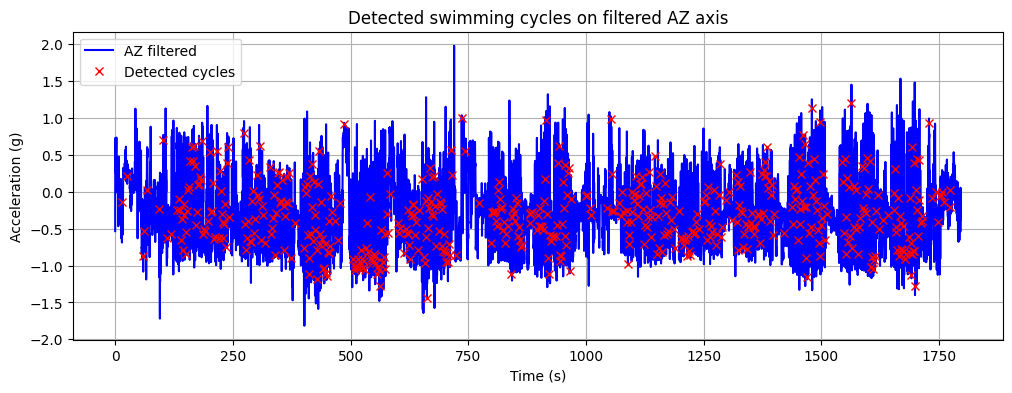

In [ ]:
plt.figure(figsize=(12, 4))

# Plot the filtered AZ signal
plt.plot(df_filtered["time_sec"], df_filtered["az_filt"], color="blue", label="AZ filtered")

# Plot the detected swimming cycles (peaks)
plt.plot(df_filtered["time_sec"].iloc[peaks], df_filtered["az_filt"].iloc[peaks], "rx", label="Detected cycles")

plt.title("Detected swimming cycles on filtered AZ axis")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
n_cycles_ax = len(find_peaks(df_filtered["ax_filt"], distance=int(fs*1.0), prominence=0.5)[0])
n_cycles_ay = len(find_peaks(df_filtered["ay_filt"], distance=int(fs*1.0), prominence=0.5)[0])
print("Cycles AX :", n_cycles_ax)
print("Cycles AY :", n_cycles_ay)


Cycles AX : 722
Cycles AY : 675


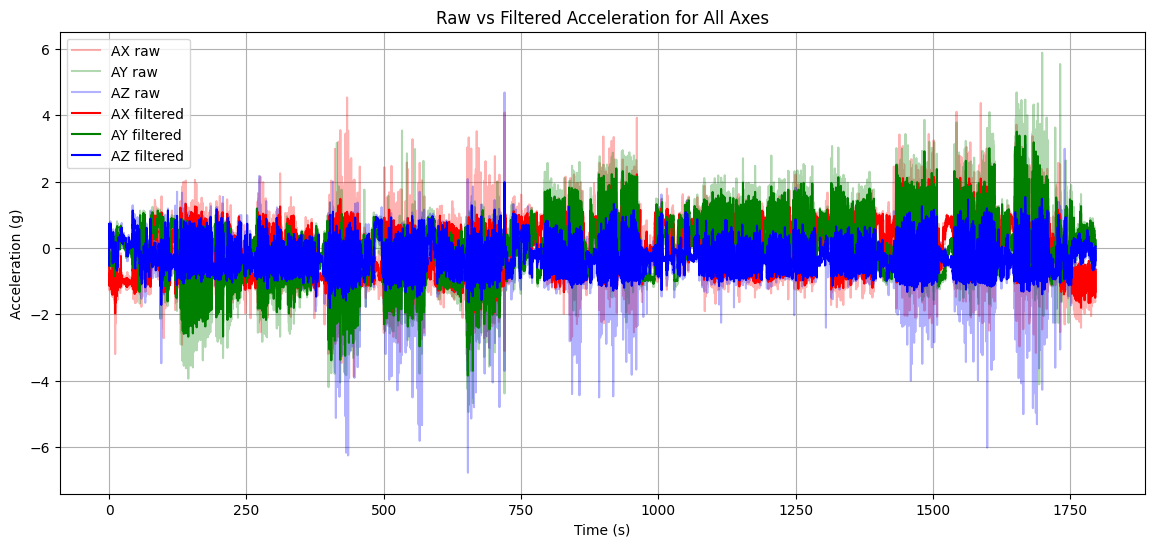

In [ ]:
plt.figure(figsize=(14, 6))

# Raw AX, AY, AZ signals (semi-transparent)
plt.plot(df_filtered["time_sec"], df_filtered["ax(g)"], color="red", alpha=0.3, label="AX raw")
plt.plot(df_filtered["time_sec"], df_filtered["ay(g)"], color="green", alpha=0.3, label="AY raw")
plt.plot(df_filtered["time_sec"], df_filtered["az(g)"], color="blue", alpha=0.3, label="AZ raw")

# Filtered AX, AY, AZ signals (solid)
plt.plot(df_filtered["time_sec"], df_filtered["ax_filt"], color="red", label="AX filtered")
plt.plot(df_filtered["time_sec"], df_filtered["ay_filt"], color="green", label="AY filtered")
plt.plot(df_filtered["time_sec"], df_filtered["az_filt"], color="blue", label="AZ filtered")

plt.title("Raw vs Filtered Acceleration for All Axes")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)
plt.show()


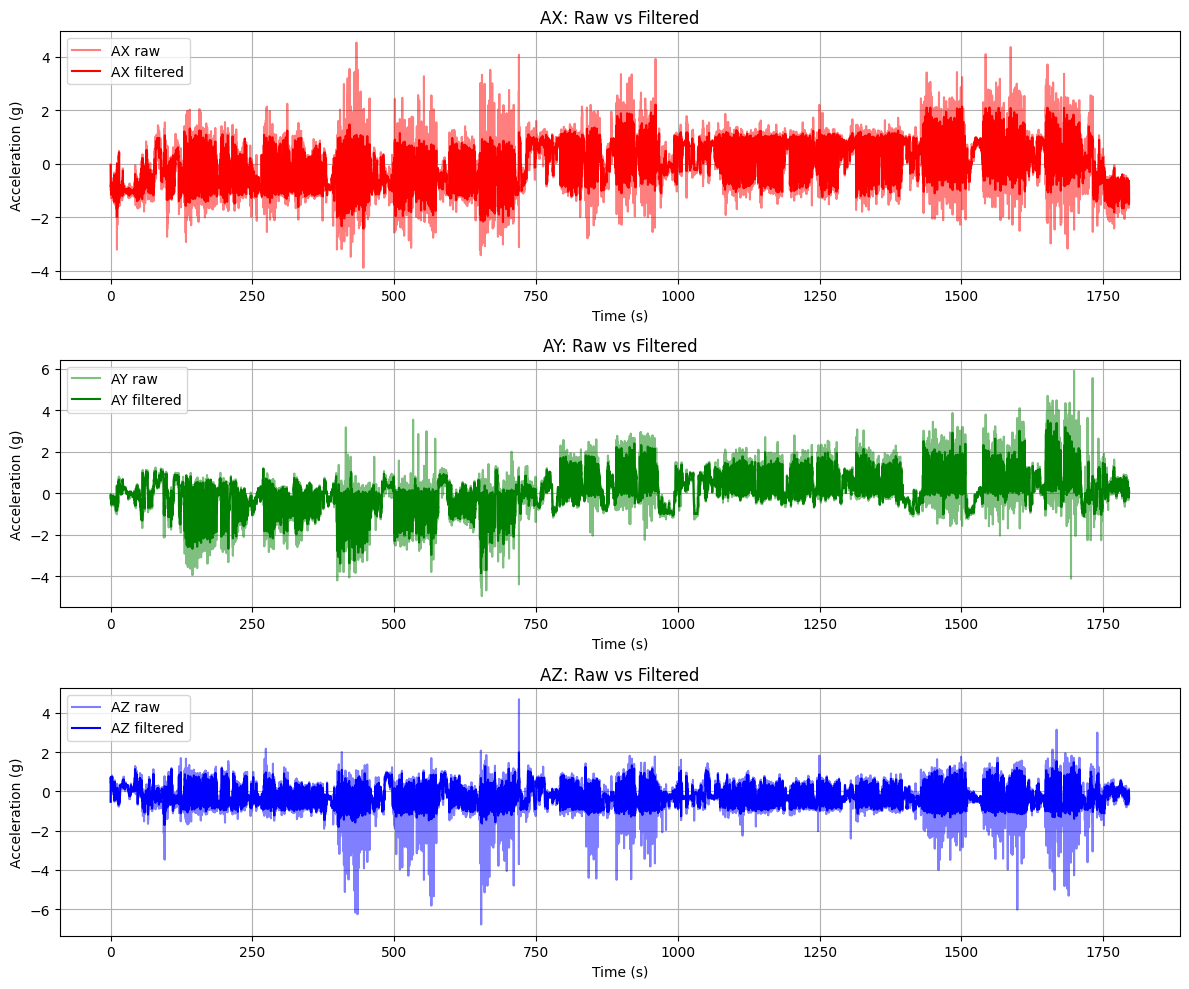

In [ ]:
plt.figure(figsize=(12, 10))

# -----------------------------
# AX
# -----------------------------
plt.subplot(3, 1, 1)
plt.plot(df_filtered["time_sec"], df_filtered["ax(g)"], color="red", alpha=0.5, label="AX raw")
plt.plot(df_filtered["time_sec"], df_filtered["ax_filt"], color="red", label="AX filtered")
plt.title("AX: Raw vs Filtered")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)

# -----------------------------
# AY
# -----------------------------
plt.subplot(3, 1, 2)
plt.plot(df_filtered["time_sec"], df_filtered["ay(g)"], color="green", alpha=0.5, label="AY raw")
plt.plot(df_filtered["time_sec"], df_filtered["ay_filt"], color="green", label="AY filtered")
plt.title("AY: Raw vs Filtered")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)

# -----------------------------
# AZ
# -----------------------------
plt.subplot(3, 1, 3)
plt.plot(df_filtered["time_sec"], df_filtered["az(g)"], color="blue", alpha=0.5, label="AZ raw")
plt.plot(df_filtered["time_sec"], df_filtered["az_filt"], color="blue", label="AZ filtered")
plt.title("AZ: Raw vs Filtered")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Norme de l'accélération filtrée

Number of cycles detected on the norm: 652


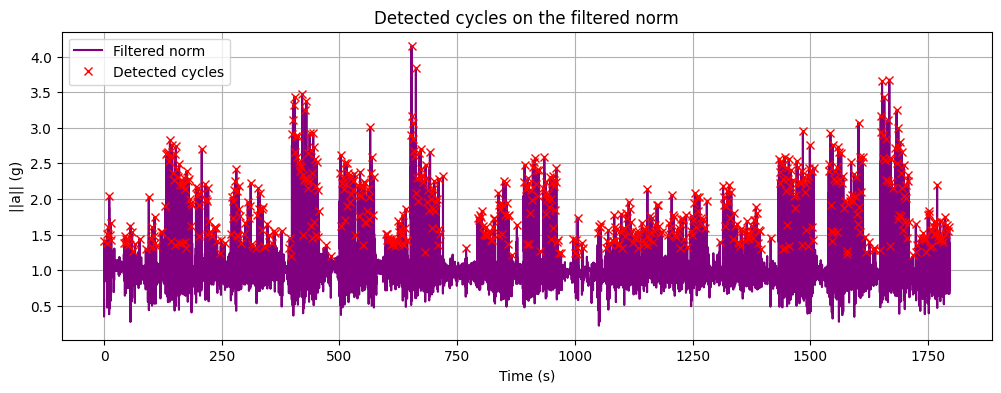

In [ ]:
# 1. Compute the filtered norm
df_filtered["a_norm_filt"] = np.sqrt(
    df_filtered["ax_filt"]**2 +
    df_filtered["ay_filt"]**2 +
    df_filtered["az_filt"]**2
)

# 2. Detect cycles on the norm
peaks, _ = find_peaks(
    df_filtered["a_norm_filt"],
    distance=int(fs * 1.0),  # minimum 1 second between peaks
    prominence=0.5           # minimum threshold to ignore noise
)

print("Number of cycles detected on the norm:", len(peaks))

# 3. Visualize the norm and detected cycles
plt.figure(figsize=(12, 4))
plt.plot(df_filtered["time_sec"], df_filtered["a_norm_filt"], color="purple", label="Filtered norm")
plt.plot(df_filtered["time_sec"].iloc[peaks], df_filtered["a_norm_filt"].iloc[peaks], "rx", label="Detected cycles")
plt.title("Detected cycles on the filtered norm")
plt.xlabel("Time (s)")
plt.ylabel("||a|| (g)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np

# ⚡ Define the signal to analyze
signal = df_filtered["a_norm_filt"].values

# ----------------------------------------------------------
# 1️⃣ Choose a threshold for acceleration phases
# ----------------------------------------------------------
mean_val = signal.mean()
std_val = signal.std()
threshold = mean_val + 0.8 * std_val  # adjustable as needed

print(f"Mean: {mean_val:.3f}, Std: {std_val:.3f}, Threshold: {threshold:.3f}")

# ----------------------------------------------------------
# 2️⃣ Create a boolean mask: True if the signal exceeds the threshold
# ----------------------------------------------------------
mask = signal > threshold

# ----------------------------------------------------------
# 3️⃣ Detect continuous segments above the threshold
# ----------------------------------------------------------
mask_int = mask.astype(int)
changes = np.diff(mask_int)

starts = np.where(changes == 1)[0] + 1
ends   = np.where(changes == -1)[0] + 1

# ----------------------------------------------------------
# 4️⃣ Handle edge cases
# ----------------------------------------------------------
if mask[0]:
    starts = np.r_[0, starts]
if mask[-1]:
    ends = np.r_[ends, len(signal)]

# ----------------------------------------------------------
# 5️⃣ Summary
# ----------------------------------------------------------
print(f"Raw segments detected: {len(starts)}")
for i, (s, e) in enumerate(zip(starts, ends), 1):
    print(f"Segment {i}: start={s}, end={e}, duration={e-s} samples")


Mean: 1.122, Std: 0.348, Threshold: 1.400
Raw segments detected: 917
Segment 1: start=63, end=68, duration=5 samples
Segment 2: start=607, end=620, duration=13 samples
Segment 3: start=664, end=676, duration=12 samples
Segment 4: start=741, end=749, duration=8 samples
Segment 5: start=890, end=905, duration=15 samples
Segment 6: start=952, end=960, duration=8 samples
Segment 7: start=1004, end=1015, duration=11 samples
Segment 8: start=1056, end=1073, duration=17 samples
Segment 9: start=1099, end=1114, duration=15 samples
Segment 10: start=1141, end=1149, duration=8 samples
Segment 11: start=1173, end=1187, duration=14 samples
Segment 12: start=1267, end=1279, duration=12 samples
Segment 13: start=1363, end=1383, duration=20 samples
Segment 14: start=1521, end=1539, duration=18 samples
Segment 15: start=4397, end=4407, duration=10 samples
Segment 16: start=4497, end=4504, duration=7 samples
Segment 17: start=4599, end=4607, duration=8 samples
Segment 18: start=4658, end=4659, duration

In [ ]:
# ----------------------------------------------------------
# Filter out segments that are too short (probably noise)
# min_length is adjustable (in number of samples)
# ----------------------------------------------------------
min_length = 1  # For example, 2000 samples; adjust according to fs and duration

segments = [(s, e, e - s) for s, e in zip(starts, ends) if (e - s) >= min_length]
print("Number of segments longer than min_length:", len(segments))

# ----------------------------------------------------------
# Sort segments by decreasing length
# ----------------------------------------------------------
segments_sorted = sorted(segments, key=lambda x: x[2], reverse=True)

# Select the two longest segments
(seg1_start, seg1_end, _) = segments_sorted[0]
(seg2_start, seg2_end, _) = segments_sorted[1]

print("Longest segment:", seg1_start, "->", seg1_end)
print("Second longest segment:", seg2_start, "->", seg2_end)

# ----------------------------------------------------------
# Extract the two acceleration phases
# ----------------------------------------------------------
signal1 = signal[seg1_start:seg1_end]
signal2 = signal[seg2_start:seg2_end]


Number of segments longer than min_length: 917
Longest segment: 67162 -> 67286
Second longest segment: 43962 -> 44081


Data loaded: 180000 samples ( 1800.0 seconds )
Available columns: ['time', 'ax(g)', 'ay(g)', 'az(g)', 'time_sec']
Applying Butterworth filter: fc = 3 Hz, order = 4
Norm computed: min = 6.570670835801631e-15 max = 4.153480825629848
Detection threshold: 0.527599404769237
Number of segments detected: 23

Top 5 longest segments:
Rank | Start (s) | End (s) | Duration (s)
------------------------------------------
1    |    656.5    |    859.0    |    202.4
2    |    1251.2    |    1419.6    |    168.4
3    |    897.2    |    1053.6    |    156.4
4    |    1109.2    |    1251.2    |    142.0
5    |    284.9    |    381.4    |    96.6


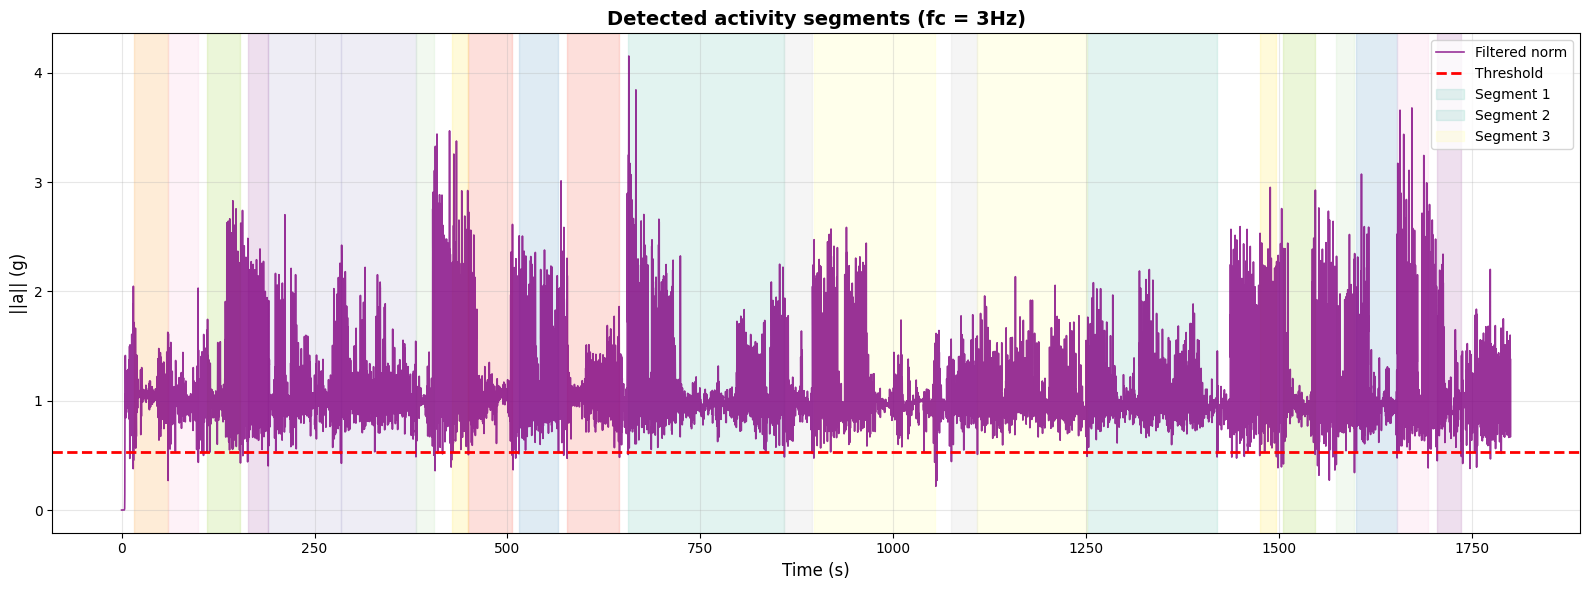


Segment 1: 65654 -> 85896 ( 20242 samples )
Segment 2: 125125 -> 141964 ( 16839 samples )


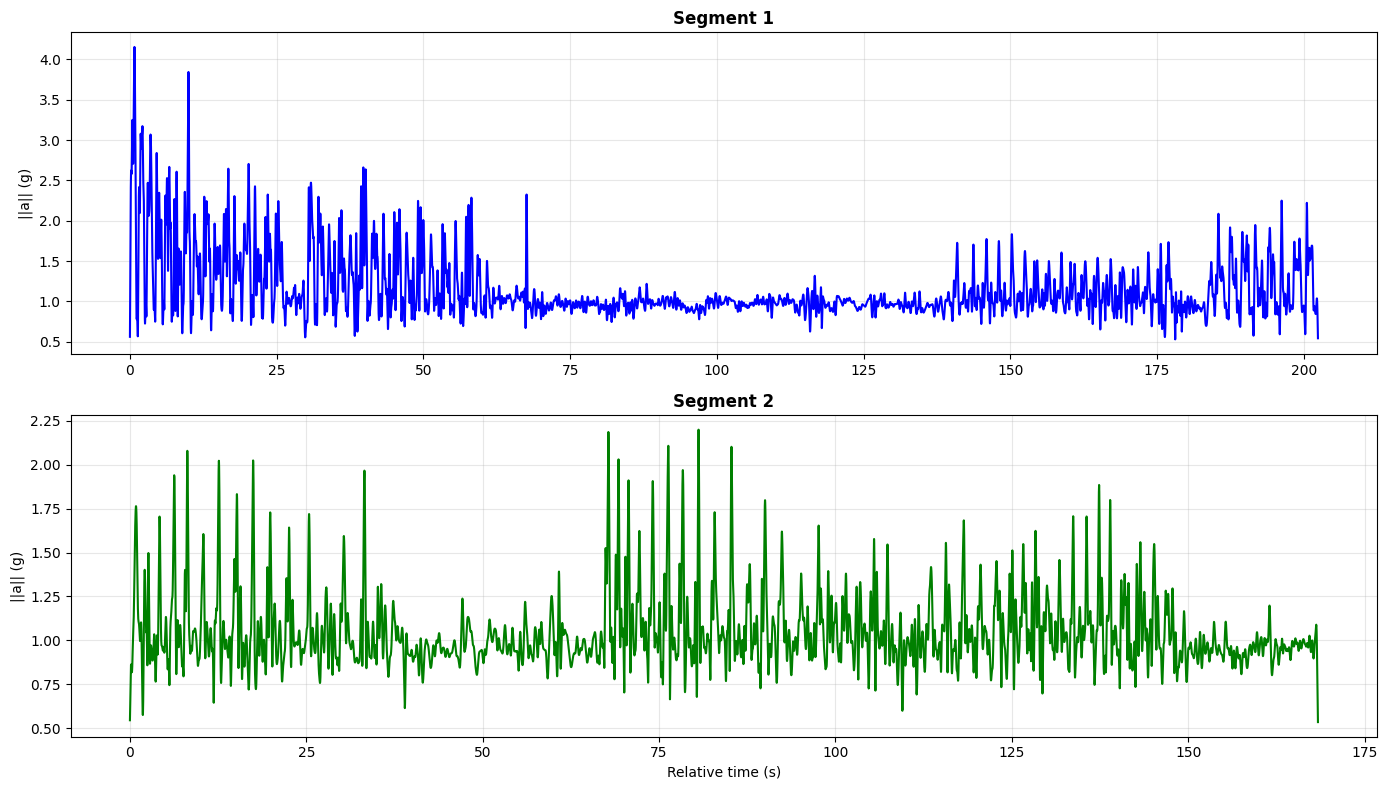

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ----------------------------------------------------------
# 1. LOAD DATA
# ----------------------------------------------------------
df = pd.read_csv("natationdonnes.csv")

# Clean column names
df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax(g)',
    'Accel-Y (g)': 'ay(g)',
    'Accel-Z (g)': 'az(g)'
}, inplace=True)

# Create time_sec column (seconds)
fs = 100  # Sampling frequency (Hz)
df["time_sec"] = np.arange(len(df)) / fs

print("Data loaded:", len(df), "samples (", len(df)/fs, "seconds )")
print("Available columns:", df.columns.tolist())

# ----------------------------------------------------------
# 2. PARAMETERS
# ----------------------------------------------------------
fc = 3                 # Low-pass filter cutoff frequency (Hz)
order = 4              # Filter order
min_length = 2000      # Minimum number of samples for a segment
threshold_factor = 1.5 # Threshold in multiples of standard deviation

# ----------------------------------------------------------
# 3. LOW-PASS FILTER AXES
# ----------------------------------------------------------
def lowpass_filter(signal, fc, fs, order=4):
    """Apply a Butterworth low-pass filter"""
    nyquist = fs / 2
    normalized_fc = fc / nyquist
    b, a = butter(order, normalized_fc, btype='low')
    return filtfilt(b, a, signal)

print("Applying Butterworth filter: fc =", fc, "Hz, order =", order)

df_filtered = pd.DataFrame()
df_filtered["time_sec"] = df["time_sec"]

# Filter each axis
for axis in ["ax(g)", "ay(g)", "az(g)"]:
    axis_name = axis.replace("(g)", "")
    df_filtered[axis_name + "_filt"] = lowpass_filter(df[axis].values, fc, fs, order)

# ----------------------------------------------------------
# 4. COMPUTE FILTERED NORM
# ----------------------------------------------------------
df_filtered["a_norm_filt"] = np.sqrt(
    df_filtered["ax_filt"]**2 +
    df_filtered["ay_filt"]**2 +
    df_filtered["az_filt"]**2
)

print("Norm computed: min =", df_filtered['a_norm_filt'].min(), "max =", df_filtered['a_norm_filt'].max())

# ----------------------------------------------------------
# 5. DETECT SIGNIFICANT SEGMENTS
# ----------------------------------------------------------
signal = df_filtered["a_norm_filt"].values
threshold = threshold_factor * np.std(signal)

print("Detection threshold:", threshold)

# Detect segments above threshold
above_thresh = signal > threshold
starts, ends = [], []
in_segment = False

for i, val in enumerate(above_thresh):
    if val and not in_segment:
        start = i
        in_segment = True
    elif not val and in_segment:
        end = i
        in_segment = False

        # Check minimum length
        if end - start >= min_length:
            starts.append(start)
            ends.append(end)

# Retrieve and sort segments
segments = [(s, e, e-s) for s, e in zip(starts, ends)]
segments_sorted = sorted(segments, key=lambda x: x[2], reverse=True)

print("Number of segments detected:", len(segments_sorted))
print("\nTop 5 longest segments:")
print("Rank | Start (s) | End (s) | Duration (s)")
print("------------------------------------------")

for i, (s, e, l) in enumerate(segments_sorted[:5]):
    t_start = df_filtered["time_sec"].iloc[s]
    t_end = df_filtered["time_sec"].iloc[e]
    duration = t_end - t_start
    print(f"{i+1}    |    {round(t_start,1)}    |    {round(t_end,1)}    |    {round(duration,1)}")

# ----------------------------------------------------------
# 6. VISUALIZATION
# ----------------------------------------------------------
plt.figure(figsize=(16, 6))

# Filtered norm signal
plt.plot(df_filtered["time_sec"], signal, label="Filtered norm",
         color="purple", linewidth=1.2, alpha=0.8)

# Threshold line
plt.axhline(threshold, color='red', linestyle='--', linewidth=2, label="Threshold")

# Colored segments
colors = plt.cm.Set3(np.linspace(0, 1, len(segments_sorted)))
for idx, (s, e, _) in enumerate(segments_sorted):
    t_start = df_filtered["time_sec"].iloc[s]
    t_end = df_filtered["time_sec"].iloc[e]
    if idx < 3:
        plt.axvspan(t_start, t_end, color=colors[idx], alpha=0.25,
                    label="Segment " + str(idx+1))
    else:
        plt.axvspan(t_start, t_end, color=colors[idx], alpha=0.25)

plt.title("Detected activity segments (fc = 3Hz)", fontsize=14, fontweight='bold')
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("||a|| (g)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 7. EXTRACT TWO LONGEST SEGMENTS
# ----------------------------------------------------------
if len(segments_sorted) >= 2:
    seg1_start, seg1_end, _ = segments_sorted[0]
    seg2_start, seg2_end, _ = segments_sorted[1]

    signal1 = signal[seg1_start:seg1_end]
    signal2 = signal[seg2_start:seg2_end]

    print("\nSegment 1:", seg1_start, "->", seg1_end, "(", len(signal1), "samples )")
    print("Segment 2:", seg2_start, "->", seg2_end, "(", len(signal2), "samples )")

    # Plot the two segments side by side
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    t1 = np.arange(len(signal1)) / fs
    t2 = np.arange(len(signal2)) / fs

    axes[0].plot(t1, signal1, linewidth=1.5, color='blue')
    axes[0].set_title("Segment 1", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("||a|| (g)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t2, signal2, linewidth=1.5, color='green')
    axes[1].set_title("Segment 2", fontsize=12, fontweight='bold')
    axes[1].set_ylabel("||a|| (g)")
    axes[1].set_xlabel("Relative time (s)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("Not enough segments detected")



→ 17 HIGH ACTIVITY ZONES DETECTED

Zone   | Start (s)  | End (s)    | Duration (s) | Peaks 
-----------------------------------------------------------------
Zone 1  |     128.1  |     199.3  |        71.2  |    36
Zone 2  |     203.5  |     236.3  |        32.8  |    12
Zone 3  |     268.3  |     303.6  |        35.3  |    16
Zone 4  |     310.7  |     344.2  |        33.5  |    13
Zone 5  |     393.9  |     460.6  |        66.6  |    40
Zone 6  |     500.3  |     570.9  |        70.6  |    40
Zone 7  |     601.1  |     714.5  |       113.4  |    62
Zone 8  |     797.6  |     860.2  |        62.6  |    30
Zone 9  |     889.1  |     968.7  |        79.5  |    41
Zone 10 |    1071.7  |    1177.2  |       105.5  |    46
Zone 11 |    1205.3  |    1230.4  |        25.1  |    11
Zone 12 |    1232.9  |    1270.2  |        37.3  |    14
Zone 13 |    1314.9  |    1390.4  |        75.5  |    33
Zone 14 |    1432.5  |    1507.7  |        75.1  |    44
Zone 15 |    1537.0  |    1617.6  |        

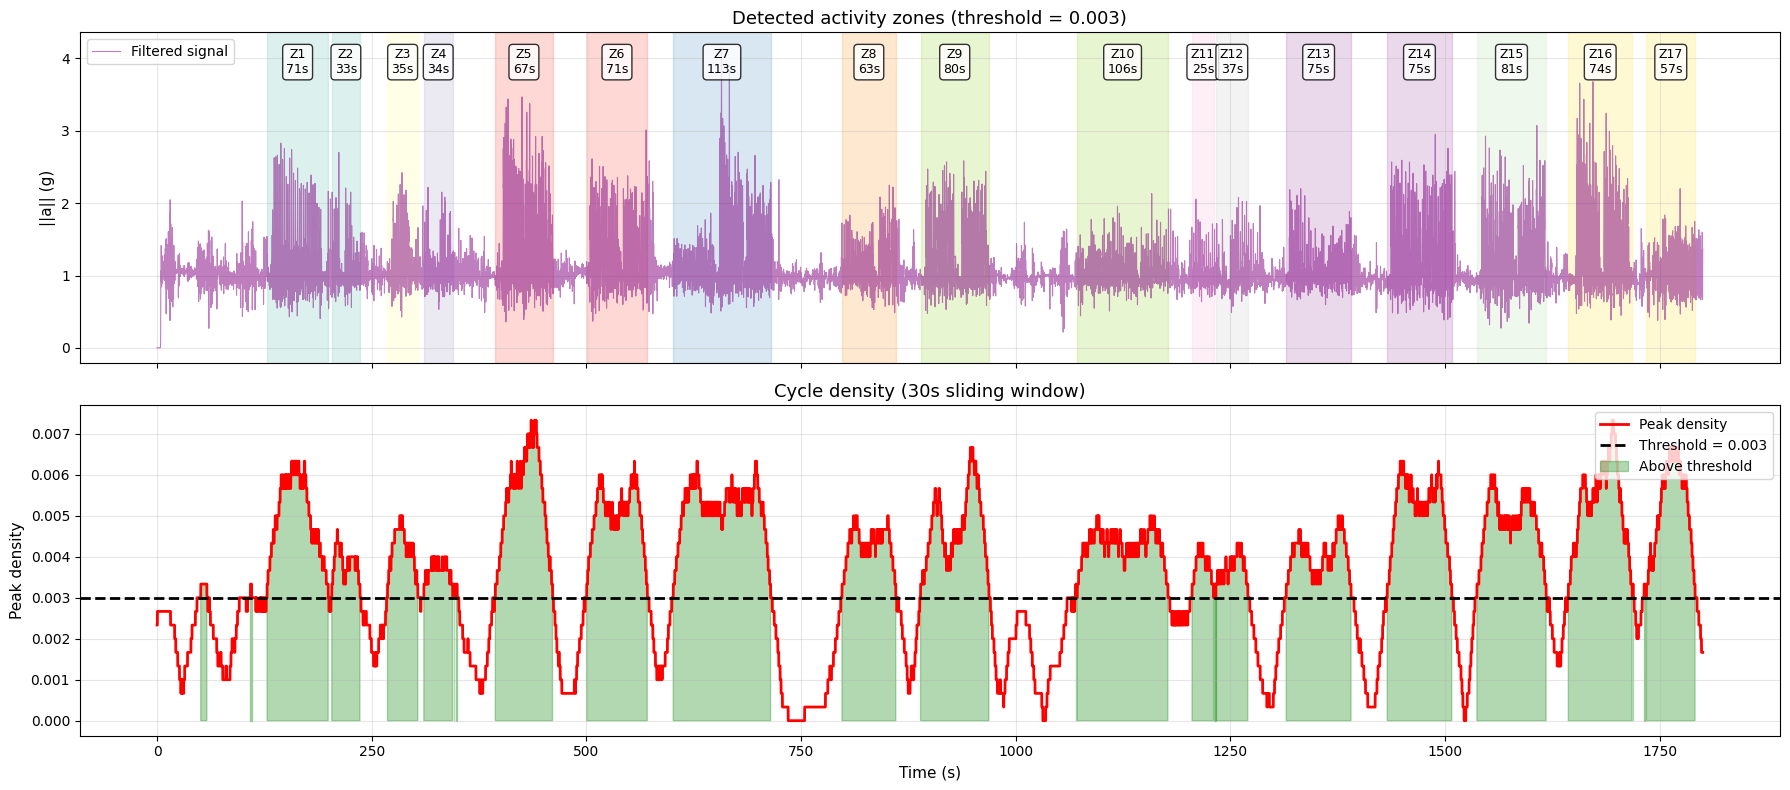

In [ ]:
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Create peak density signal
# ----------------------------------------------------------
density_signal = np.zeros(len(df_filtered))
density_signal[peaks] = 1

# ----------------------------------------------------------
# 2. Smooth over 30 seconds
# ----------------------------------------------------------
window_size = int(30 * fs)
density_smooth = uniform_filter1d(density_signal, size=window_size, mode='constant')

t_peaks = df_filtered["time_sec"].iloc[peaks].values

# ----------------------------------------------------------
# 3. Threshold
# ----------------------------------------------------------
threshold_density = 0.003

# ----------------------------------------------------------
# 4. Detect high activity zones
# ----------------------------------------------------------
high_activity = density_smooth > threshold_density

changes = np.diff(high_activity.astype(int))
starts = np.where(changes == 1)[0] + 1
ends = np.where(changes == -1)[0] + 1

# Handle edge cases
if len(high_activity) > 0 and high_activity[0]:
    starts = np.r_[0, starts]
if len(high_activity) > 0 and high_activity[-1]:
    ends = np.r_[ends, len(high_activity)]

# ----------------------------------------------------------
# 5. Filter out short zones and ensure indices are valid
# ----------------------------------------------------------
min_duration_samples = int(10 * fs)
max_index = len(df_filtered) - 1
valid_zones = []

n_zones = min(len(starts), len(ends))

for i in range(n_zones):
    start_idx = starts[i]
    end_idx = ends[i]

    # Clip indices to valid range
    start_idx = min(start_idx, max_index)
    end_idx = min(end_idx, max_index)

    # Check minimum duration
    if end_idx - start_idx >= min_duration_samples:
        valid_zones.append((start_idx, end_idx))

starts_clean = np.array([z[0] for z in valid_zones])
ends_clean = np.array([z[1] for z in valid_zones])

print(f"\n→ {len(starts_clean)} HIGH ACTIVITY ZONES DETECTED\n")

# ----------------------------------------------------------
# 6. Prepare summary table before plotting
# ----------------------------------------------------------
if len(starts_clean) > 0:
    print(f"{'Zone':<6} | {'Start (s)':<10} | {'End (s)':<10} | {'Duration (s)':<12} | {'Peaks':<6}")
    print("-" * 65)

    segments = []

    for i in range(len(starts_clean)):
        t_start = df_filtered["time_sec"].iloc[int(starts_clean[i])]
        t_end = df_filtered["time_sec"].iloc[int(ends_clean[i])]
        duration = t_end - t_start
        n_peaks = np.sum((t_peaks >= t_start) & (t_peaks <= t_end))

        print(f"Zone {i+1:<2} | {t_start:>9.1f}  | {t_end:>9.1f}  | {duration:>11.1f}  | {n_peaks:>5}")

        segments.append({
            "name": f"Zone {i+1}",
            "start": t_start,
            "end": t_end,
            "duration": duration,
            "n_peaks": n_peaks
        })

    print("\n✅ Variable 'segments' successfully created!")

    # ----------------------------------------------------------
    # 7. Plot the results
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

    # Panel 1: Filtered signal with highlighted zones
    axes[0].plot(df_filtered["time_sec"], df_filtered["a_norm_filt"],
                 color="purple", alpha=0.5, linewidth=0.8, label="Filtered signal")

    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))

    for i, seg in enumerate(segments):
        axes[0].axvspan(seg["start"], seg["end"], alpha=0.3, color=colors[i])

        mid_time = (seg["start"] + seg["end"]) / 2
        axes[0].text(mid_time, axes[0].get_ylim()[1]*0.95,
                     f"Z{i+1}\n{seg['duration']:.0f}s",
                     ha='center', va='top', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    axes[0].set_ylabel("||a|| (g)", fontsize=11)
    axes[0].set_title(f"Detected activity zones (threshold = {threshold_density})", fontsize=13)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Panel 2: Peak density with threshold
    axes[1].plot(df_filtered["time_sec"], density_smooth,
                 color='red', linewidth=2, label='Peak density')
    axes[1].axhline(threshold_density, color='black', linestyle='--',
                    linewidth=2, label=f'Threshold = {threshold_density}')
    axes[1].fill_between(df_filtered["time_sec"], 0, density_smooth,
                          where=high_activity, alpha=0.3, color='green',
                          label='Above threshold')

    axes[1].set_xlabel("Time (s)", fontsize=11)
    axes[1].set_ylabel("Peak density", fontsize=11)
    axes[1].set_title("Cycle density (30s sliding window)", fontsize=13)
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ No zones detected. Lower the threshold (e.g., threshold_density = 0.003)")


In [ ]:
Cycle Detection
Swimming cycles are detected as peaks in the filtered norm (||a||) of the acceleration.
Minimum distance and prominence thresholds are used to avoid false peaks.
Key metrics per segment are computed:
Number of cycles
Cycle frequency (Hz)
Cadence (cycles per minute)
Coefficient of variation of the cycle period (CV of stroke duration)
Detected cycles are saved with timestamps and amplitudes.

**Cycle Detection**

Swimming cycles are detected as peaks in the filtered norm (||a||) of the acceleration.
Minimum distance and prominence thresholds are used to avoid false peaks.
Key metrics per segment are computed:
Number of cycles
Cycle frequency (Hz)
Cadence (cycles per minute)
Coefficient of variation of the cycle period (CV of stroke duration)
Detected cycles are saved with timestamps and amplitudes.

Directories created:
  - results/
  - results/figures/
Data loaded: 180000 samples
Total duration: 1800.0 seconds
Butterworth 3Hz filter applied
Tukey window (alpha=0.1) applied for FFT
FFTs computed with Tukey window


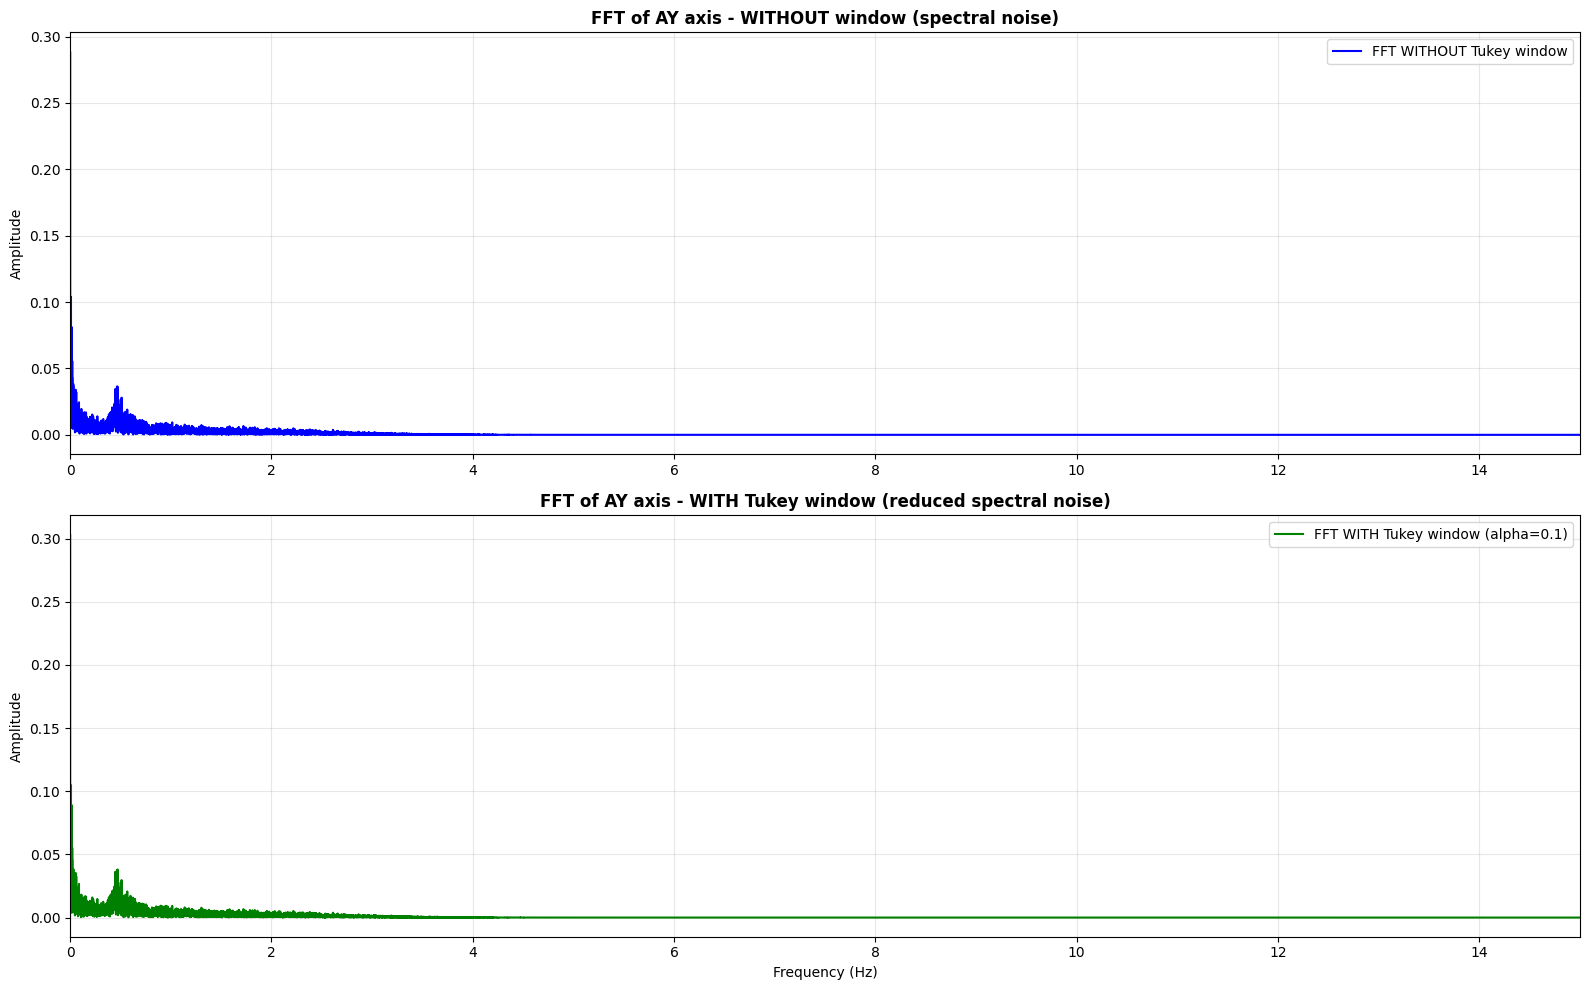


CYCLE DETECTION
Number of peaks detected: 557

COMPLETE CYCLE METRICS
n_cycles                       : 557
freq_hz                        : 0.316
cadence_cycles_per_min         : 19.0
SD_period_s                    : 4.1661
CV_period                      : 1.3171
amp_min                        : -0.483
amp_max                        : 3.502
amp_mean                       : 1.065
amp_std                        : 0.812

Metrics exported: results/cycles_metrics.csv
Cycle details exported: results/cycles_detail.csv
QC statistics exported: results/qc_summary.csv


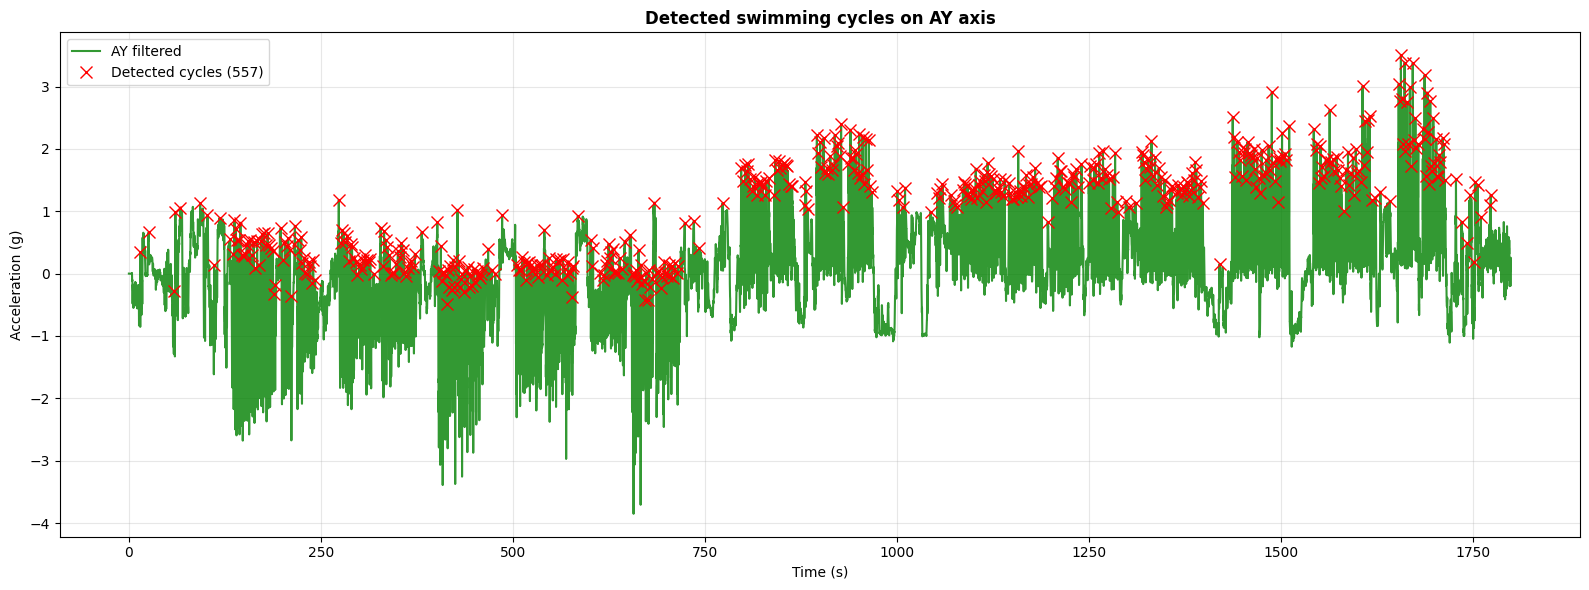

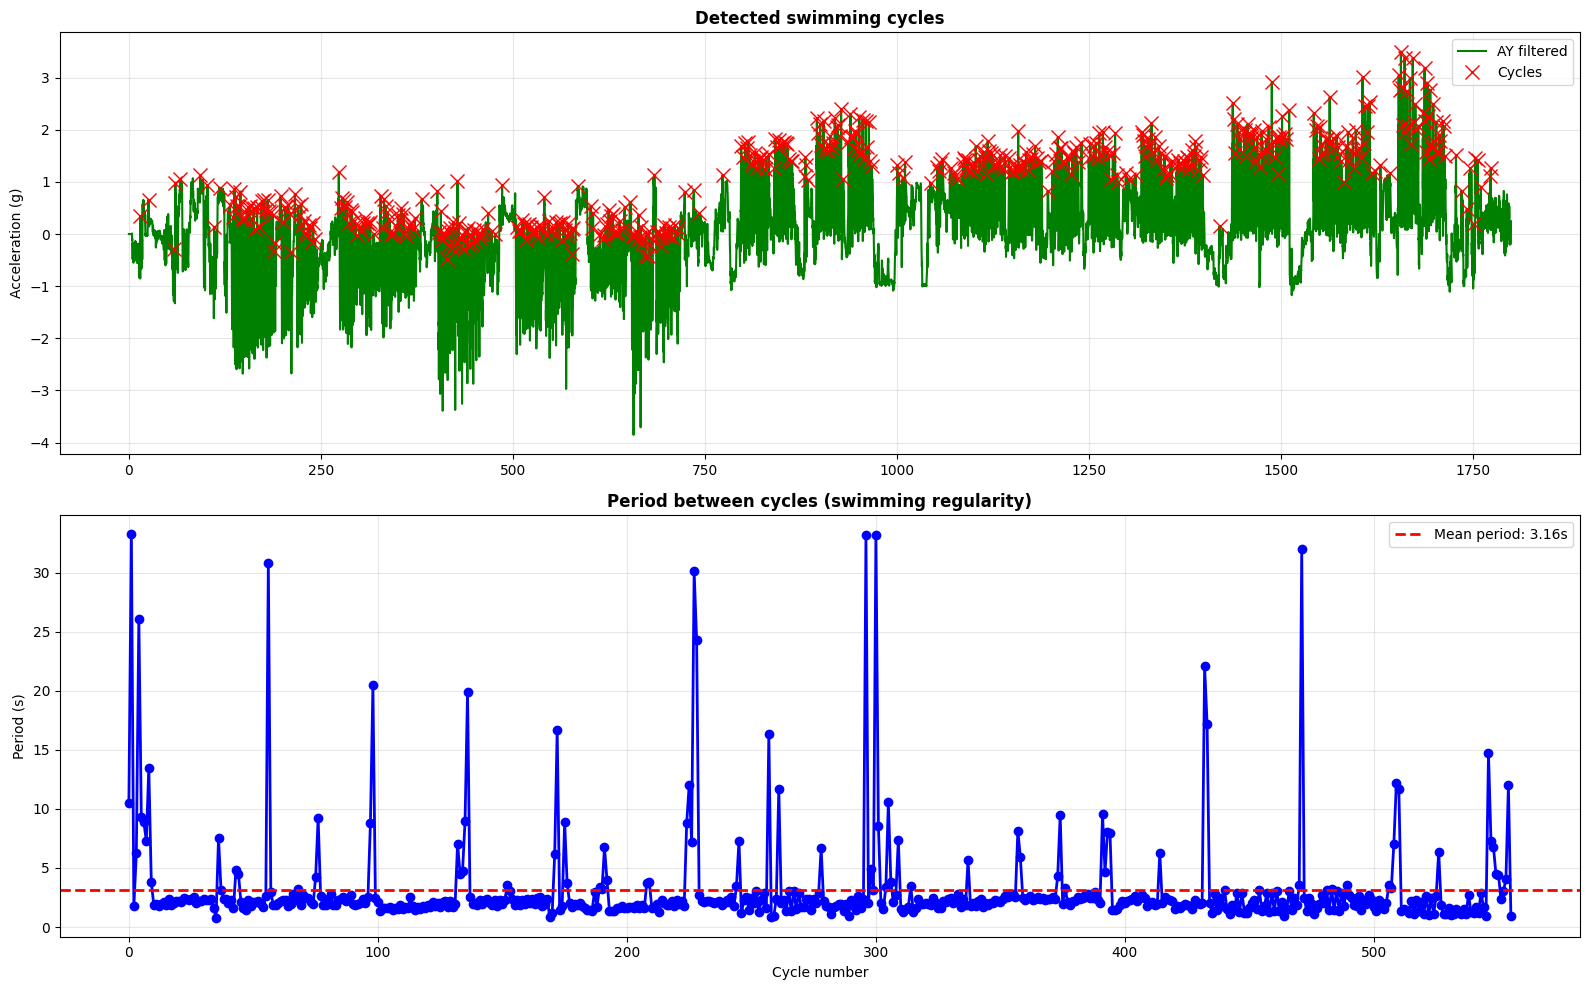

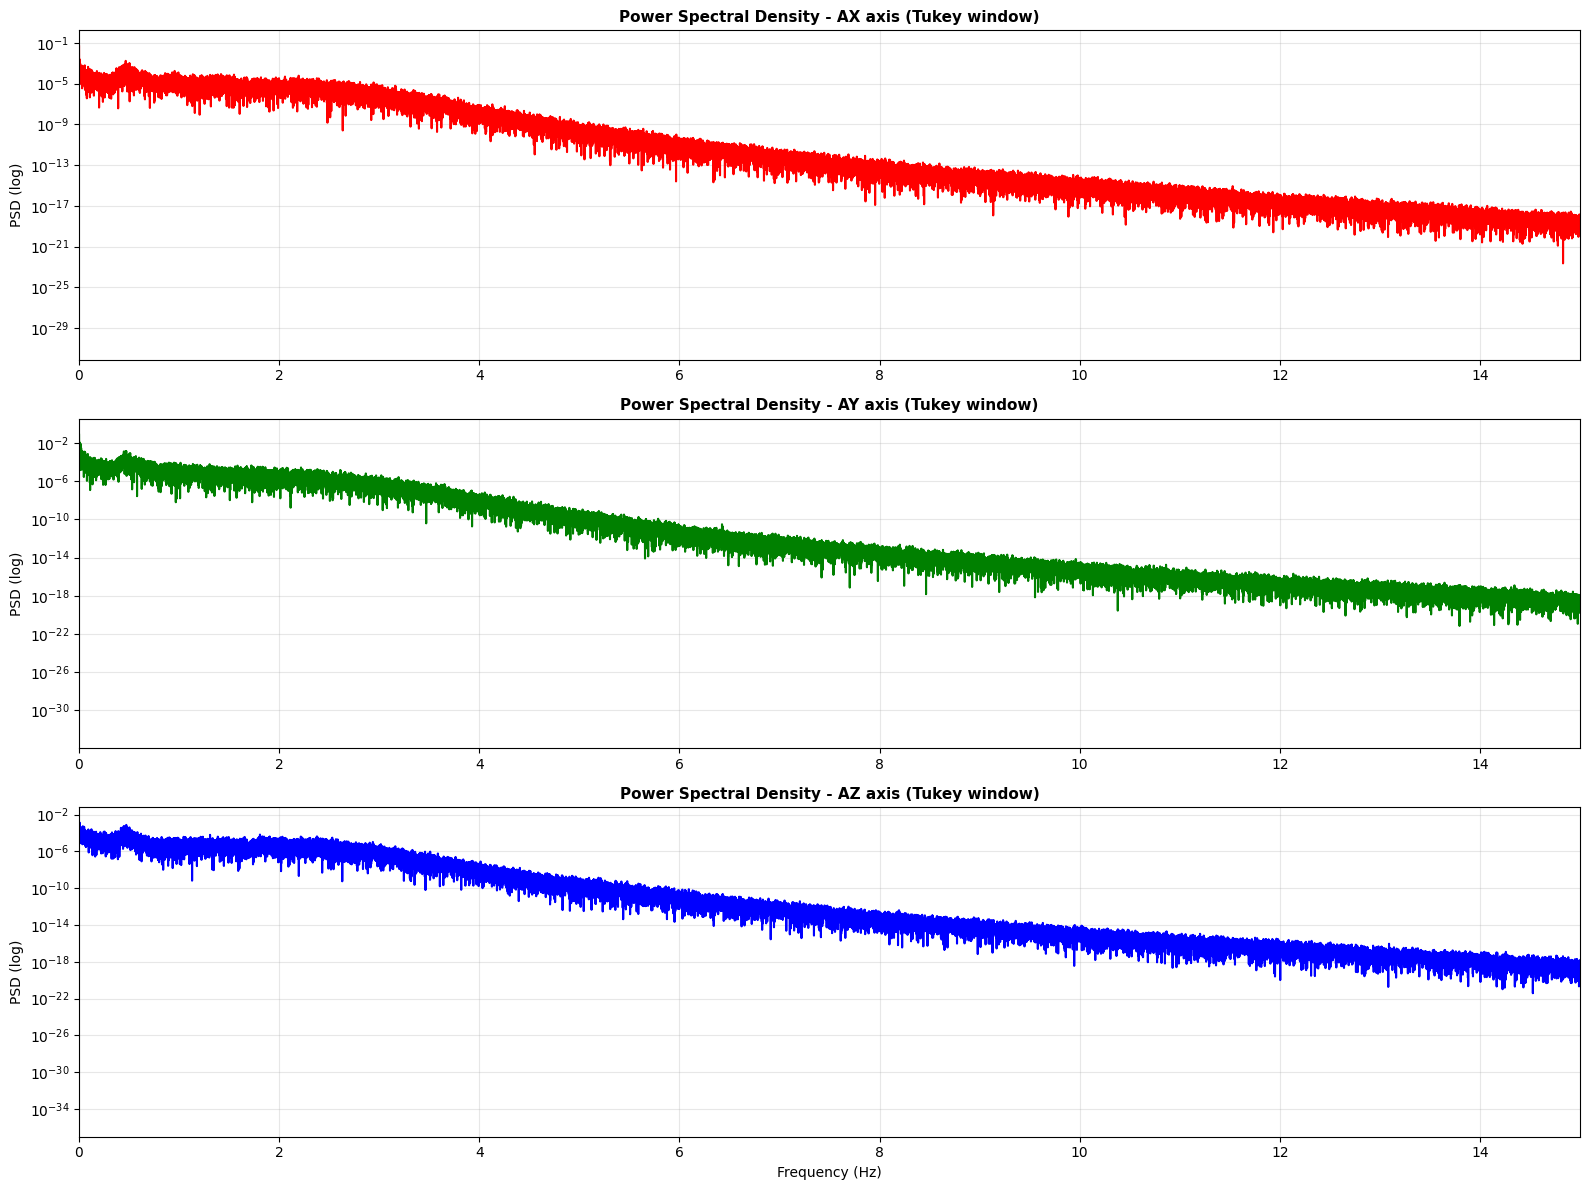


FINAL EXPORTS
CSV files:
  - results/cycles_metrics.csv
  - results/cycles_detail.csv
  - results/qc_summary.csv

PNG figures:
  - results/figures/fft_comparison_ay.png
  - results/figures/cycles_detected.png
  - results/figures/cycles_periodicity.png
  - results/figures/psd_all_axes.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt, find_peaks
from scipy.signal.windows import tukey

# ==============================================================
# 0. SETUP DIRECTORIES
# ==============================================================
RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Directories created:")
print("  - results/")
print("  - results/figures/")

# ==============================================================
# 1. LOAD DATA
# ==============================================================
df = pd.read_csv("natationdonnes.csv")

df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax',
    'Accel-Y (g)': 'ay',
    'Accel-Z (g)': 'az'
}, inplace=True)

fs = 100  # Sampling frequency (Hz)
df["time_sec"] = np.arange(len(df)) / fs

print("Data loaded:", len(df), "samples")
print("Total duration:", len(df)/fs, "seconds")

# ==============================================================
# 2. BUTTERWORTH FILTER + TUKEY WINDOW
# ==============================================================
def lowpass_filter(data, fs, cutoff=3, order=4):
    """Apply a Butterworth low-pass filter"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Filter each axis
df["ax_filt"] = lowpass_filter(df["ax"].values, fs)
df["ay_filt"] = lowpass_filter(df["ay"].values, fs)
df["az_filt"] = lowpass_filter(df["az"].values, fs)

# Filtered vector magnitude
df["a_norm_filt"] = np.sqrt(
    df["ax_filt"]**2 +
    df["ay_filt"]**2 +
    df["az_filt"]**2
)

# Tukey window for FFT
alpha = 0.1
window_tukey = tukey(len(df), alpha=alpha)

df["ax_windowed"] = df["ax_filt"] * window_tukey
df["ay_windowed"] = df["ay_filt"] * window_tukey
df["az_windowed"] = df["az_filt"] * window_tukey

print("Butterworth 3Hz filter applied")
print("Tukey window (alpha=0.1) applied for FFT")

# ==============================================================
# 3. FFT FUNCTION WITH WINDOW
# ==============================================================
def compute_fft_with_window(signal, fs, window):
    """Compute normalized FFT with window"""
    signal_windowed = signal - np.mean(signal)
    signal_windowed = signal_windowed * window

    n = len(signal_windowed)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    coherence_tukey = np.sum(window) / len(window)
    fft_vals = np.abs(np.fft.rfft(signal_windowed)) / (n * coherence_tukey)

    return freqs, fft_vals

# Compute FFT for each axis
freqs_ax, fft_ax = compute_fft_with_window(df["ax_filt"].values, fs, window_tukey)
freqs_ay, fft_ay = compute_fft_with_window(df["ay_filt"].values, fs, window_tukey)
freqs_az, fft_az = compute_fft_with_window(df["az_filt"].values, fs, window_tukey)

print("FFTs computed with Tukey window")

# ==============================================================
# 4. FFT COMPARISON WITH / WITHOUT WINDOW
# ==============================================================
freqs_ay_no_window, fft_ay_no_window = compute_fft_with_window(df["ay_filt"].values, fs, np.ones(len(df)))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(freqs_ay_no_window, fft_ay_no_window, linewidth=1.5, color="blue", label="FFT WITHOUT Tukey window")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("Amplitude")
axes[0].set_title("FFT of AY axis - WITHOUT window (spectral noise)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ay, fft_ay, linewidth=1.5, color="green", label="FFT WITH Tukey window (alpha=0.1)")
axes[1].set_xlim([0, 15])
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("FFT of AY axis - WITH Tukey window (reduced spectral noise)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fft_comparison_ay.png"), dpi=300)
plt.show()

# ==============================================================
# 5. CYCLE DETECTION + COMPLETE METRICS
# ==============================================================
min_cycle_duration_s = 0.8
min_prominence = 1.0

peaks, properties = find_peaks(df["ay_filt"],
                               distance=int(fs * min_cycle_duration_s),
                               prominence=min_prominence)

print("\n" + "="*60)
print("CYCLE DETECTION")
print("="*60)
print("Number of peaks detected:", len(peaks))

# ==============================================================
# 6. COMPUTE COMPLETE CYCLE METRICS
# ==============================================================
def compute_cycles_metrics(t_sec, peaks):
    """Compute complete cycle metrics"""
    if len(peaks) < 2:
        return {
            "n_cycles": len(peaks),
            "freq_hz": np.nan,
            "cadence_cycles_per_min": np.nan,
            "SD_period_s": np.nan,
            "CV_period": np.nan,
            "amp_min": np.nan,
            "amp_max": np.nan,
            "amp_mean": np.nan,
            "amp_std": np.nan
        }

    t_peaks = t_sec[peaks]
    Ti = np.diff(t_peaks)

    mean_T = np.mean(Ti)
    sd_T = np.std(Ti, ddof=1) if len(Ti) >= 2 else np.nan
    cv_T = sd_T / mean_T if (mean_T > 0 and np.isfinite(sd_T)) else np.nan
    freq = 1.0 / mean_T if mean_T > 0 else np.nan

    return {
        "n_cycles": len(peaks),
        "freq_hz": round(freq, 3),
        "cadence_cycles_per_min": round(freq * 60, 1),
        "SD_period_s": round(sd_T, 4),
        "CV_period": round(cv_T, 4),
        "amp_min": round(np.min(df["ay_filt"].iloc[peaks]), 3),
        "amp_max": round(np.max(df["ay_filt"].iloc[peaks]), 3),
        "amp_mean": round(np.mean(df["ay_filt"].iloc[peaks]), 3),
        "amp_std": round(np.std(df["ay_filt"].iloc[peaks]), 3)
    }

metrics = compute_cycles_metrics(df["time_sec"].values, peaks)

print("\n" + "="*60)
print("COMPLETE CYCLE METRICS")
print("="*60)
for key, val in metrics.items():
    print(f"{key:<30} : {val}")

# ==============================================================
# 7. EXPORT METRICS TO CSV
# ==============================================================
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(os.path.join(RESULTS_DIR, "cycles_metrics.csv"), index=False)
print("\nMetrics exported: results/cycles_metrics.csv")

# ==============================================================
# 8. CYCLE DETAILS (EACH PEAK)
# ==============================================================
cycles_detail = []

for j, p in enumerate(peaks, start=1):
    cycles_detail.append({
        "cycle_id": j,
        "peak_time_s": round(df["time_sec"].iloc[p], 3),
        "peak_value_g": round(df["ay_filt"].iloc[p], 3),
        "axis": "ay"
    })

cycles_detail_df = pd.DataFrame(cycles_detail)
cycles_detail_df.to_csv(os.path.join(RESULTS_DIR, "cycles_detail.csv"), index=False)
print("Cycle details exported: results/cycles_detail.csv")

# ==============================================================
# 9. SIGNAL STATISTICS (QC)
# ==============================================================
qc_stats = {
    "fs_hz": fs,
    "n_samples": len(df),
    "duration_s": round(len(df) / fs, 2),
    "ax_min_g": round(np.min(df["ax"]), 3),
    "ax_max_g": round(np.max(df["ax"]), 3),
    "ay_min_g": round(np.min(df["ay"]), 3),
    "ay_max_g": round(np.max(df["ay"]), 3),
    "az_min_g": round(np.min(df["az"]), 3),
    "az_max_g": round(np.max(df["az"]), 3),
    "norm_median_g": round(np.median(np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)), 3),
    "norm_p95_g": round(np.quantile(np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2), 0.95), 3),
    "norm_max_g": round(np.max(np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)), 3),
}

qc_df = pd.DataFrame([qc_stats])
qc_df.to_csv(os.path.join(RESULTS_DIR, "qc_summary.csv"), index=False)
print("QC statistics exported: results/qc_summary.csv")

# ==============================================================
# 10. PLOT DETECTED CYCLES
# ==============================================================
plt.figure(figsize=(16, 6))
plt.plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1.5, label="AY filtered", alpha=0.8)
plt.plot(df["time_sec"].iloc[peaks], df["ay_filt"].iloc[peaks], "rx", markersize=8,
         label="Detected cycles (" + str(len(peaks)) + ")", linewidth=2)
plt.title("Detected swimming cycles on AY axis", fontsize=12, fontweight='bold')
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "cycles_detected.png"), dpi=300)
plt.show()

# ==============================================================
# 11. CYCLE PERIODS (REGULARITY)
# ==============================================================
if len(peaks) > 1:
    time_between_peaks = np.diff(df["time_sec"].iloc[peaks].values)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # Panel 1: Signal with detected cycles
    ax1.plot(df["time_sec"], df["ay_filt"], color="green", linewidth=1.5, label="AY filtered")
    ax1.plot(df["time_sec"].iloc[peaks], df["ay_filt"].iloc[peaks], "rx", markersize=10, label="Cycles")
    ax1.set_ylabel("Acceleration (g)")
    ax1.set_title("Detected swimming cycles", fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Panel 2: Period between cycles
    ax2.plot(range(len(time_between_peaks)), time_between_peaks, "bo-", linewidth=2, markersize=6)
    ax2.axhline(np.mean(time_between_peaks), color="red", linestyle="--", linewidth=2,
                label="Mean period: " + str(round(np.mean(time_between_peaks), 2)) + "s")
    ax2.set_xlabel("Cycle number")
    ax2.set_ylabel("Period (s)")
    ax2.set_title("Period between cycles (swimming regularity)", fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "cycles_periodicity.png"), dpi=300)
    plt.show()

# ==============================================================
# 12. POWER SPECTRAL DENSITY (PSD)
# ==============================================================
psd_ax = fft_ax ** 2
psd_ay = fft_ay ** 2
psd_az = fft_az ** 2

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].semilogy(freqs_ax, psd_ax, linewidth=1.5, color="red")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("PSD (log)")
axes[0].set_title("Power Spectral Density - AX axis (Tukey window)", fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, which='both')

axes[1].semilogy(freqs_ay, psd_ay, linewidth=1.5, color="green")
axes[1].set_xlim([0, 15])
axes[1].set_ylabel("PSD (log)")
axes[1].set_title("Power Spectral Density - AY axis (Tukey window)", fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].semilogy(freqs_az, psd_az, linewidth=1.5, color="blue")
axes[2].set_xlim([0, 15])
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("PSD (log)")
axes[2].set_title("Power Spectral Density - AZ axis (Tukey window)", fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "psd_all_axes.png"), dpi=300)
plt.show()

# ==============================================================
# 13. FINAL SUMMARY
# ==============================================================
print("\n" + "="*60)
print("FINAL EXPORTS")
print("="*60)
print("CSV files:")
print("  - results/cycles_metrics.csv")
print("  - results/cycles_detail.csv")
print("  - results/qc_summary.csv")
print("\nPNG figures:")
print("  - results/figures/fft_comparison_ay.png")
print("  - results/figures/cycles_detected.png")
print("  - results/figures/cycles_periodicity.png")
print("  - results/figures/psd_all_axes.png")
print("="*60)


Directories created:
  - results/
  - results/figures/
Data loaded: 180000 samples
Total duration: 1800.0 seconds
Butterworth 3Hz filter applied
Tukey window (alpha=0.1) applied for FFT
FFT computed with Tukey window


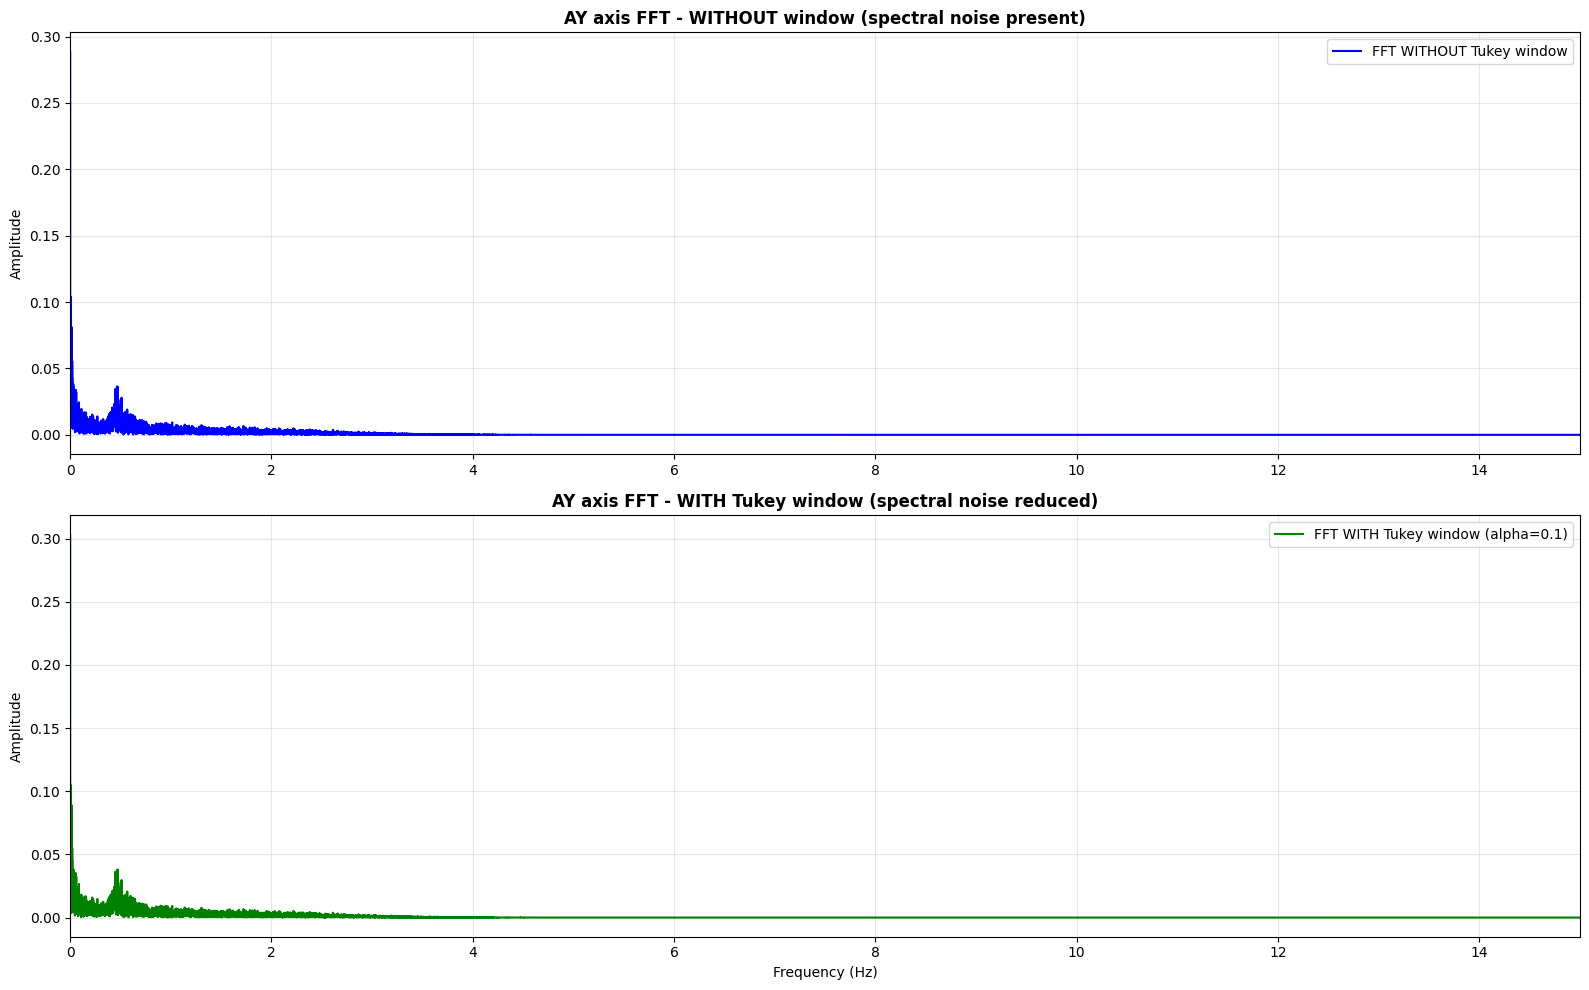


SEGMENTATION USING MARKERS
Markers detected (claps): 19
Segments created: 14
    segment_id     t0_s     t1_s  duration_s      i0      i1
0            1   408.74   425.00       16.26   40874   42500
1            2   425.00   430.53        5.53   42500   43053
2            3   430.53   433.93        3.40   43053   43393
3            4   433.93   569.52      135.59   43393   56952
4            5   569.52   657.31       87.79   56952   65731
5            6   658.67   666.52        7.85   65867   66652
6            7   666.52  1488.57      822.05   66652  148857
7            8  1488.57  1547.04       58.47  148857  154704
8            9  1547.04  1606.78       59.74  154704  160678
9           10  1606.78  1653.84       47.06  160678  165384
10          11  1656.75  1661.53        4.78  165675  166153
11          12  1661.53  1668.42        6.89  166153  166842
12          13  1668.42  1672.13        3.71  166842  167213
13          14  1672.13  1687.56       15.43  167213  168756

Segmen

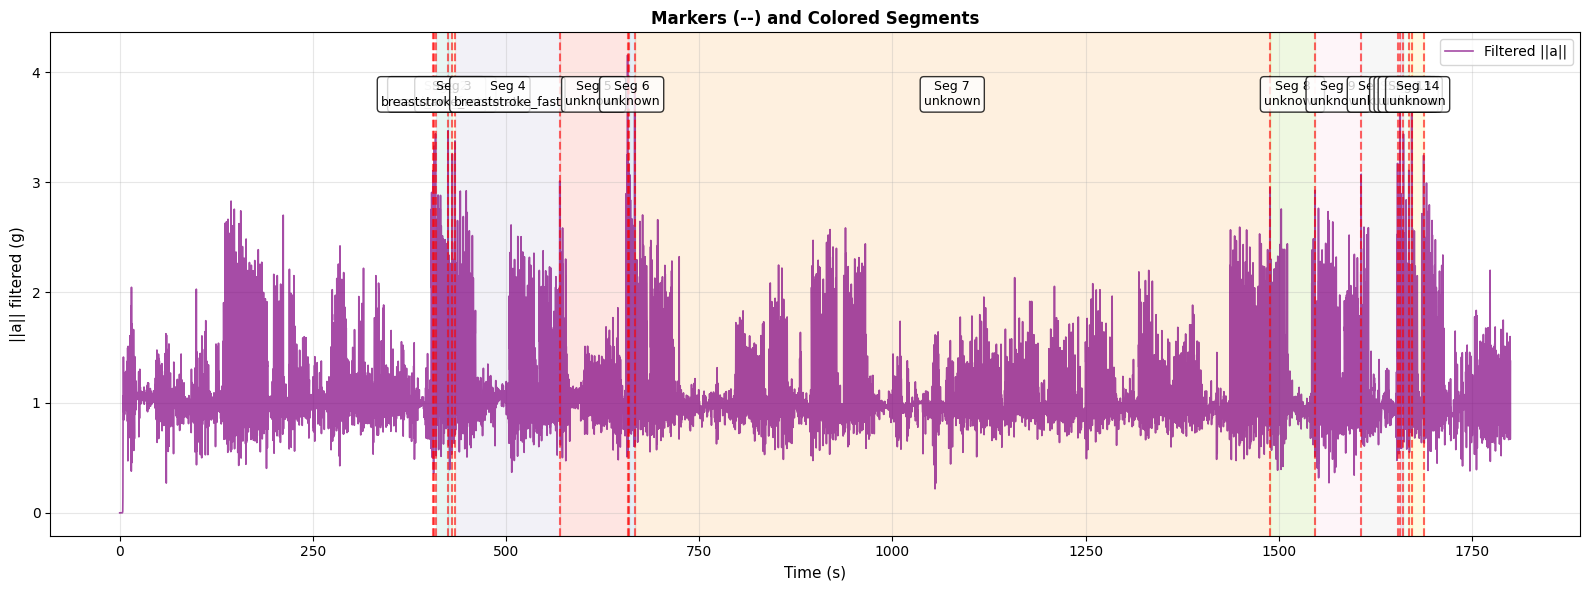

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt, find_peaks
from scipy.signal.windows import tukey

# ==============================================================
# 0. SETUP DIRECTORIES
# ==============================================================
RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Directories created:")
print("  - results/")
print("  - results/figures/")

# ==============================================================
# 1. LOAD DATA
# ==============================================================
df = pd.read_csv("natationdonnes.csv")

df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax',
    'Accel-Y (g)': 'ay',
    'Accel-Z (g)': 'az'
}, inplace=True)

fs = 100
df["time_sec"] = np.arange(len(df)) / fs

print("Data loaded:", len(df), "samples")
print("Total duration:", len(df)/fs, "seconds")

# ==============================================================
# 2. BUTTERWORTH FILTER + TUKEY WINDOW
# ==============================================================
def lowpass_filter(data, fs, cutoff=3, order=4):
    """Apply a low-pass Butterworth filter"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# Filter axes
df["ax_filt"] = lowpass_filter(df["ax"].values, fs)
df["ay_filt"] = lowpass_filter(df["ay"].values, fs)
df["az_filt"] = lowpass_filter(df["az"].values, fs)

# Filtered norm
df["a_norm_filt"] = np.sqrt(
    df["ax_filt"]**2 +
    df["ay_filt"]**2 +
    df["az_filt"]**2
)

# Tukey window for FFT
alpha = 0.1
window_tukey = tukey(len(df), alpha=alpha)

df["ax_windowed"] = df["ax_filt"] * window_tukey
df["ay_windowed"] = df["ay_filt"] * window_tukey
df["az_windowed"] = df["az_filt"] * window_tukey

print("Butterworth 3Hz filter applied")
print("Tukey window (alpha=0.1) applied for FFT")

# ==============================================================
# 3. FFT FUNCTION WITH WINDOW
# ==============================================================
def compute_fft_with_window(signal, fs, window):
    """Compute FFT with normalized window"""
    signal_windowed = signal - np.mean(signal)
    signal_windowed = signal_windowed * window

    n = len(signal_windowed)
    freqs = np.fft.rfftfreq(n, d=1/fs)

    coherence_tukey = np.sum(window) / len(window)
    fft_vals = np.abs(np.fft.rfft(signal_windowed)) / (n * coherence_tukey)

    return freqs, fft_vals

# FFT for each axis
freqs_ax, fft_ax = compute_fft_with_window(df["ax_filt"].values, fs, window_tukey)
freqs_ay, fft_ay = compute_fft_with_window(df["ay_filt"].values, fs, window_tukey)
freqs_az, fft_az = compute_fft_with_window(df["az_filt"].values, fs, window_tukey)

print("FFT computed with Tukey window")

# ==============================================================
# 4. FFT COMPARISON WITH/WITHOUT WINDOW
# ==============================================================
freqs_ay_no_window, fft_ay_no_window = compute_fft_with_window(df["ay_filt"].values, fs, np.ones(len(df)))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(freqs_ay_no_window, fft_ay_no_window, linewidth=1.5, color="blue", label="FFT WITHOUT Tukey window")
axes[0].set_xlim([0, 15])
axes[0].set_ylabel("Amplitude")
axes[0].set_title("AY axis FFT - WITHOUT window (spectral noise present)", fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs_ay, fft_ay, linewidth=1.5, color="green", label="FFT WITH Tukey window (alpha=0.1)")
axes[1].set_xlim([0, 15])
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("AY axis FFT - WITH Tukey window (spectral noise reduced)", fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fft_comparison_ay.png"), dpi=300)
plt.show()

# ==============================================================
# 5b. SEGMENTATION USING MARKERS (CLAPS)
# ==============================================================
marker_prom = 2.5  # very high prominence = only strong peaks
marker_min_dist_s = 1.0

markers, _ = find_peaks(df["a_norm_filt"],
                        distance=int(fs * marker_min_dist_s),
                        prominence=marker_prom)

print("\n" + "="*60)
print("SEGMENTATION USING MARKERS")
print("="*60)
print("Markers detected (claps):", len(markers))

# Build segments between markers
def build_segments_from_markers(t_sec, marker_idx, drop_short_s=3.0):
    """Create segments between markers"""
    rows = []
    seg_id = 1

    for k in range(len(marker_idx) - 1):
        i0 = int(marker_idx[k])
        i1 = int(marker_idx[k+1])

        if i1 <= i0:
            continue

        t0, t1 = float(t_sec[i0]), float(t_sec[i1])
        dur = t1 - t0

        if dur >= drop_short_s:
            rows.append({
                "segment_id": seg_id,
                "t0_s": round(t0, 2),
                "t1_s": round(t1, 2),
                "duration_s": round(dur, 2),
                "i0": i0,
                "i1": i1
            })
            seg_id += 1

    return pd.DataFrame(rows)

segments = build_segments_from_markers(df["time_sec"].values, markers, drop_short_s=3.0)

if len(segments) == 0:
    print("⚠️  No segments detected. Increase marker sensitivity or decrease marker_prom.")
else:
    print(f"Segments created: {len(segments)}")
    print(segments)

    # Export segments
    segments.to_csv(os.path.join(RESULTS_DIR, "segments.csv"), index=False)
    print("\nSegments exported: results/segments.csv")

# ==============================================================
# 5c. LABELING SEGMENTS (OPTIONAL)
# ==============================================================
PROTOCOL_LABELS = [
    "crawl_moderate",
    "crawl_fast",
    "breaststroke_moderate",
    "breaststroke_fast"
]

segments_labeled = segments.copy()

# Add labels (adapt to your protocol)
if len(segments_labeled) >= len(PROTOCOL_LABELS):
    labels = PROTOCOL_LABELS + ["unknown"] * (len(segments_labeled) - len(PROTOCOL_LABELS))
else:
    labels = PROTOCOL_LABELS[:len(segments_labeled)]

segments_labeled["condition"] = labels
segments_labeled.to_csv(os.path.join(RESULTS_DIR, "segments_labeled.csv"), index=False)
print("Labeled segments exported: results/segments_labeled.csv")

# ==============================================================
# 5d. VISUALIZE MARKERS + SEGMENTS
# ==============================================================
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df["time_sec"], df["a_norm_filt"], linewidth=1.2, color="purple", alpha=0.7, label="Filtered ||a||")

# Marker lines
for m in markers:
    ax.axvline(df["time_sec"].iloc[m], color="red", linestyle="--", linewidth=1.5, alpha=0.6)

# Color segments
if len(segments) > 0:
    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
    for i, (_, seg) in enumerate(segments.iterrows()):
        t0, t1 = seg["t0_s"], seg["t1_s"]
        ax.axvspan(t0, t1, alpha=0.2, color=colors[i])

        # Add segment label
        mid_time = (t0 + t1) / 2
        condition = segments_labeled.iloc[i]["condition"] if i < len(segments_labeled) else "segment"
        ax.text(mid_time, ax.get_ylim()[1]*0.9,
                f"Seg {i+1}\n{condition}",
                ha='center', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("||a|| filtered (g)", fontsize=11)
ax.set_title("Markers (--) and Colored Segments", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "segments_markers.png"), dpi=300)
plt.show()


SWIMMING PIPELINE - CORRECT LOGIC

[1] Loading RAW data
----------------------------------------------------------------------
✓ 180000 samples loaded
✓ Duration : 1800.0 seconds
✓ Fs = 100 Hz

[1b] Detecting and removing claps
----------------------------------------------------------------------
✓ Claps detected: 181

Times of claps:
   1. t =    15.2s | amplitude =   3.34g
   2. t =    99.2s | amplitude =   3.78g
   3. t =   136.4s | amplitude =   3.88g
   4. t =   138.2s | amplitude =   3.73g
   5. t =   140.2s | amplitude =   3.58g
   6. t =   144.2s | amplitude =   3.78g
   7. t =   148.3s | amplitude =   3.97g
   8. t =   152.4s | amplitude =   3.59g
   9. t =   154.5s | amplitude =   3.42g
   10. t =   156.7s | amplitude =   3.94g
   11. t =   159.0s | amplitude =   3.97g
   12. t =   174.8s | amplitude =   3.41g
   13. t =   211.7s | amplitude =   3.34g
   14. t =   315.5s | amplitude =   3.50g
   15. t =   403.7s | amplitude =   4.39g
   16. t =   405.1s | amplitude =   3.99g

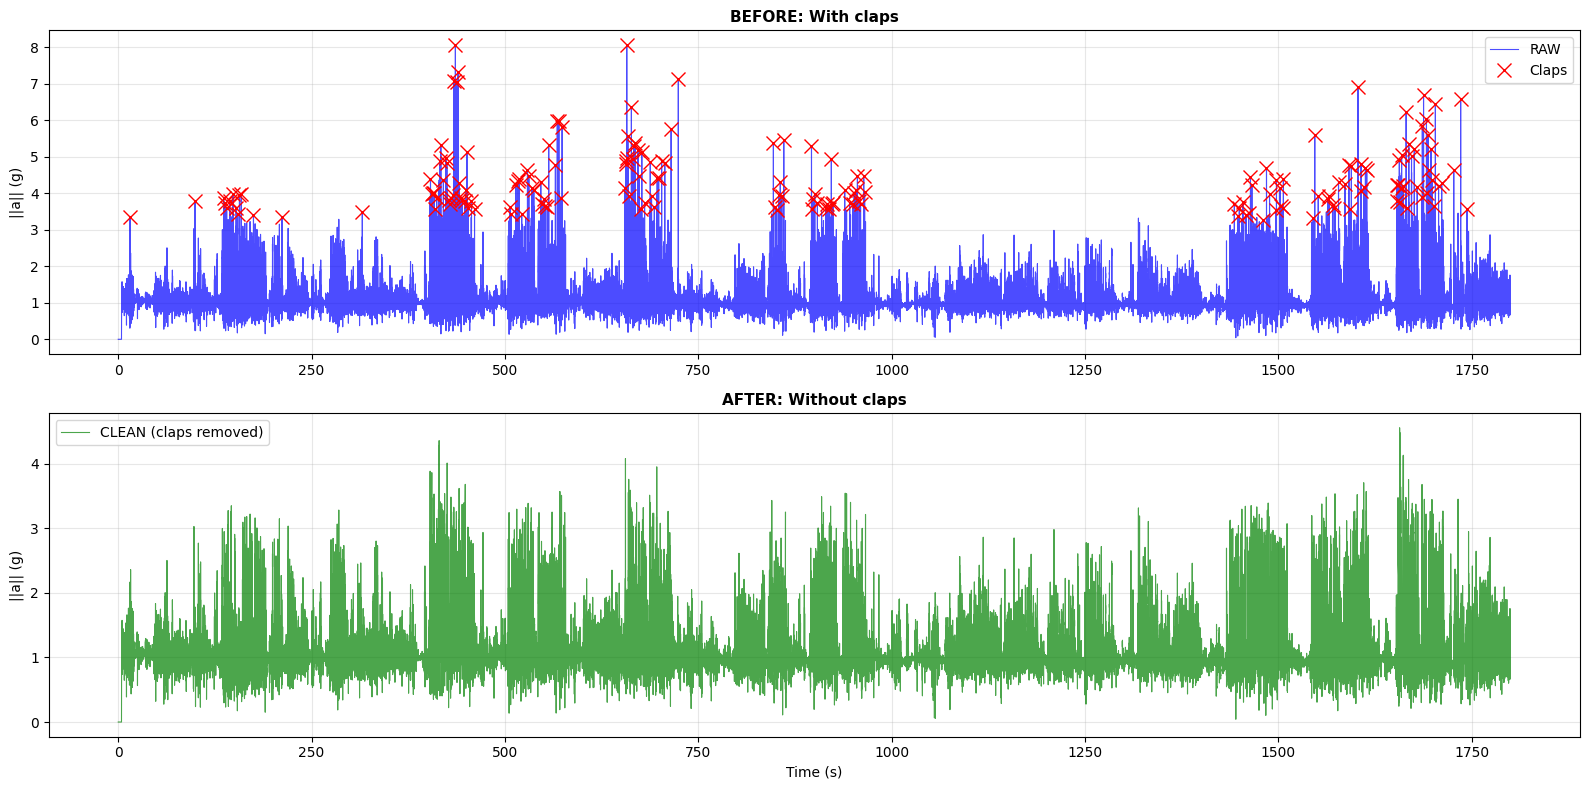


✓ Cleaned signal used for further analysis

[2] Butterworth 3Hz filter
----------------------------------------------------------------------
✓ Butterworth applied on ax, ay, az
✓ Filtered norm computed


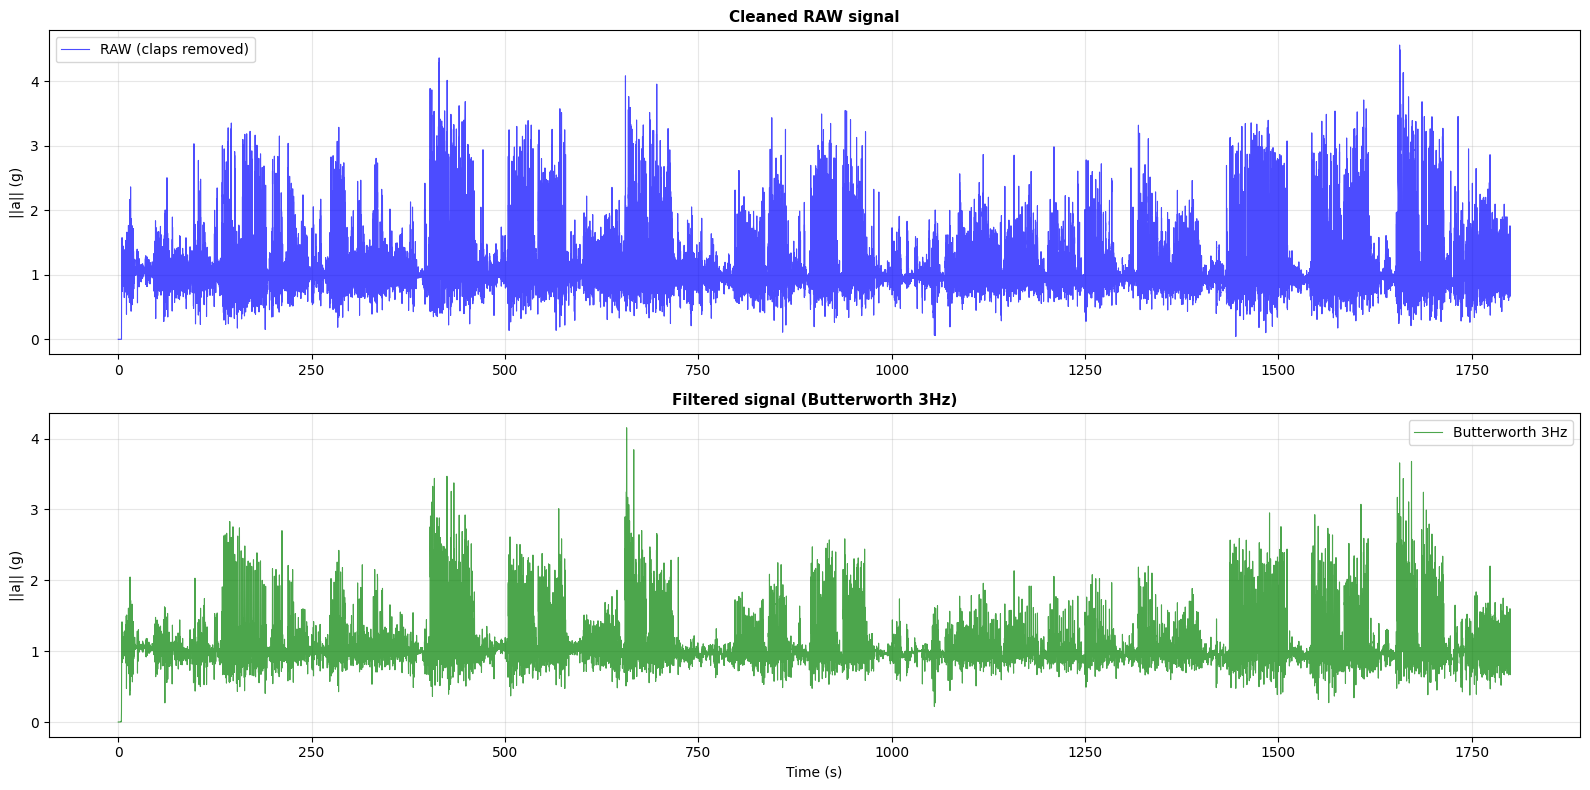


[3] Selecting 2 segments
----------------------------------------------------------------------
✓ Segment 1 (crawl_moderate) : 100 - 200 s
✓ Segment 2 (breaststroke_fast) : 300 - 400 s

[4] FFT with Tukey window (per segment)
----------------------------------------------------------------------
✓ FFT computed for crawl_moderate
✓ FFT computed for breaststroke_fast


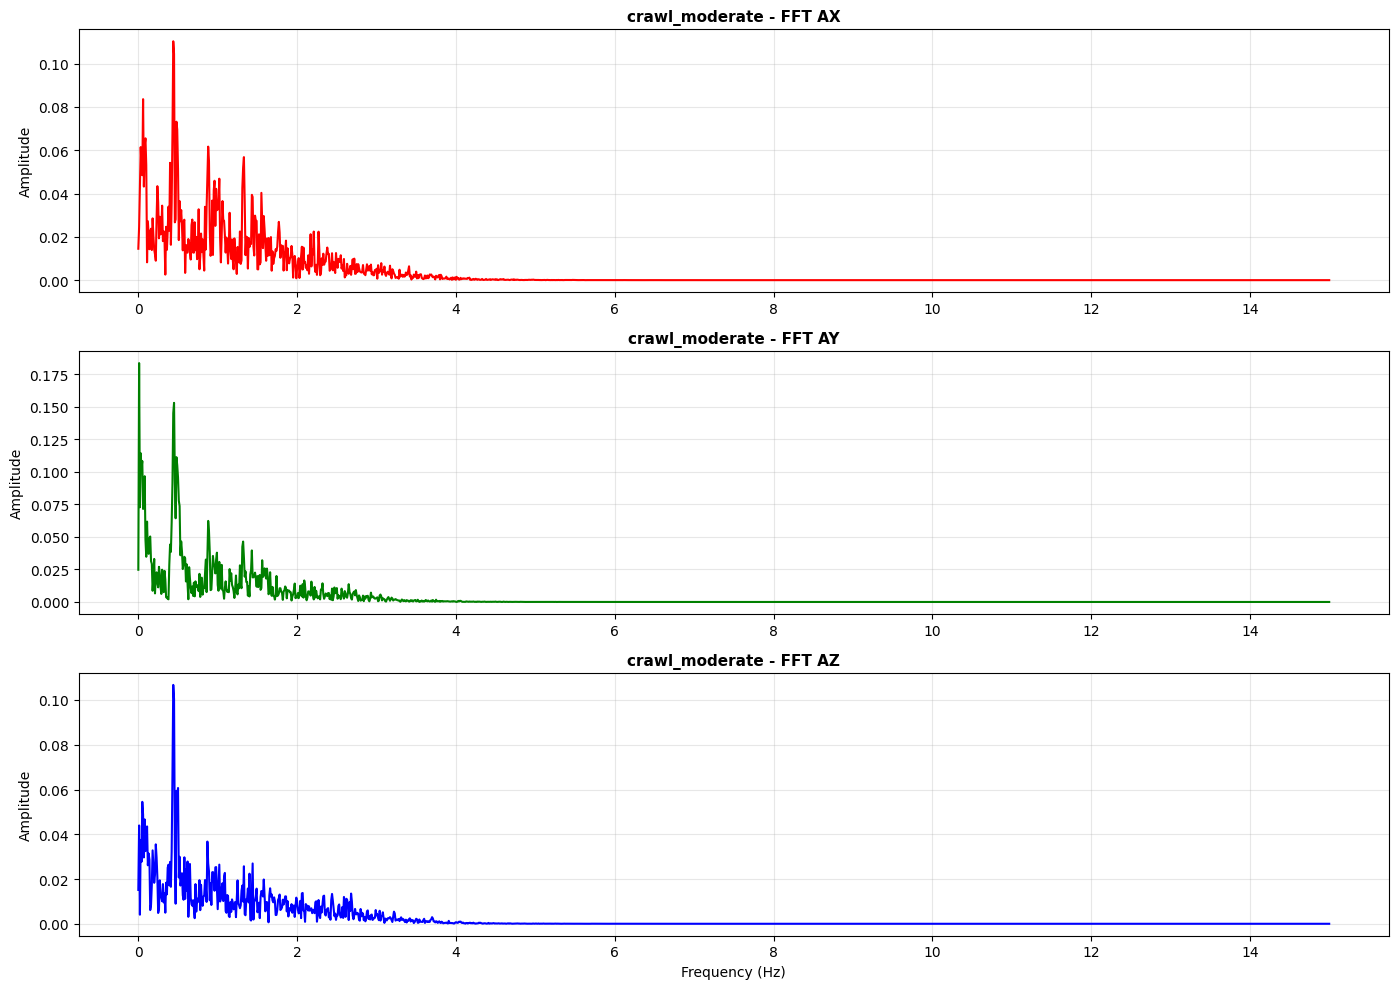

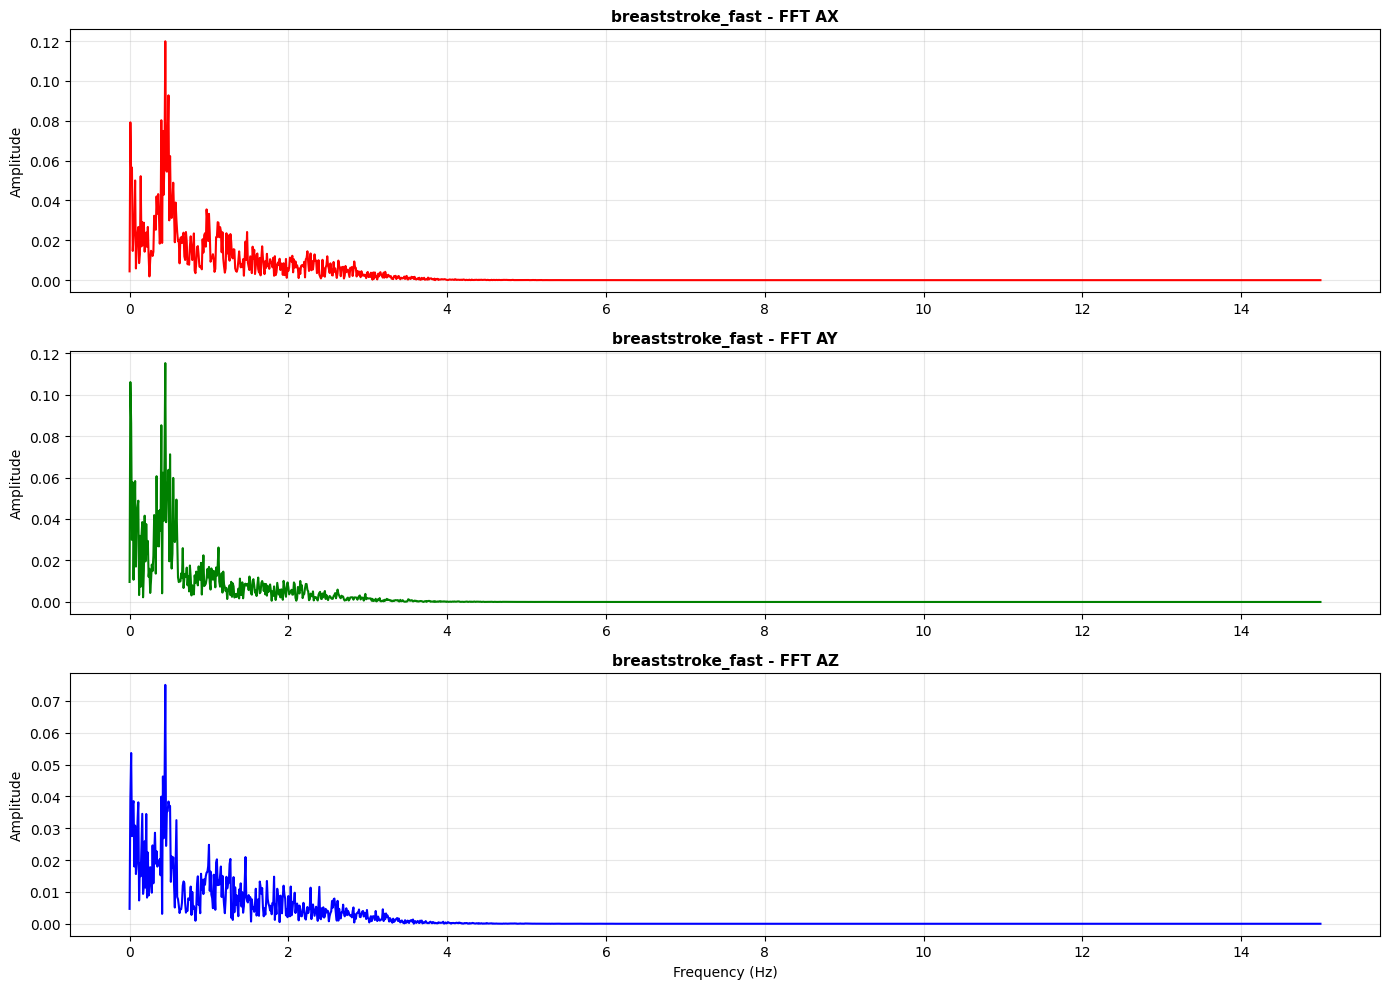


[5] Cycle detection
----------------------------------------------------------------------
✓ crawl_moderate : 59 cycles detected | Cadence : 36.2 cycles/min
✓ breaststroke_fast : 29 cycles detected | Cadence : 17.3 cycles/min

Metrics:
             segment  n_cycles  freq_hz  cadence_cpm  cv_period
0     crawl_moderate        59     0.60         36.2      0.980
1  breaststroke_fast        29     0.29         17.3      1.037

[6] Cycle visualization
----------------------------------------------------------------------


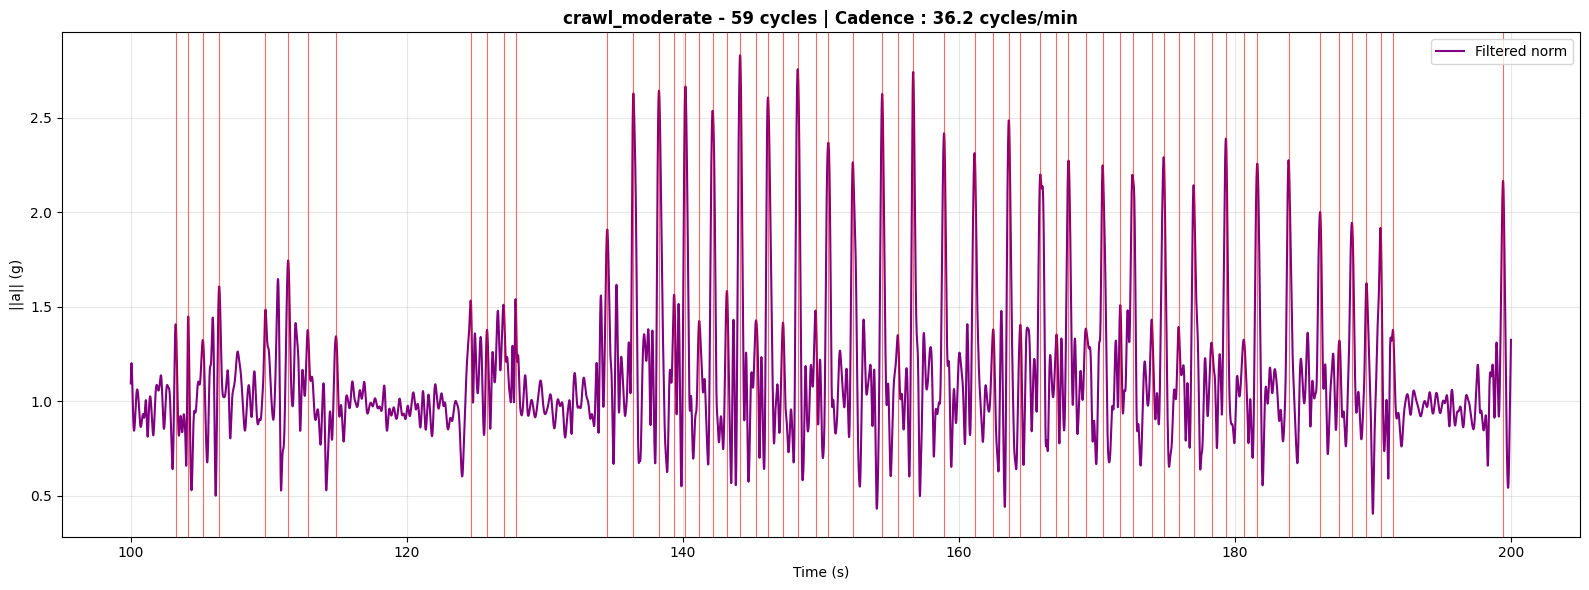

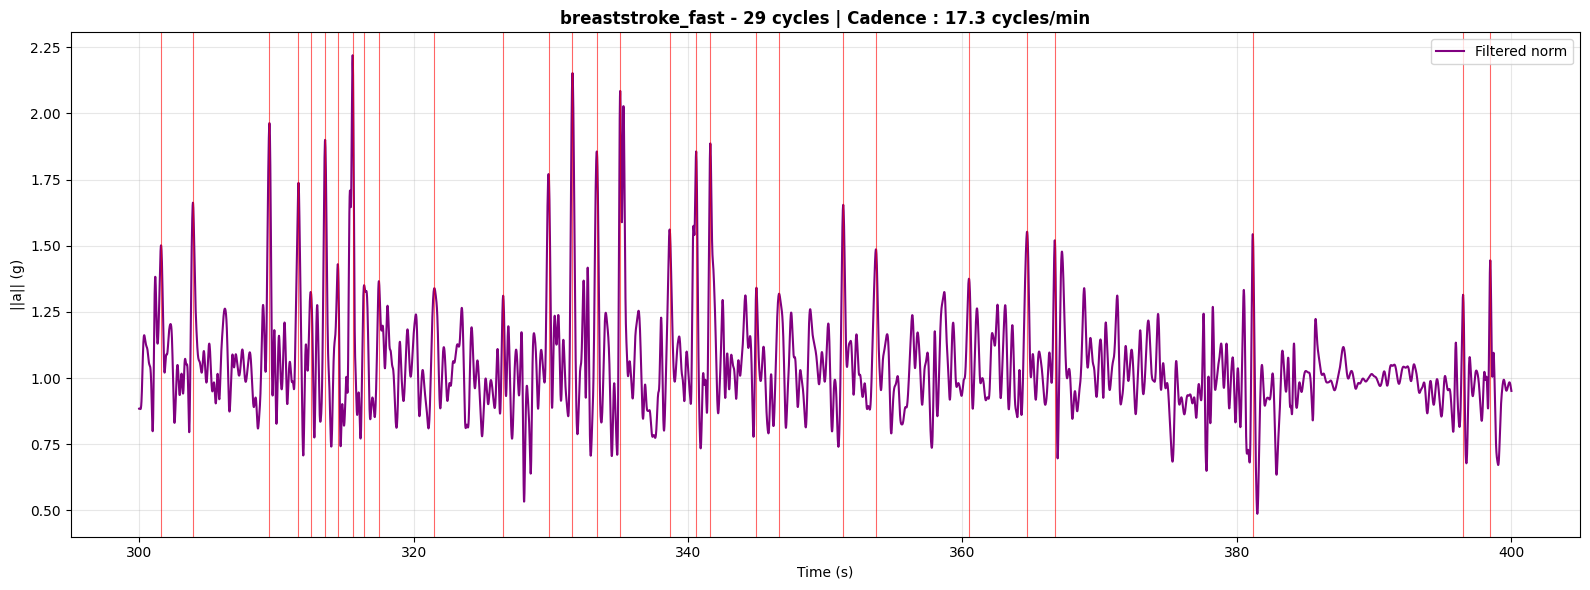


FINAL SUMMARY

📊 GLOBAL STATISTICS:
   • Total cycles detected: 88
   • Total analyzed duration: 200.0 s
   • Average global cadence: 26.8 cycles/min

📈 PER SEGMENT:
   • crawl_moderate       :  59 cycles |   36.2 cycles/min
   • breaststroke_fast    :  29 cycles |   17.3 cycles/min

Exports:
  ✓ results/metrics.csv
  ✓ results/cycles.csv
  ✓ results/figures/*.png

✅ FINISHED


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.signal import butter, filtfilt, find_peaks
from scipy.signal.windows import tukey

# ==============================================================
# SETUP
# ==============================================================
RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*70)
print("SWIMMING PIPELINE - CORRECT LOGIC")
print("="*70)

# ==============================================================
# STEP 1 : LOAD RAW DATA
# ==============================================================
print("\n[1] Loading RAW data")
print("-"*70)

df = pd.read_csv("natationdonnes.csv")
df.columns = df.columns.str.strip()
df.rename(columns={
    'Time': 'time',
    'Accel-X (g)': 'ax',
    'Accel-Y (g)': 'ay',
    'Accel-Z (g)': 'az'
}, inplace=True)

fs = 100
df["time_sec"] = np.arange(len(df)) / fs

print(f"✓ {len(df)} samples loaded")
print(f"✓ Duration : {len(df)/fs:.1f} seconds")
print(f"✓ Fs = {fs} Hz")

# ==============================================================
# STEP 1b : DETECT AND REMOVE CLAPS
# ==============================================================
print("\n[1b] Detecting and removing claps")
print("-"*70)

# Raw acceleration norm
a_norm_raw = np.sqrt(df["ax"]**2 + df["ay"]**2 + df["az"]**2)

# Detect sharp peaks (claps)
clap_prom = 3.0      # Very high prominence
clap_min_dist = 0.5  # Minimum distance 0.5s

claps, _ = find_peaks(a_norm_raw,
                      distance=int(clap_min_dist * fs),
                      prominence=clap_prom)

print(f"✓ Claps detected: {len(claps)}")

if len(claps) > 0:
    print(f"\nTimes of claps:")
    for i, clap in enumerate(claps):
        t = df["time_sec"].iloc[clap]
        val = a_norm_raw.iloc[clap]
        print(f"   {i+1}. t = {t:7.1f}s | amplitude = {val:6.2f}g")

    # Remove claps
    a_norm_clean = a_norm_raw.copy()
    suppress_window = 0.3  # 300ms before and after
    n_suppress = int(suppress_window * fs)

    for clap in claps:
        i_start = max(0, clap - n_suppress)
        i_end = min(len(a_norm_clean), clap + n_suppress)
        a_norm_clean.iloc[i_start:i_end] = np.nan

    # Interpolate NaNs
    a_norm_clean = a_norm_clean.interpolate(method='linear')

    print(f"\n✓ Claps removed")
    print(f"✓ Suppression window: ±{suppress_window}s around each peak")

    # Visualize before/after
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    axes[0].plot(df["time_sec"], a_norm_raw, linewidth=0.8, color="blue", alpha=0.7, label="RAW")
    axes[0].plot(df["time_sec"].iloc[claps], a_norm_raw.iloc[claps], "rx", markersize=10, linewidth=2, label="Claps")
    axes[0].set_ylabel("||a|| (g)")
    axes[0].set_title("BEFORE: With claps", fontsize=11, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df["time_sec"], a_norm_clean, linewidth=0.8, color="green", alpha=0.7, label="CLEAN (claps removed)")
    axes[1].set_ylabel("||a|| (g)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("AFTER: Without claps", fontsize=11, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "00_clap_suppression.png"), dpi=300)
    plt.show()

    # Use cleaned signal for further analysis
    a_norm_raw = a_norm_clean
    print(f"\n✓ Cleaned signal used for further analysis")
else:
    print(f"✓ No claps to remove (signal is clean)")

# ==============================================================
# STEP 2 : BUTTERWORTH 3Hz FILTER
# ==============================================================
print("\n[2] Butterworth 3Hz filter")
print("-"*70)

def lowpass_butter(data, fs, fc=3, order=4):
    nyq = fs / 2
    wn = fc / nyq
    b, a = butter(order, wn, btype='low')
    return filtfilt(b, a, data)

# Filter all axes
df["ax_filt"] = lowpass_butter(df["ax"].values, fs, fc=3, order=4)
df["ay_filt"] = lowpass_butter(df["ay"].values, fs, fc=3, order=4)
df["az_filt"] = lowpass_butter(df["az"].values, fs, fc=3, order=4)

# Compute filtered norm
df["a_norm_filt"] = np.sqrt(df["ax_filt"]**2 + df["ay_filt"]**2 + df["az_filt"]**2)

print("✓ Butterworth applied on ax, ay, az")
print("✓ Filtered norm computed")

# Plot before/after
fig, ax = plt.subplots(2, 1, figsize=(16, 8))

ax[0].plot(df["time_sec"], a_norm_raw,
           linewidth=0.8, color="blue", alpha=0.7, label="RAW (claps removed)")
ax[0].set_ylabel("||a|| (g)")
ax[0].set_title("Cleaned RAW signal", fontsize=11, fontweight='bold')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(df["time_sec"], df["a_norm_filt"],
           linewidth=0.8, color="green", alpha=0.7, label="Butterworth 3Hz")
ax[1].set_ylabel("||a|| (g)")
ax[1].set_xlabel("Time (s)")
ax[1].set_title("Filtered signal (Butterworth 3Hz)", fontsize=11, fontweight='bold')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_raw_vs_filtered.png"), dpi=300)
plt.show()

# ==============================================================
# STEP 3 : SELECT 2 SEGMENTS
# ==============================================================
print("\n[3] Selecting 2 segments")
print("-"*70)

segment_1 = {
    "name": "crawl_moderate",
    "t_start": 100,
    "t_end": 200
}

segment_2 = {
    "name": "breaststroke_fast",
    "t_start": 300,
    "t_end": 400
}

segments = [segment_1, segment_2]

print(f"✓ Segment 1 ({segment_1['name']}) : {segment_1['t_start']} - {segment_1['t_end']} s")
print(f"✓ Segment 2 ({segment_2['name']}) : {segment_2['t_start']} - {segment_2['t_end']} s")

# Verify segments exist
for seg in segments:
    mask = (df["time_sec"] >= seg["t_start"]) & (df["time_sec"] <= seg["t_end"])
    if not mask.any():
        print(f"❌ ERROR: Segment {seg['name']} does not exist")
        print(f"   Available time: 0 - {df['time_sec'].max():.1f} s")
        exit()

# ==============================================================
# STEP 4 : FFT + TUKEY PER SEGMENT
# ==============================================================
print("\n[4] FFT with Tukey window (per segment)")
print("-"*70)

def compute_fft_with_tukey(signal, fs):
    """FFT with Tukey window"""
    sig = signal - np.mean(signal)
    window = tukey(len(sig), alpha=0.1)
    sig_w = sig * window

    n = len(sig_w)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    coherence = np.sum(window) / len(window)
    fft_vals = np.abs(np.fft.rfft(sig_w)) / (n * coherence)

    return freqs, fft_vals

fft_results = {}

for seg in segments:
    name = seg["name"]
    mask = (df["time_sec"] >= seg["t_start"]) & (df["time_sec"] <= seg["t_end"])

    ax_seg = df.loc[mask, "ax_filt"].values
    ay_seg = df.loc[mask, "ay_filt"].values
    az_seg = df.loc[mask, "az_filt"].values

    freqs, fft_ax = compute_fft_with_tukey(ax_seg, fs)
    _, fft_ay = compute_fft_with_tukey(ay_seg, fs)
    _, fft_az = compute_fft_with_tukey(az_seg, fs)

    fft_results[name] = {
        "freqs": freqs,
        "fft_ax": fft_ax,
        "fft_ay": fft_ay,
        "fft_az": fft_az
    }

    print(f"✓ FFT computed for {name}")

# Plot FFT per segment
for seg in segments:
    name = seg["name"]
    data = fft_results[name]
    mask = data["freqs"] <= 15

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].plot(data["freqs"][mask], data["fft_ax"][mask], linewidth=1.5, color="red")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"{name} - FFT AX", fontsize=11, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(data["freqs"][mask], data["fft_ay"][mask], linewidth=1.5, color="green")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title(f"{name} - FFT AY", fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(data["freqs"][mask], data["fft_az"][mask], linewidth=1.5, color="blue")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Amplitude")
    axes[2].set_title(f"{name} - FFT AZ", fontsize=11, fontweight='bold')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"02_fft_{name}.png"), dpi=300)
    plt.show()

# ==============================================================
# STEP 5 : CYCLE DETECTION (per segment)
# ==============================================================
print("\n[5] Cycle detection")
print("-"*70)

cycle_prom = 0.5
cycle_min_dist = int(0.8 * fs)

metrics_list = []
all_cycles = []

for seg in segments:
    name = seg["name"]
    mask = (df["time_sec"] >= seg["t_start"]) & (df["time_sec"] <= seg["t_end"])

    a_norm = df.loc[mask, "a_norm_filt"].values
    t_seg = df.loc[mask, "time_sec"].values

    # Detect peaks
    peaks, _ = find_peaks(a_norm, distance=cycle_min_dist, prominence=cycle_prom)

    if len(peaks) < 2:
        metrics = {
            "segment": name,
            "n_cycles": len(peaks),
            "freq_hz": np.nan,
            "cadence_cpm": np.nan,
            "cv_period": np.nan
        }
    else:
        t_peaks = t_seg[peaks]
        Ti = np.diff(t_peaks)
        mean_T = np.mean(Ti)
        sd_T = np.std(Ti, ddof=1)
        freq = 1.0 / mean_T
        cadence = freq * 60
        cv = sd_T / mean_T

        metrics = {
            "segment": name,
            "n_cycles": len(peaks),
            "freq_hz": round(freq, 2),
            "cadence_cpm": round(cadence, 1),
            "cv_period": round(cv, 3)
        }

        for j, p in enumerate(peaks, start=1):
            all_cycles.append({
                "segment": name,
                "cycle_id": j,
                "time_s": round(t_peaks[j-1], 3),
                "value_g": round(a_norm[p], 3)
            })

    metrics_list.append(metrics)
    print(f"✓ {name} : {metrics['n_cycles']} cycles detected | Cadence : {metrics['cadence_cpm']} cycles/min")

metrics_df = pd.DataFrame(metrics_list)
cycles_df = pd.DataFrame(all_cycles)

# Export
metrics_df.to_csv(os.path.join(RESULTS_DIR, "metrics.csv"), index=False)
cycles_df.to_csv(os.path.join(RESULTS_DIR, "cycles.csv"), index=False)

print("\nMetrics:")
print(metrics_df)

# ==============================================================
# STEP 6 : VISUALIZE CYCLES
# ==============================================================
print("\n[6] Cycle visualization")
print("-"*70)

for seg in segments:
    name = seg["name"]
    mask = (df["time_sec"] >= seg["t_start"]) & (df["time_sec"] <= seg["t_end"])

    a_norm = df.loc[mask, "a_norm_filt"].values
    t_seg = df.loc[mask, "time_sec"].values

    seg_cycles = cycles_df[cycles_df["segment"] == name]
    cycle_times = seg_cycles["time_s"].values

    seg_metrics = metrics_df[metrics_df["segment"] == name].iloc[0]

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(t_seg, a_norm, linewidth=1.5, color="purple", label="Filtered norm")

    for ct in cycle_times:
        ax.axvline(ct, linewidth=0.8, color="red", alpha=0.6)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("||a|| (g)")
    ax.set_title(f"{name} - {seg_metrics['n_cycles']} cycles | Cadence : {seg_metrics['cadence_cpm']} cycles/min",
                 fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"03_cycles_{name}.png"), dpi=300)
    plt.show()

# ==============================================================
# SUMMARY
# ==============================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

total_cycles = len(all_cycles)
total_duration = sum([seg["t_end"] - seg["t_start"] for seg in segments])

print(f"\n📊 GLOBAL STATISTICS:")
print(f"   • Total cycles detected: {total_cycles}")
print(f"   • Total analyzed duration: {total_duration:.1f} s")
print(f"   • Average global cadence: {metrics_df['cadence_cpm'].mean():.1f} cycles/min")

print(f"\n📈 PER SEGMENT:")
for _, row in metrics_df.iterrows():
    print(f"   • {row['segment']:20s} : {int(row['n_cycles']):3d} cycles | {row['cadence_cpm']:6.1f} cycles/min")

print(f"\nExports:")
print("  ✓ results/metrics.csv")
print("  ✓ results/cycles.csv")
print("  ✓ results/figures/*.png")

print("\n" + "="*70)
print("✅ FINISHED")
print("="*70)


**Cycle Detection + Metrics**

For each segment, detects swimming cycles as peaks in the filtered acceleration norm.
Computes metrics per segment:
Number of cycles
Cycle frequency (Hz)
Standard deviation and coefficient of variation of stroke periods
Mean peak amplitude
Saves results to a CSV file.

Saving natationdonnes.csv to natationdonnes (2).csv
Using DATA_PATH = natationdonnes (2).csv
Removed initial zero block: 419 samples (~4.19s).
fs ≈ 100.00 Hz | duration ≈ 1795.8s | gaps=0


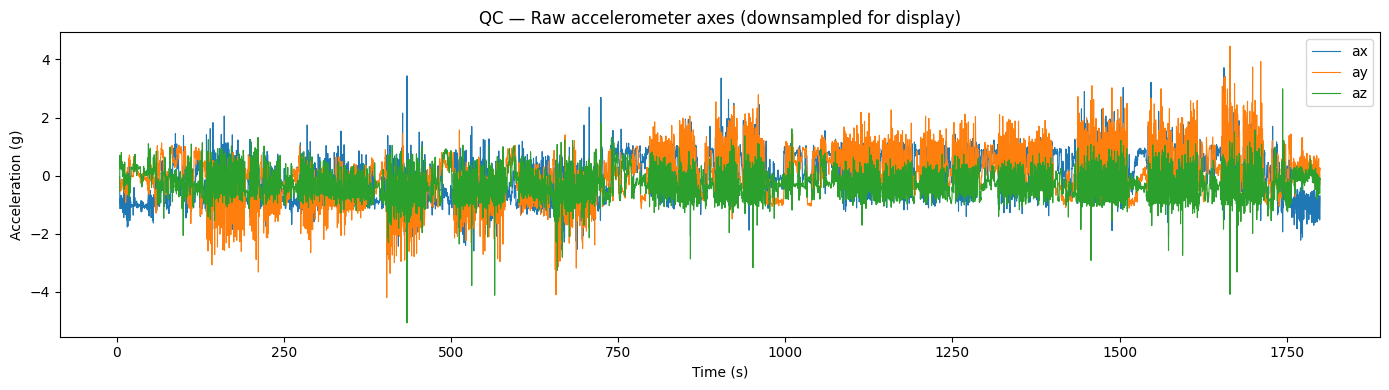

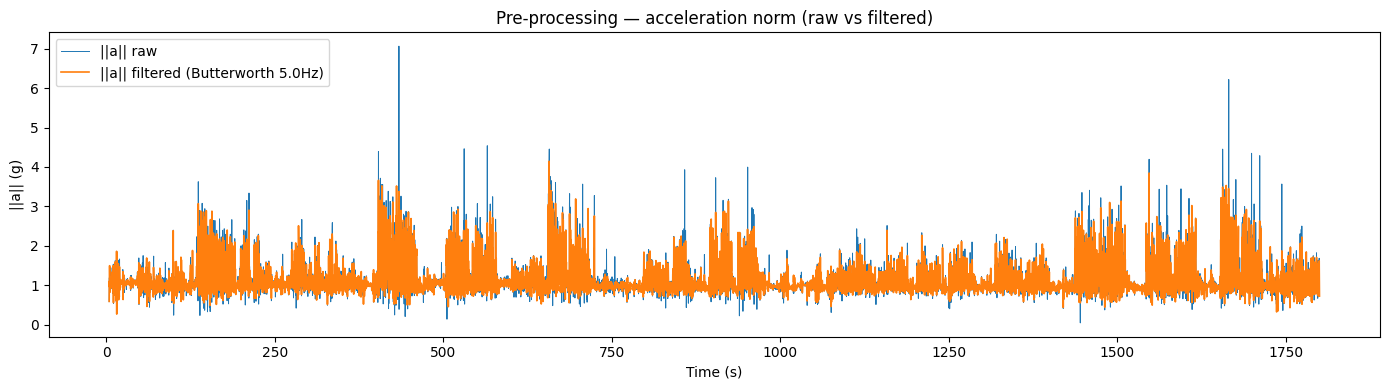

Detected clap markers: 48


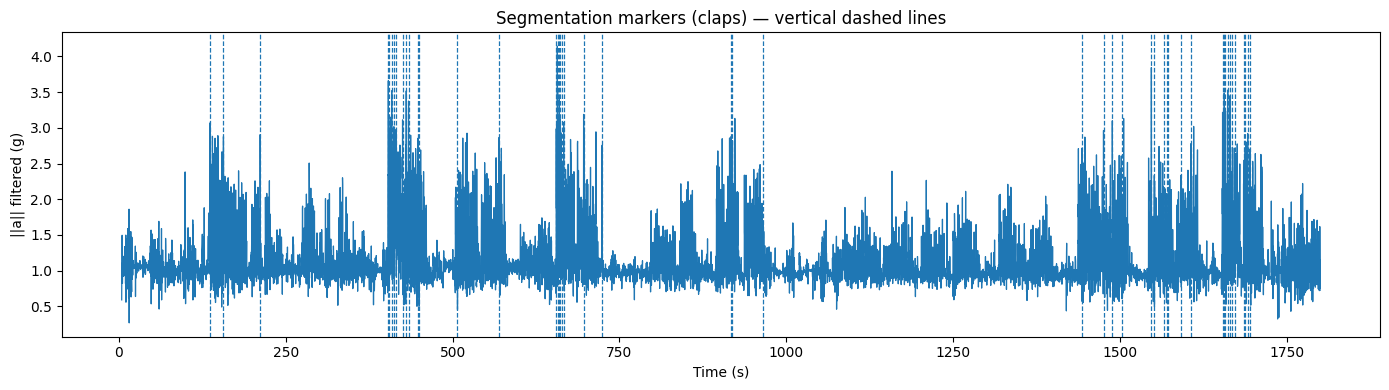

Segments: 36


,segment,t0_s,t1_s,duration_s,i0,i1,condition
0,1,136.390,156.680,20.290,13220,15249,crawl_moderate
1,2,156.680,211.630,54.950,15249,20744,crawl_fast
2,3,211.630,403.710,192.080,20744,39952,breaststroke_moderate
3,4,405.400,408.740,3.340,40121,40455,breaststroke_fast
4,5,408.740,411.740,3.000,40455,40755,unknown
5,6,411.740,414.849,3.109,40755,41066,unknown
6,7,414.849,424.960,10.111,41066,42077,unknown
7,8,424.960,430.539,5.579,42077,42635,unknown
8,9,430.539,434.039,3.500,42635,42985,unknown
9,10,434.039,448.460,14.421,42985,44427,unknown


Exported:
 - results/segments_labeled.csv
 - results/capteur_vs_chrono.csv
 - results/metrics_summary.csv


,segment,condition,t0_s,t1_s,duration_s,n_peaks,freq_hz,SD_T_s,CV_T,amp_mean
0,1,crawl_moderate,136.390,156.680,20.290,23,1.157895,0.260690,0.301851,1.966228
1,2,crawl_fast,156.680,211.630,54.950,51,0.938791,0.561554,0.527182,1.788968
2,3,breaststroke_moderate,211.630,403.710,192.080,159,0.828652,1.069009,0.885837,1.501565
3,4,breaststroke_fast,405.400,408.740,3.340,3,1.282051,0.154149,0.197627,2.528854
4,5,unknown,408.740,411.740,3.000,3,1.218769,0.396687,0.483470,2.982486
5,6,unknown,411.740,414.849,3.109,5,1.550388,0.250400,0.388217,2.375885
6,7,unknown,414.849,424.960,10.111,14,1.368421,0.198207,0.271231,2.432774
7,8,unknown,424.960,430.539,5.579,7,1.209677,0.269457,0.325956,2.366507
8,9,unknown,430.539,434.039,3.500,3,1.258653,0.416486,0.524211,2.446924
9,10,unknown,434.039,448.460,14.421,18,1.245512,0.275532,0.343178,2.262836


In [ ]:
# ============================================================
# HAH913E — Swimming pipeline (QC -> Preprocess -> Segmentation -> Cycles)
# Wrist accelerometer
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# ----------------------------
# 0) Colab: upload data
# ----------------------------
from google.colab import files
uploaded = files.upload()

# Take the first uploaded file as data
DATA_PATH = list(uploaded.keys())[0]
print("Using DATA_PATH =", DATA_PATH)

# ----------------------------
# 1) Output folders
# ----------------------------
RESULTS_DIR = "results"
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ----------------------------
# 2) Parameters (tune only if needed)
# ----------------------------
FC = 5.0                   # low-pass cutoff (Hz) — per project choice
FILTER_ORDER = 4

MARKER_PROM = 2.5          # clap prominence (g units typically)
MARKER_MIN_DIST_S = 1.0    # min spacing between claps (s)
DROP_SHORT_SEG_S = 3.0     # discard segments shorter than this (s)

CYCLE_PROM = 0.25          # cycle peak prominence inside segments (tune)
CYCLE_MIN_DIST_S = 0.5     # minimum cycle spacing (s)

# Protocol labels in expected order (EDIT to match your real protocol)
PROTOCOL_LABELS = [
    "crawl_moderate",
    "crawl_fast",
    "breaststroke_moderate",
    "breaststroke_fast"
]

# Optional stopwatch table (leave None if not available)
# Expected format: segment, T_chrono_s
CHRONO_PATH = None  # e.g. "chrono.csv"

# ============================================================
# 3) Load CSV + standardize columns
# ============================================================
df0 = pd.read_csv(DATA_PATH)

# If file has no header (4 columns), force names
if df0.shape[1] == 4 and not any(str(c).lower() in ["time","t","timestamp"] for c in df0.columns):
    df = pd.read_csv(DATA_PATH, header=None)
    df.columns = ["time", "ax", "ay", "az"]
else:
    df = df0.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    rename_map = {
        "time": "time",
        "t": "time",
        "timestamp": "time",

        "ax": "ax", "ay": "ay", "az": "az",
        "a_x": "ax", "a_y": "ay", "a_z": "az",

        "accel-x (g)": "ax", "accel-y (g)": "ay", "accel-z (g)": "az",
        "accel-x": "ax", "accel-y": "ay", "accel-z": "az",

        "ax(g)": "ax", "ay(g)": "ay", "az(g)": "az",
        "ax (g)": "ax", "ay (g)": "ay", "az (g)": "az",
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

for c in ["time", "ax", "ay", "az"]:
    if c not in df.columns:
        raise ValueError(f"Missing column '{c}'. Available columns: {list(df.columns)}")

# Convert time -> seconds
df["time"] = pd.to_datetime(df["time"], errors="coerce")
if df["time"].isna().any():
    raise ValueError("Time column could not be parsed as datetime. Check the CSV time format.")

t = (df["time"] - df["time"].iloc[0]).dt.total_seconds().to_numpy()
ax = df["ax"].to_numpy(float)
ay = df["ay"].to_numpy(float)
az = df["az"].to_numpy(float)

# ============================================================
# 4) QC — sampling frequency estimate + gaps + zeros
# ============================================================
dt = np.diff(t)
dt_pos = dt[np.isfinite(dt) & (dt > 0)]
if len(dt_pos) < 5:
    raise ValueError("Not enough valid timestamps to estimate fs.")
fs = 1.0 / np.median(dt_pos)

# Identify gaps
gap_idx = np.where(dt > 1.5*np.median(dt_pos))[0]
pd.DataFrame({"gap_index": gap_idx, "gap_dt_s": dt[gap_idx]}).to_csv(
    os.path.join(RESULTS_DIR, "qc_time_gaps.csv"), index=False
)

# Remove initial all-zero block (common acquisition artefact)
mask_init = (ax == 0) & (ay == 0) & (az == 0)
if mask_init.any():
    first_nonzero = np.argmax(~mask_init)
    if first_nonzero > 0:
        t = t[first_nonzero:]
        ax = ax[first_nonzero:]
        ay = ay[first_nonzero:]
        az = az[first_nonzero:]
        df = df.iloc[first_nonzero:].reset_index(drop=True)
        print(f"Removed initial zero block: {first_nonzero} samples (~{first_nonzero/fs:.2f}s).")

qc_summary = {
    "fs_hz_est": fs,
    "n_samples": len(t),
    "duration_s": float(t[-1] - t[0]),
    "n_gaps": int(len(gap_idx)),
    "ax_min": float(np.min(ax)), "ax_max": float(np.max(ax)),
    "ay_min": float(np.min(ay)), "ay_max": float(np.max(ay)),
    "az_min": float(np.min(az)), "az_max": float(np.max(az)),
}
pd.DataFrame([qc_summary]).to_csv(os.path.join(RESULTS_DIR, "qc_summary.csv"), index=False)

print(f"fs ≈ {fs:.2f} Hz | duration ≈ {qc_summary['duration_s']:.1f}s | gaps={len(gap_idx)}")

# QC Figures — lines only (downsample for readability)
ds = max(1, int(len(t)/8000))  # keep roughly <= 8000 points
t_ds = t[::ds]
ax_ds, ay_ds, az_ds = ax[::ds], ay[::ds], az[::ds]

plt.figure(figsize=(14,4))
plt.plot(t_ds, ax_ds, linewidth=0.8, label="ax")
plt.plot(t_ds, ay_ds, linewidth=0.8, label="ay")
plt.plot(t_ds, az_ds, linewidth=0.8, label="az")
plt.xlabel("Time (s)"); plt.ylabel("Acceleration (g)")
plt.title("QC — Raw accelerometer axes (downsampled for display)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "qc_axes_raw.png"), dpi=250)
plt.show()

# ============================================================
# 5) Pre-processing — norm + Butterworth low-pass (5 Hz)
# ============================================================
a_norm_raw = np.sqrt(ax*ax + ay*ay + az*az)

def butter_lowpass_filtfilt(x, fs, fc=5.0, order=4):
    wn = fc / (fs/2.0)
    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)

a_norm_filt = butter_lowpass_filtfilt(a_norm_raw, fs, fc=FC, order=FILTER_ORDER)

# Figure: norm raw vs filtered (lines only)
plt.figure(figsize=(14,4))
plt.plot(t_ds, a_norm_raw[::ds], linewidth=0.7, label="||a|| raw")
plt.plot(t_ds, a_norm_filt[::ds], linewidth=1.2, label=f"||a|| filtered (Butterworth {FC}Hz)")
plt.xlabel("Time (s)"); plt.ylabel("||a|| (g)")
plt.title("Pre-processing — acceleration norm (raw vs filtered)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "qc_norm_raw_vs_filt.png"), dpi=250)
plt.show()

# ============================================================
# 6) Segmentation — clap markers detection on filtered norm
# ============================================================
min_dist = max(1, int(MARKER_MIN_DIST_S * fs))
markers, props = find_peaks(a_norm_filt, prominence=MARKER_PROM, distance=min_dist)
print("Detected clap markers:", len(markers))

# Plot with vertical marker lines (still lines only)
plt.figure(figsize=(14,4))
plt.plot(t_ds, a_norm_filt[::ds], linewidth=0.9, label="||a|| filtered")
for m in markers:
    plt.axvline(t[m], linestyle="--", linewidth=0.9)
plt.xlabel("Time (s)"); plt.ylabel("||a|| filtered (g)")
plt.title("Segmentation markers (claps) — vertical dashed lines")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "qc_markers_vlines.png"), dpi=250)
plt.show()

def build_segments_from_markers(t, marker_idx, drop_short_s=3.0):
    rows = []
    seg_id = 1
    for k in range(len(marker_idx)-1):
        i0, i1 = int(marker_idx[k]), int(marker_idx[k+1])
        if i1 <= i0:
            continue
        t0, t1 = float(t[i0]), float(t[i1])
        dur = t1 - t0
        if dur >= drop_short_s:
            rows.append({"segment": seg_id, "t0_s": t0, "t1_s": t1, "duration_s": dur, "i0": i0, "i1": i1})
            seg_id += 1
    return pd.DataFrame(rows)

segments = build_segments_from_markers(t, markers, drop_short_s=DROP_SHORT_SEG_S)
if len(segments) == 0:
    raise RuntimeError("No segments created. Decrease MARKER_PROM or check if claps exist in the data.")

segments.to_csv(os.path.join(RESULTS_DIR, "segments.csv"), index=False)

# Label segments by protocol order
segments_labeled = segments.copy()
labels = (PROTOCOL_LABELS + ["unknown"]*1000)[:len(segments_labeled)]
segments_labeled["condition"] = labels
segments_labeled.to_csv(os.path.join(RESULTS_DIR, "segments_labeled.csv"), index=False)

print("Segments:", len(segments_labeled))
display(segments_labeled)

# Optional stopwatch validation
capteur_vs_chrono = segments_labeled[["segment","condition","duration_s"]].rename(columns={"duration_s":"T_capteur_s"})
if CHRONO_PATH is not None and os.path.exists(CHRONO_PATH):
    chrono = pd.read_csv(CHRONO_PATH)
    chrono.columns = [c.strip().lower() for c in chrono.columns]
    chrono = chrono.rename(columns={"t_chrono_s":"t_chrono_s", "chrono_s":"t_chrono_s"})
    if "segment" not in chrono.columns or "t_chrono_s" not in chrono.columns:
        raise ValueError("chrono.csv must contain columns: segment, t_chrono_s")
    chrono["segment"] = chrono["segment"].astype(int)
    capteur_vs_chrono = capteur_vs_chrono.merge(chrono[["segment","t_chrono_s"]], on="segment", how="left")
    capteur_vs_chrono["delta_T_s"] = capteur_vs_chrono["T_capteur_s"] - capteur_vs_chrono["t_chrono_s"]

capteur_vs_chrono.to_csv(os.path.join(RESULTS_DIR, "capteur_vs_chrono.csv"), index=False)

# ============================================================
# 7) Cycle detection + metrics (per segment)
# ============================================================
def cycles_metrics_for_segment(t, x, fs, i0, i1, prom=0.25, min_dist_s=0.5):
    seg_x = x[i0:i1+1]
    seg_t = t[i0:i1+1]
    dist = max(1, int(min_dist_s * fs))
    peaks, _ = find_peaks(seg_x, prominence=prom, distance=dist)
    if len(peaks) < 2:
        return {"n_peaks": len(peaks), "freq_hz": np.nan, "SD_T_s": np.nan, "CV_T": np.nan, "amp_mean": np.nan}
    t_peaks = seg_t[peaks]
    Ti = np.diff(t_peaks)
    mean_T = float(np.mean(Ti))
    SD_T = float(np.std(Ti, ddof=1)) if len(Ti) >= 2 else np.nan
    CV_T = float(SD_T/mean_T) if mean_T > 0 else np.nan
    freq = float(1.0/mean_T) if mean_T > 0 else np.nan
    amp_mean = float(np.mean(seg_x[peaks]))
    return {"n_peaks": int(len(peaks)), "freq_hz": freq, "SD_T_s": SD_T, "CV_T": CV_T, "amp_mean": amp_mean}

rows = []
for _, seg in segments_labeled.iterrows():
    m = cycles_metrics_for_segment(t, a_norm_filt, fs, int(seg.i0), int(seg.i1),
                                  prom=CYCLE_PROM, min_dist_s=CYCLE_MIN_DIST_S)
    rows.append({
        "segment": int(seg.segment),
        "condition": seg.condition,
        "t0_s": float(seg.t0_s),
        "t1_s": float(seg.t1_s),
        "duration_s": float(seg.duration_s),
        **m
    })

metrics = pd.DataFrame(rows)
metrics.to_csv(os.path.join(RESULTS_DIR, "metrics_summary.csv"), index=False)

print("Exported:")
print(" - results/segments_labeled.csv")
print(" - results/capteur_vs_chrono.csv")
print(" - results/metrics_summary.csv")
display(metrics)
